In [1]:
# ============================================================
# VISUALIZATION NOTEBOOK — BLOCK 1
# DATA ACCESS, AVAILABILITY & INTEGRITY VERIFICATION
#
# International Commodity Futures Strategy Archetype Analysis
#
# PURPOSE:
#   Establish a clean, verified connection to the frozen
#   research archive before beginning visualization.
#
# IMPORTANT:
#   This notebook is for VISUALIZATION.
#
#   This block:
#       - DOES NOT rerun strategies
#       - DOES NOT download data
#       - DOES NOT optimize parameters
#       - DOES NOT modify research files
#       - DOES NOT recalculate the research
#       - ONLY reads and verifies the frozen archive
#
# After this block passes, subsequent notebook blocks will use
# the DATASETS dictionary created here.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
from datetime import datetime


# ============================================================
# 1. RESEARCH ARCHIVE LOCATION
# ============================================================

ROOT = Path(
    r"C:\Users\navon\commodity_strategy_research"
)

print("=" * 95)
print("VISUALIZATION NOTEBOOK — BLOCK 1")
print("DATA ACCESS & INTEGRITY VERIFICATION")
print("=" * 95)

print(f"Research archive:")
print(f"    {ROOT}")

print(f"\nVerification time:")
print(f"    {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("=" * 95)


# ============================================================
# 2. VERIFY ROOT DIRECTORY
# ============================================================

if not ROOT.exists():

    raise FileNotFoundError(
        "\n❌ RESEARCH ARCHIVE NOT FOUND\n\n"
        f"Expected location:\n{ROOT}\n\n"
        "Check that the path is correct and accessible "
        "from this JupyterLab environment."
    )

if not ROOT.is_dir():

    raise NotADirectoryError(
        f"\n❌ Path exists but is not a directory:\n{ROOT}"
    )

print("\n✅ ROOT DIRECTORY ACCESSIBLE")


# ============================================================
# 3. VERIFY CORE FOLDERS
# ============================================================

REQUIRED_FOLDERS = [
    "trades",
    "market_data",
    "statistics",
    "distributions",
    "validation",
    "metadata"
]

print("\nCORE FOLDERS")
print("-" * 95)

folder_failures = []

for folder in REQUIRED_FOLDERS:

    path = ROOT / folder

    if path.exists() and path.is_dir():

        print(f"✅ {folder}")

    else:

        print(f"❌ {folder}")
        folder_failures.append(folder)

if folder_failures:

    raise FileNotFoundError(
        f"\nMissing required folders: {folder_failures}"
    )


# ============================================================
# 4. DISCOVER ALL FILES
# ============================================================

all_files = sorted([
    p for p in ROOT.rglob("*")
    if p.is_file()
])

csv_files = sorted([
    p for p in all_files
    if p.suffix.lower() == ".csv"
])

json_files = sorted([
    p for p in all_files
    if p.suffix.lower() == ".json"
])

print("\nARCHIVE FILE COUNTS")
print("-" * 95)
print(f"Total files : {len(all_files)}")
print(f"CSV files   : {len(csv_files)}")
print(f"JSON files  : {len(json_files)}")


# ============================================================
# 5. EXPECTED CORE VISUALIZATION DATA
#
# These are the files we know will be required throughout
# the visualization phase.
# ============================================================

EXPECTED_VISUALIZATION_FILES = [

    # --------------------------------------------------------
    # PRIMARY TRADE DATA
    # --------------------------------------------------------

    "trades/all_strategy_trades.csv",
    "trades/macd_trades.csv",
    "trades/mean_reversion_trades.csv",
    "trades/bollinger_breakout_trades.csv",

    # --------------------------------------------------------
    # RAW MARKET DATA
    # --------------------------------------------------------

    "market_data/gold_daily_ohlcv.csv",
    "market_data/silver_daily_ohlcv.csv",
    "market_data/copper_daily_ohlcv.csv",
    "market_data/crude_oil_daily_ohlcv.csv",
    "market_data/natural_gas_daily_ohlcv.csv",

    "market_data/causal_regime_features.csv",

    # --------------------------------------------------------
    # STRATEGY COMPARISON
    # --------------------------------------------------------

    "statistics/strategy_summary.csv",
    "statistics/overall_strategy_comparison.csv",

    "statistics/commodity_strategy_summary.csv",
    "statistics/commodity_direction_summary.csv",

    "statistics/cross_strategy_commodity_matrix.csv",
    "statistics/expectancy_matrix.csv",
    "statistics/profit_factor_matrix.csv",
    "statistics/win_rate_matrix.csv",
    "statistics/median_return_matrix.csv",
    "statistics/holding_period_matrix.csv",

    # --------------------------------------------------------
    # DIRECTIONAL
    # --------------------------------------------------------

    "statistics/strategy_direction_summary.csv",
    "statistics/directional_cross_strategy_analysis.csv",
    "statistics/long_short_edge_analysis.csv",
    "statistics/long_short_statistical_difference.csv",

    # --------------------------------------------------------
    # DISTRIBUTIONS / TAILS
    # --------------------------------------------------------

    "distributions/strategy_distributions.csv",
    "distributions/extreme_trades.csv",
    "distributions/profit_loss_concentration.csv",

    "statistics/tail_dependence_analysis.csv",
    "statistics/tail_profit_loss_concentration.csv",
    "statistics/tail_robustness_analysis.csv",
    "statistics/tail_behavior_classification.csv",

    # --------------------------------------------------------
    # TEMPORAL STABILITY
    # --------------------------------------------------------

    "statistics/regime_period_performance.csv",
    "statistics/regime_expectancy_matrix.csv",
    "statistics/regime_profit_factor_matrix.csv",
    "statistics/regime_win_rate_matrix.csv",
    "statistics/regime_stability_summary.csv",
    "statistics/regime_directional_performance.csv",
    "statistics/regime_long_short_asymmetry.csv",
    "statistics/regime_strategy_consistency.csv",
    "statistics/regime_commodity_consistency.csv",

    # --------------------------------------------------------
    # MARKET STATE
    # --------------------------------------------------------

    "statistics/regime_trade_level_data.csv",
    "statistics/regime_trend_state_performance.csv",
    "statistics/regime_volatility_state_performance.csv",
    "statistics/regime_momentum_state_performance.csv",
    "statistics/regime_market_state_performance.csv",
    "statistics/regime_strategy_ranking.csv",
    "statistics/regime_performance_spread.csv",
    "statistics/regime_market_state_counts.csv",
    "statistics/regime_state_coverage.csv",

    # --------------------------------------------------------
    # CONDITIONAL VALIDATION
    # --------------------------------------------------------

    "statistics/conditional_state_vs_baseline.csv",
    "statistics/conditional_best_vs_worst_state.csv",
    "statistics/conditional_long_short_state_difference.csv",
    "statistics/conditional_state_robustness.csv",
    "statistics/conditional_evidence_ranking.csv",

    # --------------------------------------------------------
    # ECONOMIC DECOMPOSITION
    # --------------------------------------------------------

    "statistics/regime_economic_decomposition.csv",
    "statistics/regime_directional_decomposition.csv",
    "statistics/regime_pnl_contribution.csv",
    "statistics/regime_tail_contribution.csv",
    "statistics/regime_state_comparison.csv",
    "statistics/regime_strategy_economic_summary.csv",

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    "validation/extreme_trade_path_validation.csv",
    "validation/validation_summary.csv",

    # --------------------------------------------------------
    # VISUALIZATION MAP
    # --------------------------------------------------------

    "metadata/VISUALIZATION_DATA_MAP.csv",

    # --------------------------------------------------------
    # ARCHIVE VERIFICATION
    # --------------------------------------------------------

    "metadata/FINAL_ARCHIVE_INVENTORY.csv",
    "metadata/FINAL_ARCHIVE_VERIFICATION.csv",
    "metadata/FINAL_ARCHIVE_SUMMARY.csv",

    # --------------------------------------------------------
    # RESEARCH METADATA
    # --------------------------------------------------------

    "metadata/research_manifest.csv",
    "metadata/research_manifest.json",
]


# ============================================================
# 6. CHECK EXPECTED VISUALIZATION FILES
# ============================================================

print("\nEXPECTED VISUALIZATION DATA FILES")
print("-" * 95)

missing_visualization_files = []

for rel in EXPECTED_VISUALIZATION_FILES:

    path = ROOT / rel

    if path.exists():

        print(f"✅ {rel}")

    else:

        print(f"❌ {rel}")
        missing_visualization_files.append(rel)


if missing_visualization_files:

    print("\n❌ MISSING VISUALIZATION FILES:")

    for f in missing_visualization_files:
        print(f"   {f}")

    raise FileNotFoundError(
        "\nVisualization notebook cannot safely continue "
        "until the missing files are resolved."
    )

else:

    print(
        f"\n✅ ALL {len(EXPECTED_VISUALIZATION_FILES)} "
        "REQUIRED VISUALIZATION FILES ARE AVAILABLE"
    )


# ============================================================
# 7. LOAD ALL CSV DATASETS
#
# Every CSV is loaded into the DATASETS dictionary.
#
# Example later:
#
#   DATASETS["trades/all_strategy_trades.csv"]
#
# ============================================================

print("\n")
print("=" * 95)
print("LOADING ALL CSV DATASETS")
print("=" * 95)

DATASETS = {}
LOAD_ERRORS = []

for path in csv_files:

    rel = path.relative_to(ROOT).as_posix()

    try:

        df = pd.read_csv(path)

        DATASETS[rel] = df

        print(
            f"✅ {rel:<70} "
            f"{len(df):>8,} rows × {len(df.columns):>3} cols"
        )

    except Exception as e:

        LOAD_ERRORS.append({
            "File": rel,
            "Error": str(e)
        })

        print(
            f"❌ {rel:<70} "
            f"FAILED"
        )


if LOAD_ERRORS:

    print("\n❌ DATASET LOAD ERRORS")

    for error in LOAD_ERRORS:
        print(error)

    raise RuntimeError(
        f"{len(LOAD_ERRORS)} CSV files could not be loaded."
    )

print(
    f"\n✅ Successfully loaded {len(DATASETS):,} CSV datasets."
)


# ============================================================
# 8. LOAD JSON MANIFEST
# ============================================================

MANIFEST_PATH = ROOT / "metadata/research_manifest.json"

try:

    with open(
        MANIFEST_PATH,
        "r",
        encoding="utf-8"
    ) as f:

        RESEARCH_MANIFEST = json.load(f)

    print("✅ Research manifest JSON loaded")

except Exception as e:

    raise RuntimeError(
        f"Could not load research manifest:\n{e}"
    )


# ============================================================
# 9. CORE DATASET REFERENCES
#
# These shortcuts will be used by subsequent notebook blocks.
# ============================================================

MASTER_TRADES = DATASETS[
    "trades/all_strategy_trades.csv"
]

MACD_TRADES = DATASETS[
    "trades/macd_trades.csv"
]

MEAN_REVERSION_TRADES = DATASETS[
    "trades/mean_reversion_trades.csv"
]

BOLLINGER_TRADES = DATASETS[
    "trades/bollinger_breakout_trades.csv"
]

GOLD_DAILY = DATASETS[
    "market_data/gold_daily_ohlcv.csv"
]

SILVER_DAILY = DATASETS[
    "market_data/silver_daily_ohlcv.csv"
]

COPPER_DAILY = DATASETS[
    "market_data/copper_daily_ohlcv.csv"
]

CRUDE_DAILY = DATASETS[
    "market_data/crude_oil_daily_ohlcv.csv"
]

NATURAL_GAS_DAILY = DATASETS[
    "market_data/natural_gas_daily_ohlcv.csv"
]

CAUSAL_REGIME = DATASETS[
    "market_data/causal_regime_features.csv"
]

EXPECTANCY_MATRIX = DATASETS[
    "statistics/expectancy_matrix.csv"
]

PROFIT_FACTOR_MATRIX = DATASETS[
    "statistics/profit_factor_matrix.csv"
]

WIN_RATE_MATRIX = DATASETS[
    "statistics/win_rate_matrix.csv"
]

HOLDING_PERIOD_MATRIX = DATASETS[
    "statistics/holding_period_matrix.csv"
]

OVERALL_STRATEGY = DATASETS[
    "statistics/overall_strategy_comparison.csv"
]

CROSS_STRATEGY = DATASETS[
    "statistics/cross_strategy_commodity_matrix.csv"
]

LONG_SHORT_EDGE = DATASETS[
    "statistics/long_short_edge_analysis.csv"
]

TAIL_ANALYSIS = DATASETS[
    "statistics/tail_dependence_analysis.csv"
]

TAIL_ROBUSTNESS = DATASETS[
    "statistics/tail_robustness_analysis.csv"
]

REGIME_PERIOD = DATASETS[
    "statistics/regime_period_performance.csv"
]

REGIME_STABILITY = DATASETS[
    "statistics/regime_stability_summary.csv"
]

REGIME_MARKET_STATE = DATASETS[
    "statistics/regime_market_state_performance.csv"
]

REGIME_TRADE_LEVEL = DATASETS[
    "statistics/regime_trade_level_data.csv"
]

CONDITIONAL_EVIDENCE = DATASETS[
    "statistics/conditional_evidence_ranking.csv"
]

ECONOMIC_DECOMPOSITION = DATASETS[
    "statistics/regime_economic_decomposition.csv"
]

PNL_CONTRIBUTION = DATASETS[
    "statistics/regime_pnl_contribution.csv"
]

EXTREME_TRADES = DATASETS[
    "distributions/extreme_trades.csv"
]

EXTREME_VALIDATION = DATASETS[
    "validation/extreme_trade_path_validation.csv"
]

VISUALIZATION_MAP = DATASETS[
    "metadata/VISUALIZATION_DATA_MAP.csv"
]


# ============================================================
# 10. MASTER TRADE DATA CHECKS
# ============================================================

print("\n")
print("=" * 95)
print("MASTER TRADE DATA VERIFICATION")
print("=" * 95)

print(
    f"Master trades       : {len(MASTER_TRADES):,}"
)

print(
    f"MACD trades         : {len(MACD_TRADES):,}"
)

print(
    f"Mean Reversion      : {len(MEAN_REVERSION_TRADES):,}"
)

print(
    f"Bollinger Breakout  : {len(BOLLINGER_TRADES):,}"
)

print(
    f"Strategy total      : "
    f"{len(MACD_TRADES) + len(MEAN_REVERSION_TRADES) + len(BOLLINGER_TRADES):,}"
)


# ------------------------------------------------------------
# Expected trade counts
# ------------------------------------------------------------

if len(MASTER_TRADES) != 2499:

    raise AssertionError(
        f"❌ Master trade count mismatch: "
        f"{len(MASTER_TRADES)}"
    )

if len(MACD_TRADES) != 793:

    raise AssertionError(
        f"❌ MACD trade count mismatch: "
        f"{len(MACD_TRADES)}"
    )

if len(MEAN_REVERSION_TRADES) != 980:

    raise AssertionError(
        f"❌ Mean Reversion trade count mismatch: "
        f"{len(MEAN_REVERSION_TRADES)}"
    )

if len(BOLLINGER_TRADES) != 726:

    raise AssertionError(
        f"❌ Bollinger trade count mismatch: "
        f"{len(BOLLINGER_TRADES)}"
    )

if (
    len(MACD_TRADES)
    + len(MEAN_REVERSION_TRADES)
    + len(BOLLINGER_TRADES)
    != len(MASTER_TRADES)
):

    raise AssertionError(
        "❌ Individual strategy counts do not reconcile "
        "to the master trade file."
    )

print("\n✅ MASTER TRADE COUNTS VERIFIED")


# ============================================================
# 11. MASTER TRADE SCHEMA
# ============================================================

required_trade_columns = [
    "Ticker",
    "Strategy",
    "Entry Date",
    "Exit Date",
    "Position",
    "Entry Price",
    "Exit Price",
    "Return %",
    "Holding Days"
]

missing_trade_columns = [
    c
    for c in required_trade_columns
    if c not in MASTER_TRADES.columns
]

if missing_trade_columns:

    raise AssertionError(
        f"❌ Missing master trade columns: "
        f"{missing_trade_columns}"
    )

print("✅ MASTER TRADE SCHEMA VERIFIED")


# ============================================================
# 12. COMMODITY UNIVERSE
# ============================================================

expected_commodities = {
    "GOLD",
    "SILVER",
    "COPPER",
    "CRUDE_OIL",
    "NATURAL_GAS"
}

actual_commodities = set(
    MASTER_TRADES["Ticker"]
    .dropna()
    .astype(str)
    .unique()
)

print("\nCommodity universe:")
print(sorted(actual_commodities))

if actual_commodities != expected_commodities:

    raise AssertionError(
        "\n❌ Commodity universe mismatch\n"
        f"Expected: {sorted(expected_commodities)}\n"
        f"Found:    {sorted(actual_commodities)}"
    )

print("✅ FIVE COMMODITIES VERIFIED")


# ============================================================
# 13. MASTER DATA QUALITY
# ============================================================

duplicate_rows = MASTER_TRADES.duplicated().sum()

missing_returns = (
    MASTER_TRADES["Return %"]
    .isna()
    .sum()
)

missing_entry_prices = (
    MASTER_TRADES["Entry Price"]
    .isna()
    .sum()
)

missing_exit_prices = (
    MASTER_TRADES["Exit Price"]
    .isna()
    .sum()
)

missing_holding = (
    MASTER_TRADES["Holding Days"]
    .isna()
    .sum()
)

print("\nMaster trade quality:")
print(f"Duplicate rows       : {duplicate_rows}")
print(f"Missing returns      : {missing_returns}")
print(f"Missing entry prices : {missing_entry_prices}")
print(f"Missing exit prices  : {missing_exit_prices}")
print(f"Missing holding days : {missing_holding}")

if any([
    duplicate_rows,
    missing_returns,
    missing_entry_prices,
    missing_exit_prices,
    missing_holding
]):

    raise AssertionError(
        "❌ Master trade data quality check failed."
    )

print("✅ MASTER TRADE DATA QUALITY VERIFIED")


# ============================================================
# 14. RAW MARKET DATA VERIFICATION
# ============================================================

expected_market_counts = {
    "GOLD": 6528,
    "SILVER": 6530,
    "COPPER": 6533,
    "CRUDE_OIL": 6537,
    "NATURAL_GAS": 6534
}

market_datasets = {
    "GOLD": GOLD_DAILY,
    "SILVER": SILVER_DAILY,
    "COPPER": COPPER_DAILY,
    "CRUDE_OIL": CRUDE_DAILY,
    "NATURAL_GAS": NATURAL_GAS_DAILY
}

print("\n")
print("=" * 95)
print("RAW MARKET DATA VERIFICATION")
print("=" * 95)

for commodity, df in market_datasets.items():

    expected = expected_market_counts[commodity]

    actual = len(df)

    print(
        f"{commodity:<15} "
        f"Expected={expected:,} "
        f"Found={actual:,}"
    )

    if actual != expected:

        raise AssertionError(
            f"❌ {commodity} row count mismatch."
        )

    required_market_columns = [
        "Date",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume"
    ]

    missing = [
        c
        for c in required_market_columns
        if c not in df.columns
    ]

    if missing:

        raise AssertionError(
            f"❌ {commodity} missing columns: {missing}"
        )

    dates = pd.to_datetime(
        df["Date"],
        errors="coerce"
    )

    invalid_dates = dates.isna().sum()

    duplicate_dates = dates.duplicated().sum()

    if invalid_dates > 0:

        raise AssertionError(
            f"❌ {commodity} contains invalid dates."
        )

    if duplicate_dates > 0:

        raise AssertionError(
            f"❌ {commodity} contains duplicate dates."
        )

print("\n✅ ALL FIVE RAW MARKET DATASETS VERIFIED")


# ============================================================
# 15. CAUSAL REGIME DATA
# ============================================================

print("\n")
print("=" * 95)
print("CAUSAL REGIME DATA VERIFICATION")
print("=" * 95)

if len(CAUSAL_REGIME) != 32662:

    raise AssertionError(
        f"❌ Expected 32,662 causal regime observations; "
        f"found {len(CAUSAL_REGIME):,}"
    )

required_regime_columns = [
    "Date",
    "Commodity",
    "Trend State",
    "Volatility State",
    "Momentum State",
    "Market State"
]

missing_regime = [
    c
    for c in required_regime_columns
    if c not in CAUSAL_REGIME.columns
]

if missing_regime:

    raise AssertionError(
        f"❌ Missing regime columns: {missing_regime}"
    )

market_state_count = (
    CAUSAL_REGIME["Market State"]
    .dropna()
    .nunique()
)

print(
    f"Regime observations : {len(CAUSAL_REGIME):,}"
)

print(
    f"Market states        : {market_state_count}"
)

if market_state_count != 7:

    raise AssertionError(
        f"❌ Expected 7 market states; found {market_state_count}"
    )

print("✅ CAUSAL REGIME DATA VERIFIED")


# ============================================================
# 16. REGIME TRADE-LEVEL DATA
# ============================================================

if len(REGIME_TRADE_LEVEL) != 2499:

    raise AssertionError(
        f"❌ Expected 2,499 regime trade records; "
        f"found {len(REGIME_TRADE_LEVEL):,}"
    )

print(
    f"✅ Regime trade-level records: "
    f"{len(REGIME_TRADE_LEVEL):,}"
)


# ============================================================
# 17. VISUALIZATION MAP VERIFICATION
# ============================================================

print("\n")
print("=" * 95)
print("VISUALIZATION DATA MAP")
print("=" * 95)

print(
    f"Visualization definitions available: "
    f"{len(VISUALIZATION_MAP):,}"
)

required_map_columns = [
    "Visualization_ID",
    "Visualization",
    "Primary_Data",
    "Secondary_Data",
    "Use_For",
    "Key_Metrics"
]

missing_map_columns = [
    c
    for c in required_map_columns
    if c not in VISUALIZATION_MAP.columns
]

if missing_map_columns:

    raise AssertionError(
        f"❌ Visualization map missing columns: "
        f"{missing_map_columns}"
    )

print("✅ VISUALIZATION DATA MAP VERIFIED")


# ============================================================
# 18. VERIFY PRIMARY DATA PATHS IN VISUALIZATION MAP
# ============================================================

map_path_failures = []

for _, row in VISUALIZATION_MAP.iterrows():

    primary = str(
        row["Primary_Data"]
    ).strip()

    if primary:

        if not (ROOT / primary).exists():

            map_path_failures.append(primary)

    secondary = str(
        row["Secondary_Data"]
    ).strip()

    if secondary and secondary.lower() != "nan":

        if not (ROOT / secondary).exists():

            map_path_failures.append(secondary)


if map_path_failures:

    raise FileNotFoundError(
        "\n❌ Visualization map references missing files:\n"
        + "\n".join(
            f"   {x}"
            for x in sorted(set(map_path_failures))
        )
    )

print(
    "✅ Every primary/secondary visualization data path "
    "resolves successfully."
)


# ============================================================
# 19. KEY ANALYTICAL DATASET CHECK
# ============================================================

print("\n")
print("=" * 95)
print("KEY ANALYTICAL DATASETS")
print("=" * 95)

key_datasets = {

    "Overall strategy comparison":
        OVERALL_STRATEGY,

    "Cross strategy matrix":
        CROSS_STRATEGY,

    "Expectancy matrix":
        EXPECTANCY_MATRIX,

    "Profit factor matrix":
        PROFIT_FACTOR_MATRIX,

    "Win rate matrix":
        WIN_RATE_MATRIX,

    "Holding period matrix":
        HOLDING_PERIOD_MATRIX,

    "Long-short edge":
        LONG_SHORT_EDGE,

    "Tail analysis":
        TAIL_ANALYSIS,

    "Tail robustness":
        TAIL_ROBUSTNESS,

    "Temporal stability":
        REGIME_STABILITY,

    "Temporal performance":
        REGIME_PERIOD,

    "Market state performance":
        REGIME_MARKET_STATE,

    "Conditional evidence":
        CONDITIONAL_EVIDENCE,

    "Economic decomposition":
        ECONOMIC_DECOMPOSITION,

    "P&L contribution":
        PNL_CONTRIBUTION,

    "Extreme trades":
        EXTREME_TRADES,

    "Extreme validation":
        EXTREME_VALIDATION
}

for name, df in key_datasets.items():

    if df.empty:

        raise AssertionError(
            f"❌ Empty dataset: {name}"
        )

    print(
        f"✅ {name:<35} "
        f"{len(df):>6,} rows × "
        f"{len(df.columns):>2} cols"
    )


# ============================================================
# 20. CREATE A SIMPLE DATASET REGISTRY
#
# This registry will make subsequent visualization blocks
# easier to write and safer to maintain.
# ============================================================

DATASET_REGISTRY = {

    "master_trades":
        "trades/all_strategy_trades.csv",

    "macd_trades":
        "trades/macd_trades.csv",

    "mean_reversion_trades":
        "trades/mean_reversion_trades.csv",

    "bollinger_trades":
        "trades/bollinger_breakout_trades.csv",

    "gold_daily":
        "market_data/gold_daily_ohlcv.csv",

    "silver_daily":
        "market_data/silver_daily_ohlcv.csv",

    "copper_daily":
        "market_data/copper_daily_ohlcv.csv",

    "crude_daily":
        "market_data/crude_oil_daily_ohlcv.csv",

    "natural_gas_daily":
        "market_data/natural_gas_daily_ohlcv.csv",

    "causal_regime":
        "market_data/causal_regime_features.csv",

    "overall_strategy":
        "statistics/overall_strategy_comparison.csv",

    "strategy_summary":
        "statistics/strategy_summary.csv",

    "commodity_strategy_summary":
        "statistics/commodity_strategy_summary.csv",

    "commodity_direction_summary":
        "statistics/commodity_direction_summary.csv",

    "cross_strategy":
        "statistics/cross_strategy_commodity_matrix.csv",

    "expectancy":
        "statistics/expectancy_matrix.csv",

    "profit_factor":
        "statistics/profit_factor_matrix.csv",

    "win_rate":
        "statistics/win_rate_matrix.csv",

    "median_return":
        "statistics/median_return_matrix.csv",

    "holding_period":
        "statistics/holding_period_matrix.csv",

    "long_short_edge":
        "statistics/long_short_edge_analysis.csv",

    "long_short_stats":
        "statistics/long_short_statistical_difference.csv",

    "strategy_distributions":
        "distributions/strategy_distributions.csv",

    "extreme_trades":
        "distributions/extreme_trades.csv",

    "profit_loss_concentration":
        "distributions/profit_loss_concentration.csv",

    "tail_dependence":
        "statistics/tail_dependence_analysis.csv",

    "tail_concentration":
        "statistics/tail_profit_loss_concentration.csv",

    "tail_robustness":
        "statistics/tail_robustness_analysis.csv",

    "tail_classification":
        "statistics/tail_behavior_classification.csv",

    "regime_period":
        "statistics/regime_period_performance.csv",

    "regime_stability":
        "statistics/regime_stability_summary.csv",

    "regime_expectancy":
        "statistics/regime_expectancy_matrix.csv",

    "regime_pf":
        "statistics/regime_profit_factor_matrix.csv",

    "regime_win_rate":
        "statistics/regime_win_rate_matrix.csv",

    "regime_directional":
        "statistics/regime_directional_performance.csv",

    "regime_long_short":
        "statistics/regime_long_short_asymmetry.csv",

    "regime_market_state":
        "statistics/regime_market_state_performance.csv",

    "regime_trade_level":
        "statistics/regime_trade_level_data.csv",

    "regime_trend":
        "statistics/regime_trend_state_performance.csv",

    "regime_volatility":
        "statistics/regime_volatility_state_performance.csv",

    "regime_momentum":
        "statistics/regime_momentum_state_performance.csv",

    "conditional_baseline":
        "statistics/conditional_state_vs_baseline.csv",

    "conditional_evidence":
        "statistics/conditional_evidence_ranking.csv",

    "conditional_robustness":
        "statistics/conditional_state_robustness.csv",

    "economic_decomposition":
        "statistics/regime_economic_decomposition.csv",

    "directional_decomposition":
        "statistics/regime_directional_decomposition.csv",

    "pnl_contribution":
        "statistics/regime_pnl_contribution.csv",

    "tail_contribution":
        "statistics/regime_tail_contribution.csv",

    "state_comparison":
        "statistics/regime_state_comparison.csv",

    "extreme_validation":
        "validation/extreme_trade_path_validation.csv",

    "visualization_map":
        "metadata/VISUALIZATION_DATA_MAP.csv"
}


# ============================================================
# 21. FINAL NOTEBOOK STATUS
# ============================================================

print("\n")
print("=" * 95)
print("VISUALIZATION NOTEBOOK — DATA ACCESS STATUS")
print("=" * 95)

print("✅ Research archive accessible")
print("✅ Required folders accessible")
print(f"✅ {len(csv_files):,} CSV files discovered")
print(f"✅ {len(DATASETS):,} CSV datasets loaded")
print("✅ Research manifest loaded")
print("✅ 2,499 master trades verified")
print("✅ 793 MACD trades verified")
print("✅ 980 Mean Reversion trades verified")
print("✅ 726 Bollinger Breakout trades verified")
print("✅ Five commodity datasets verified")
print("✅ 32,662 market observations verified")
print("✅ 32,662 causal regime observations verified")
print("✅ Seven market states verified")
print("✅ Visualization data map verified")
print("✅ Key analytical datasets verified")
print("✅ Dataset registry created")

print("\n")
print("=" * 95)
print("🟢 VISUALIZATION DATA ACCESS: READY")
print("=" * 95)

print("""
The visualization notebook can now proceed.

IMPORTANT:
All subsequent visualization blocks should use the datasets
already loaded in this notebook.

Primary objects available include:

    MASTER_TRADES
    MACD_TRADES
    MEAN_REVERSION_TRADES
    BOLLINGER_TRADES

    GOLD_DAILY
    SILVER_DAILY
    COPPER_DAILY
    CRUDE_DAILY
    NATURAL_GAS_DAILY

    CAUSAL_REGIME

    EXPECTANCY_MATRIX
    PROFIT_FACTOR_MATRIX
    WIN_RATE_MATRIX
    HOLDING_PERIOD_MATRIX
    OVERALL_STRATEGY
    CROSS_STRATEGY
    LONG_SHORT_EDGE

    TAIL_ANALYSIS
    TAIL_ROBUSTNESS

    REGIME_PERIOD
    REGIME_STABILITY
    REGIME_MARKET_STATE

    CONDITIONAL_EVIDENCE
    ECONOMIC_DECOMPOSITION
    PNL_CONTRIBUTION

    EXTREME_TRADES
    EXTREME_VALIDATION

For additional datasets, use:

    DATASETS["relative/path/to/file.csv"]

The permanent visualization roadmap is:

    VISUALIZATION_MAP

No research calculations or strategy engines were rerun.
""")

print("=" * 95)
print("END OF BLOCK 1")
print("=" * 95)

VISUALIZATION NOTEBOOK — BLOCK 1
DATA ACCESS & INTEGRITY VERIFICATION
Research archive:
    C:\Users\navon\commodity_strategy_research

Verification time:
    2026-09-07 11:28:05

✅ ROOT DIRECTORY ACCESSIBLE

CORE FOLDERS
-----------------------------------------------------------------------------------------------
✅ trades
✅ market_data
✅ statistics
✅ distributions
✅ validation
✅ metadata

ARCHIVE FILE COUNTS
-----------------------------------------------------------------------------------------------
Total files : 93
CSV files   : 81
JSON files  : 1

EXPECTED VISUALIZATION DATA FILES
-----------------------------------------------------------------------------------------------
✅ trades/all_strategy_trades.csv
✅ trades/macd_trades.csv
✅ trades/mean_reversion_trades.csv
✅ trades/bollinger_breakout_trades.csv
✅ market_data/gold_daily_ohlcv.csv
✅ market_data/silver_daily_ohlcv.csv
✅ market_data/copper_daily_ohlcv.csv
✅ market_data/crude_oil_daily_ohlcv.csv
✅ market_data/natural_gas_d

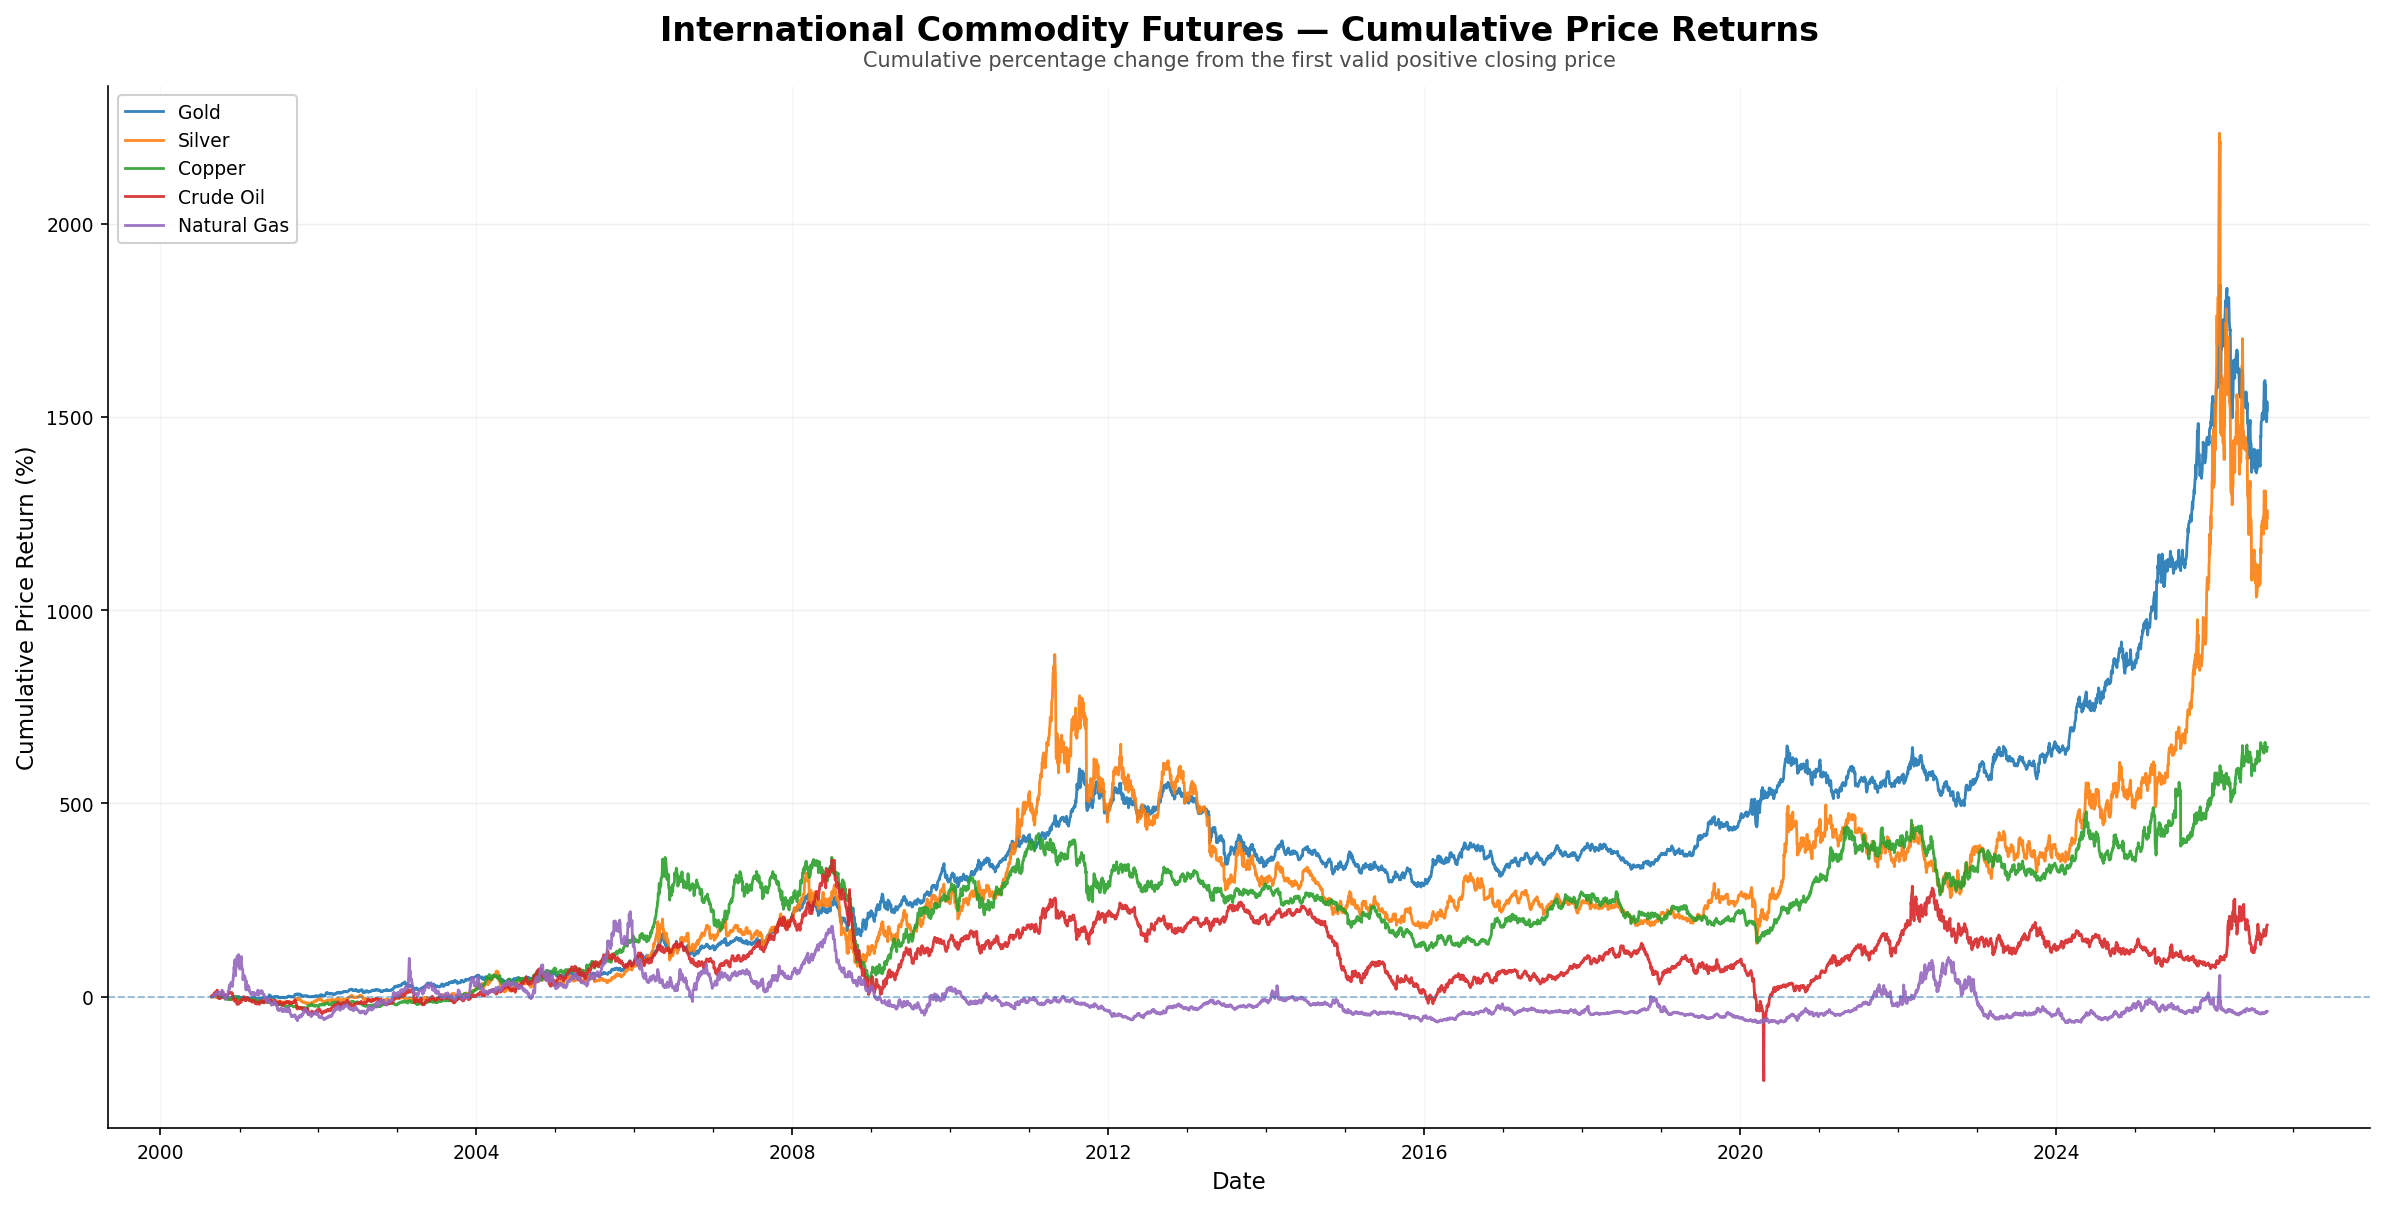

FIGURE 01 — CUMULATIVE COMMODITY PRICE RETURNS

Output:
  C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_01_Cumulative_Commodity_Price_Returns.png

Representation:
  Underlying commodity price return: YES
  Strategy return: NO
  Strategy equity curve: NO
  Portfolio return: NO
  Starting reference: 0%
  First valid positive close: 0% cumulative return

Starting-point validation:
  Commodity First_Positive_Date  Starting_Return
       GOLD          2000-08-30              0.0
     SILVER          2000-08-30              0.0
     COPPER          2000-08-30              0.0
  CRUDE_OIL          2000-08-23              0.0
NATURAL_GAS          2000-08-30              0.0

Commodity summary:
  Commodity First_Positive_Date  First_Positive_Close  Observations  Minimum_Cumulative_Return  Maximum_Cumulative_Return
       GOLD          2000-08-30            273.899994          6528                  -6.863815                1841.730566
     SILVER          2000-08-30   

In [4]:
# ============================================================
# FIGURE 01 — CUMULATIVE COMMODITY PRICE RETURNS
# International Commodity Futures Strategy Archetypes
# ============================================================
#
# Purpose:
#   Show the long-run cumulative price change of the five
#   international commodity futures from their first valid
#   positive closing price.
#
# IMPORTANT:
#   This is NOT a strategy equity curve.
#   This is NOT a portfolio return.
#   It represents cumulative change in the underlying
#   commodity price.
#
# Formula:
#   Cumulative Price Return (%) =
#       ((Current Close / Initial Positive Close) - 1) * 100
#
# Data source:
#   Frozen market-data datasets loaded in Block 1.
#
# No data is downloaded.
# No research data is modified.
# ============================================================


# ------------------------------------------------------------
# 1. Imports
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ------------------------------------------------------------
# 2. Output path
# ------------------------------------------------------------

FIGURE_01_PATH = (
    FIGURE_ROOT /
    "Figure_01_Cumulative_Commodity_Price_Returns.png"
)


# ------------------------------------------------------------
# 3. Commodity datasets
# ------------------------------------------------------------

COMMODITY_DATA = {
    "GOLD": GOLD_DAILY,
    "SILVER": SILVER_DAILY,
    "COPPER": COPPER_DAILY,
    "CRUDE_OIL": CRUDE_DAILY,
    "NATURAL_GAS": NATURAL_GAS_DAILY,
}


DISPLAY_NAMES = {
    "GOLD": "Gold",
    "SILVER": "Silver",
    "COPPER": "Copper",
    "CRUDE_OIL": "Crude Oil",
    "NATURAL_GAS": "Natural Gas",
}


# ------------------------------------------------------------
# 4. Prepare cumulative price-return series
# ------------------------------------------------------------

return_series = {}

normalization_info = []


for commodity, df in COMMODITY_DATA.items():

    data = df.copy()

    # --------------------------------------------------------
    # Identify date column
    # --------------------------------------------------------

    possible_date_columns = [
        "Date",
        "date",
        "Datetime",
        "datetime",
    ]

    date_col = next(
        (
            col
            for col in possible_date_columns
            if col in data.columns
        ),
        None
    )

    if date_col is None:
        raise KeyError(
            f"{commodity}: Date column could not be identified."
        )


    # --------------------------------------------------------
    # Identify close column
    # --------------------------------------------------------

    possible_close_columns = [
        "Close",
        "close",
    ]

    close_col = next(
        (
            col
            for col in possible_close_columns
            if col in data.columns
        ),
        None
    )

    if close_col is None:
        raise KeyError(
            f"{commodity}: Close column could not be identified."
        )


    # --------------------------------------------------------
    # Keep only required fields
    # --------------------------------------------------------

    data = data[
        [date_col, close_col]
    ].copy()

    data.columns = [
        "Date",
        "Close",
    ]


    # --------------------------------------------------------
    # Data types
    # --------------------------------------------------------

    data["Date"] = pd.to_datetime(
        data["Date"],
        errors="coerce",
    )

    data["Close"] = pd.to_numeric(
        data["Close"],
        errors="coerce",
    )


    # --------------------------------------------------------
    # Basic cleaning
    # --------------------------------------------------------

    data = (
        data
        .dropna(subset=["Date", "Close"])
        .sort_values("Date")
        .drop_duplicates("Date")
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # First valid positive closing price
    # --------------------------------------------------------
    #
    # This is important because crude oil contains the
    # documented negative-price observation on 20 Apr 2020.
    #
    # We retain that observation in the series.
    # We only use the first positive price as the starting
    # reference for calculating the cumulative price return.
    # --------------------------------------------------------

    positive_data = data.loc[
        data["Close"] > 0
    ].copy()

    if positive_data.empty:
        raise ValueError(
            f"{commodity}: No positive closing price available."
        )

    first_positive_price = positive_data.iloc[0]["Close"]
    first_positive_date = positive_data.iloc[0]["Date"]


    # --------------------------------------------------------
    # Cumulative price return
    # --------------------------------------------------------

    data["Cumulative_Price_Return"] = (
        (
            data["Close"] /
            first_positive_price
        ) - 1.0
    ) * 100.0


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    return_series[commodity] = data


    # --------------------------------------------------------
    # Audit information
    # --------------------------------------------------------

    normalization_info.append({
        "Commodity": commodity,
        "First_Positive_Date": first_positive_date,
        "First_Positive_Close": first_positive_price,
        "Observations": len(data),
        "Minimum_Cumulative_Return": (
            data["Cumulative_Price_Return"].min()
        ),
        "Maximum_Cumulative_Return": (
            data["Cumulative_Price_Return"].max()
        ),
    })


normalization_info = pd.DataFrame(
    normalization_info
)


# ------------------------------------------------------------
# 5. Validate starting point
# ------------------------------------------------------------

validation_rows = []


for commodity, data in return_series.items():

    first_positive_row = data.loc[
        data["Close"] > 0
    ].iloc[0]

    validation_rows.append({
        "Commodity": commodity,
        "First_Positive_Date": first_positive_row["Date"],
        "Starting_Return": (
            first_positive_row[
                "Cumulative_Price_Return"
            ]
        ),
    })


validation_df = pd.DataFrame(
    validation_rows
)


max_starting_error = (
    validation_df["Starting_Return"]
    .abs()
    .max()
)


assert max_starting_error < 1e-10, (
    "Starting cumulative return is not zero."
)


# ------------------------------------------------------------
# 6. Publication-quality plotting configuration
# ------------------------------------------------------------

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 16,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})


# ------------------------------------------------------------
# 7. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(16, 8.5)
)


# ------------------------------------------------------------
# 8. Plot cumulative price returns
# ------------------------------------------------------------

for commodity, data in return_series.items():

    ax.plot(
        data["Date"],
        data["Cumulative_Price_Return"],
        linewidth=1.35,
        alpha=0.90,
        label=DISPLAY_NAMES[commodity],
    )


# ------------------------------------------------------------
# 9. Zero-return reference line
# ------------------------------------------------------------

ax.axhline(
    0,
    linewidth=0.9,
    linestyle="--",
    alpha=0.45,
)


# ------------------------------------------------------------
# 10. Title
# ------------------------------------------------------------

ax.set_title(
    "International Commodity Futures — Cumulative Price Returns",
    pad=22,
    fontweight="bold",
)


ax.text(
    0.5,
    1.015,
    "Cumulative percentage change from the first valid positive closing price",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    alpha=0.70,
)


# ------------------------------------------------------------
# 11. Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Cumulative Price Return (%)"
)


# ------------------------------------------------------------
# 12. Date formatting
# ------------------------------------------------------------

ax.xaxis.set_major_locator(
    mdates.YearLocator(4)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.xaxis.set_minor_locator(
    mdates.YearLocator(1)
)


# ------------------------------------------------------------
# 13. Grid
# ------------------------------------------------------------

ax.grid(
    axis="y",
    alpha=0.20,
    linewidth=0.7,
)

ax.grid(
    axis="x",
    alpha=0.10,
    linewidth=0.6,
)


# ------------------------------------------------------------
# 14. Clean chart frame
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ------------------------------------------------------------
# 15. Legend
# ------------------------------------------------------------

ax.legend(
    loc="upper left",
    frameon=True,
    framealpha=0.90,
)


# ------------------------------------------------------------
# 16. Layout
# ------------------------------------------------------------

fig.tight_layout(
    rect=[0, 0, 1, 0.96]
)


# ------------------------------------------------------------
# 17. Save publication-quality figure
# ------------------------------------------------------------

fig.savefig(
    FIGURE_01_PATH,
    bbox_inches="tight",
    facecolor="white",
)


# ------------------------------------------------------------
# 18. Display
# ------------------------------------------------------------

plt.show()


# ------------------------------------------------------------
# 19. Validation / audit output
# ------------------------------------------------------------

print("=" * 72)
print("FIGURE 01 — CUMULATIVE COMMODITY PRICE RETURNS")
print("=" * 72)

print("\nOutput:")
print(f"  {FIGURE_01_PATH}")


print("\nRepresentation:")
print("  Underlying commodity price return: YES")
print("  Strategy return: NO")
print("  Strategy equity curve: NO")
print("  Portfolio return: NO")
print("  Starting reference: 0%")
print("  First valid positive close: 0% cumulative return")


print("\nStarting-point validation:")

print(
    validation_df.to_string(
        index=False
    )
)


print("\nCommodity summary:")

print(
    normalization_info.to_string(
        index=False
    )
)


print("\nData integrity:")
print("  Source data modified: NO")
print("  Data downloaded: NO")
print("  Research calculations rerun: NO")
print("  Crude negative-price observation removed: NO")


print("\nValidation:")
print(
    f"  Maximum starting-point error: "
    f"{max_starting_error:.12f}"
)


print("\n🟢 FIGURE 01 COMPLETE")

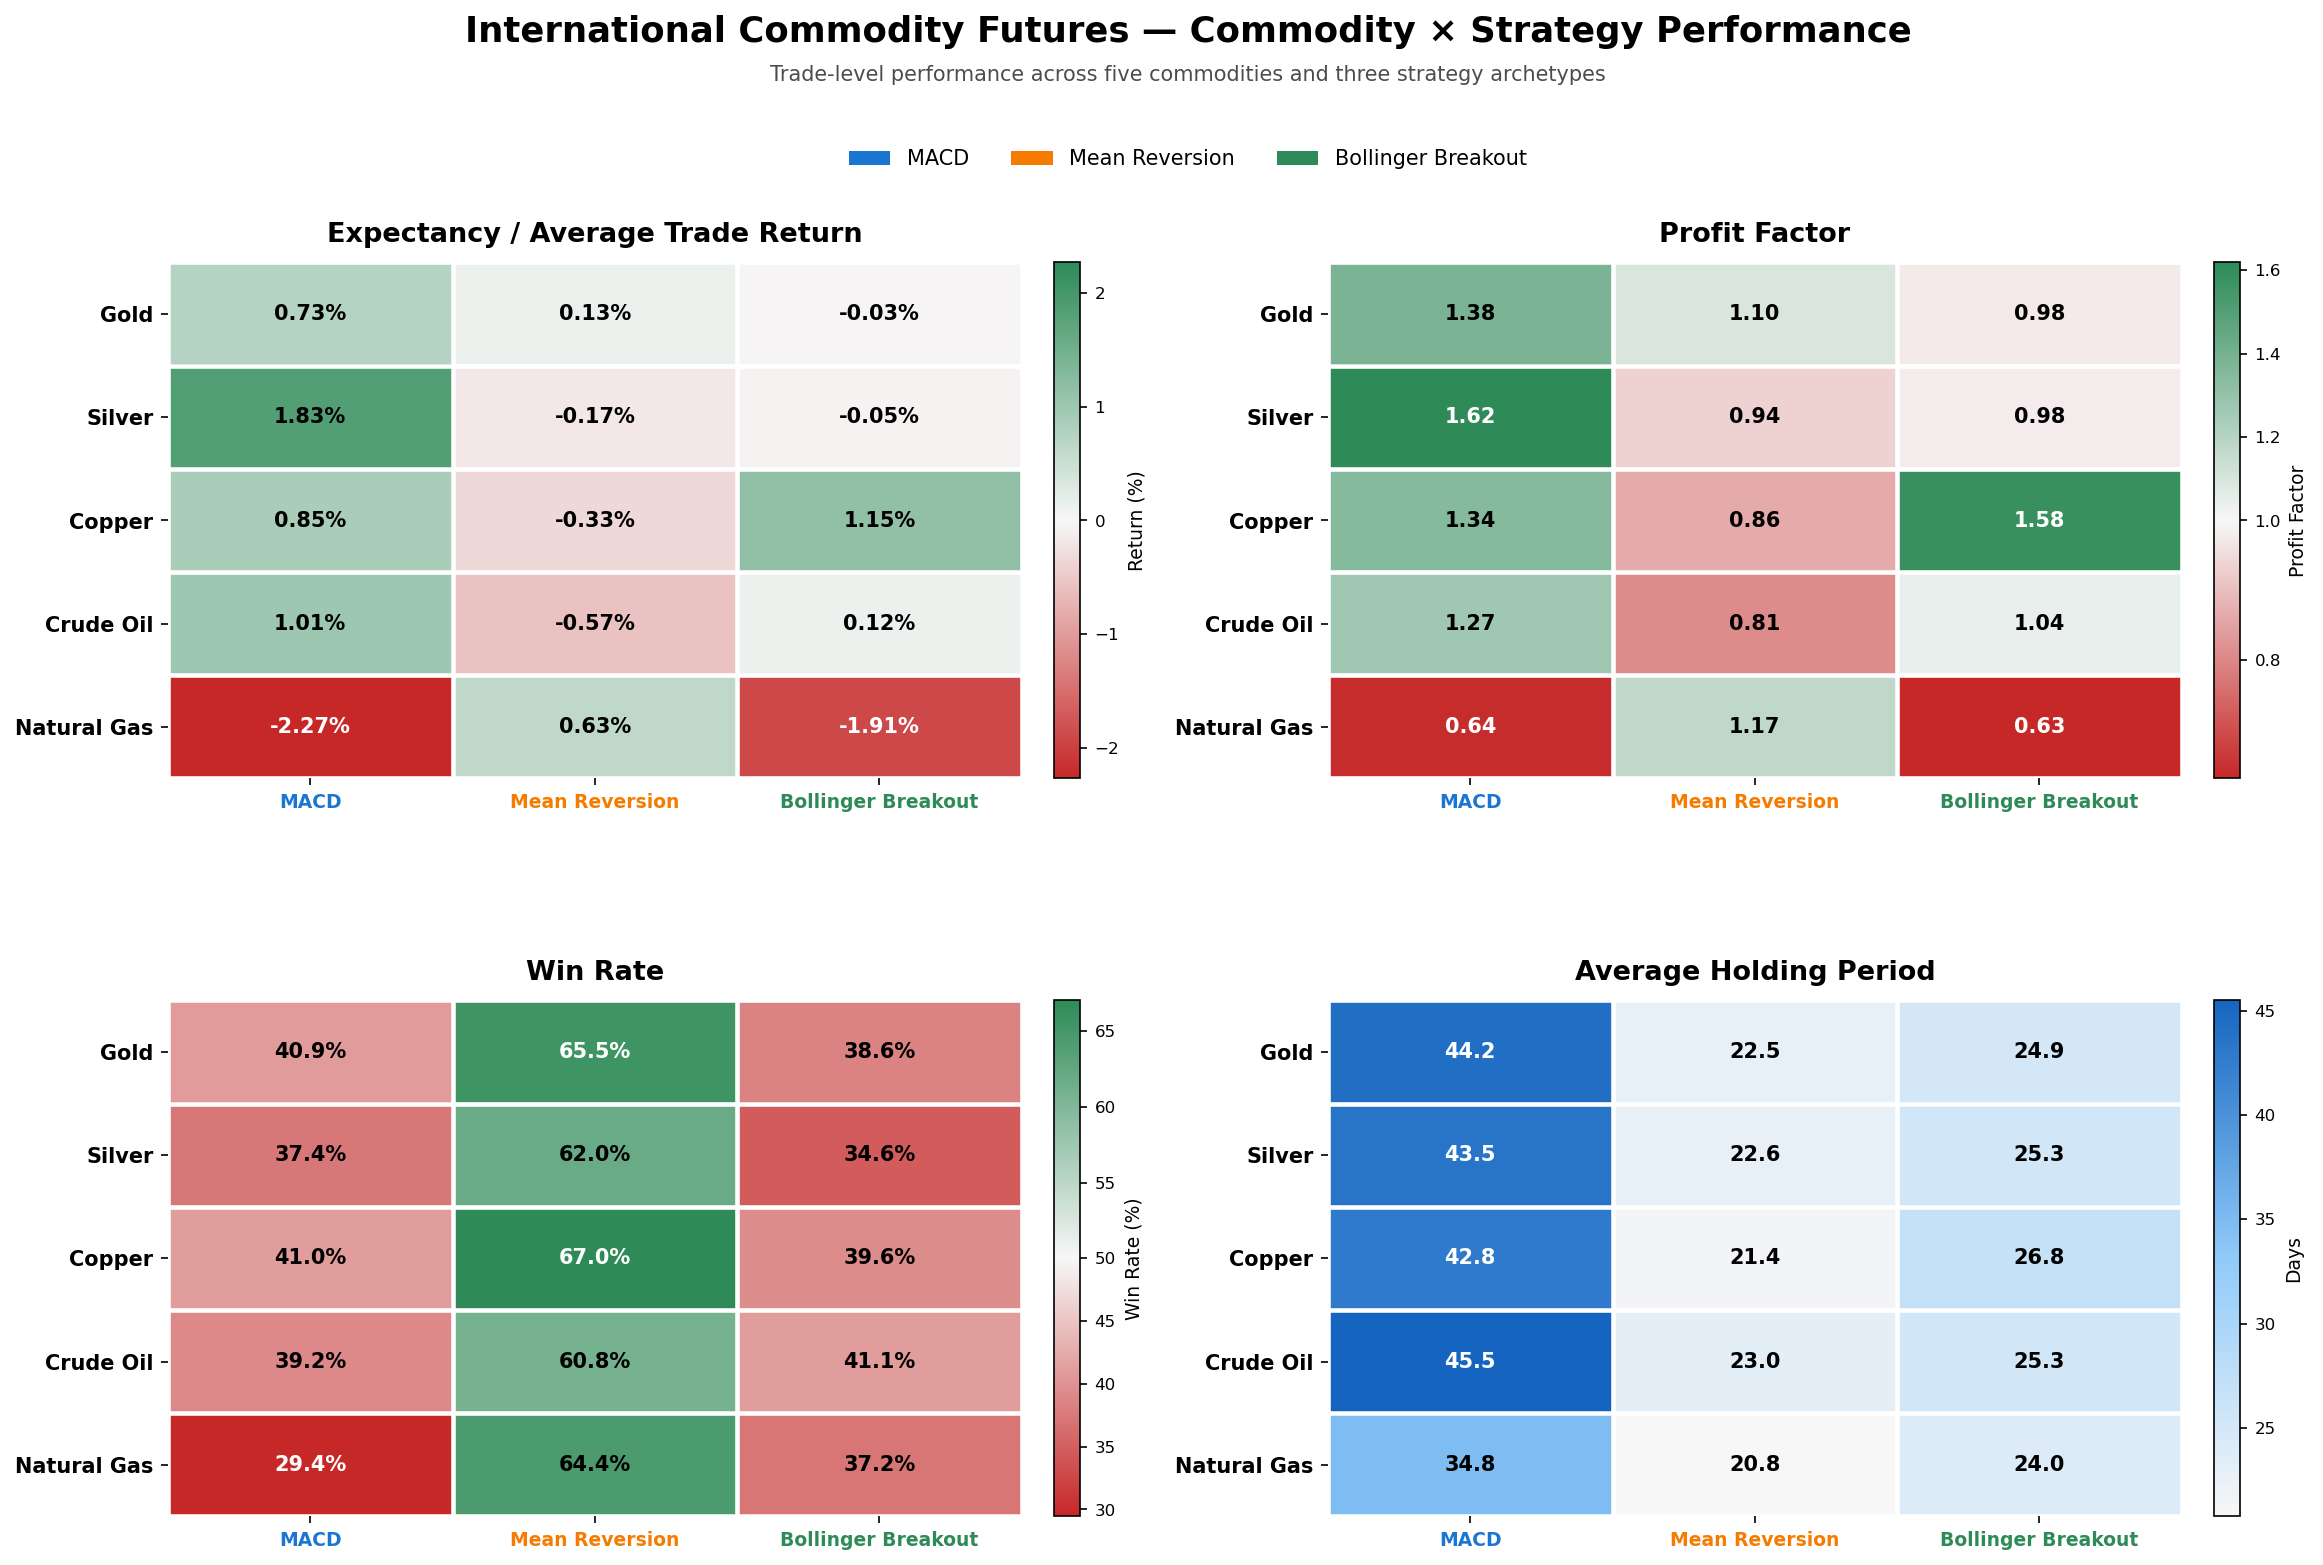

COMMODITY × STRATEGY PERFORMANCE MATRIX

Output:
  PNG: C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_02_Commodity_Strategy_Performance_Matrix.png
  SVG: C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_02_Commodity_Strategy_Performance_Matrix.svg

Structure:
  Commodities: 5
  Strategies: 3
  Metrics: 4
  Total cells: 60

Strategy identity colours:
  MACD Trend Following  → Blue
  Mean Reversion        → Orange
  Bollinger Breakout    → Green

Quantitative colour logic:
  Expectancy: 0% = neutral
  Profit Factor: 1.00 = break-even
  Win Rate: 50% = descriptive reference
  Holding Period: magnitude scale

Visual design:
  Strategy colours: categorical
  Heatmap colours: quantitative
  Panel subtitles: REMOVED
  Strategy marker bars: REMOVED
  Strategy identity: coloured labels + legend
  Figure number in image: NO

Data integrity:
  Source: Frozen research matrices
  Strategy rerun: NO
  Optimization: NO
  Trade data modified: NO
  Res

In [12]:
# ============================================================
# COMMODITY × STRATEGY PERFORMANCE
# International Commodity Futures Strategy Archetypes
# ============================================================
#
# CLEAN FINAL VERSION
#
# Strategy identity:
#   MACD Trend Following -> Blue
#   Mean Reversion       -> Orange
#   Bollinger Breakout   -> Green
#
# Quantitative performance:
#   Heatmap colour -> metric-specific performance
#
# IMPORTANT:
#   Strategy colours identify the strategy.
#   Heatmap colours communicate the numerical metric.
#
# DESIGN:
#   - No panel subtitles
#   - No strategy marker bars
#   - No Figure number inside image
#   - Strategy identity shown through coloured labels + legend
#   - Metric meaning shown through panel title + colourbar
#
# SOURCE:
#   Frozen research matrices loaded in Block 1.
#
# NO:
#   - strategy rerun
#   - optimization
#   - trade modification
#   - research statistic recalculation
# ============================================================


# ------------------------------------------------------------
# 1. Imports
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import (
    LinearSegmentedColormap,
    TwoSlopeNorm,
)

from matplotlib.patches import Rectangle


# ------------------------------------------------------------
# 2. Output paths
# ------------------------------------------------------------

FIGURE_02_PNG = (
    FIGURE_ROOT /
    "Figure_02_Commodity_Strategy_Performance_Matrix.png"
)

FIGURE_02_SVG = (
    FIGURE_ROOT /
    "Figure_02_Commodity_Strategy_Performance_Matrix.svg"
)


# ------------------------------------------------------------
# 3. Strategy configuration
# ------------------------------------------------------------

STRATEGIES = [
    "MACD Trend Following",
    "Mean Reversion",
    "Bollinger Breakout",
]


STRATEGY_SHORT_NAMES = {
    "MACD Trend Following": "MACD",
    "Mean Reversion": "Mean Reversion",
    "Bollinger Breakout": "Bollinger Breakout",
}


# ------------------------------------------------------------
# Strategy identity colours
# ------------------------------------------------------------
#
# These colours identify strategies only.
# They do NOT encode performance.
# ------------------------------------------------------------

STRATEGY_COLORS = {
    "MACD Trend Following": "#1976D2",
    "Mean Reversion": "#F57C00",
    "Bollinger Breakout": "#2E8B57",
}


# ------------------------------------------------------------
# 4. Commodity configuration
# ------------------------------------------------------------

COMMODITIES = [
    "GOLD",
    "SILVER",
    "COPPER",
    "CRUDE_OIL",
    "NATURAL_GAS",
]


COMMODITY_DISPLAY = {
    "GOLD": "Gold",
    "SILVER": "Silver",
    "COPPER": "Copper",
    "CRUDE_OIL": "Crude Oil",
    "NATURAL_GAS": "Natural Gas",
}


# ------------------------------------------------------------
# 5. Quantitative colour maps
# ------------------------------------------------------------

# Performance:
#
#   Red   = weaker
#   White = neutral
#   Green = stronger
#
# Used for metrics with meaningful reference points.

performance_cmap = LinearSegmentedColormap.from_list(
    "performance",
    [
        "#C62828",
        "#F7F7F7",
        "#2E8B57",
    ],
)


# Holding period:
#
# This is descriptive rather than positive/negative.
# Therefore a sequential scale is used.

holding_cmap = LinearSegmentedColormap.from_list(
    "holding",
    [
        "#F7F7F7",
        "#90CAF9",
        "#1565C0",
    ],
)


# ------------------------------------------------------------
# 6. Helper — identify commodity column
# ------------------------------------------------------------

def identify_commodity_column(df):

    candidates = [
        "Commodity",
        "commodity",
        "Ticker",
        "ticker",
    ]

    for column in candidates:

        if column in df.columns:
            return column

    raise KeyError(
        "Could not identify commodity column.\n"
        f"Available columns: {df.columns.tolist()}"
    )


# ------------------------------------------------------------
# 7. Helper — standardize frozen matrix
# ------------------------------------------------------------

def standardize_matrix(
    df,
    metric_name,
):

    data = df.copy()

    commodity_column = (
        identify_commodity_column(data)
    )


    # --------------------------------------------------------
    # Verify strategy columns
    # --------------------------------------------------------

    missing_strategies = [
        strategy
        for strategy in STRATEGIES
        if strategy not in data.columns
    ]

    if missing_strategies:

        raise KeyError(
            f"{metric_name}: Missing strategy columns: "
            f"{missing_strategies}\n\n"
            f"Available columns:\n"
            f"{data.columns.tolist()}"
        )


    # --------------------------------------------------------
    # Keep required columns
    # --------------------------------------------------------

    data = data[
        [
            commodity_column,
            *STRATEGIES,
        ]
    ].copy()


    data = data.rename(
        columns={
            commodity_column: "Commodity"
        }
    )


    # --------------------------------------------------------
    # Standardize commodity names
    # --------------------------------------------------------

    data["Commodity"] = (
        data["Commodity"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({
            "CRUDE OIL": "CRUDE_OIL",
            "NATURAL GAS": "NATURAL_GAS",
        })
    )


    # --------------------------------------------------------
    # Numeric conversion
    # --------------------------------------------------------

    for strategy in STRATEGIES:

        data[strategy] = pd.to_numeric(
            data[strategy],
            errors="coerce",
        )


    # --------------------------------------------------------
    # Validate commodity coverage
    # --------------------------------------------------------

    missing_commodities = [
        commodity
        for commodity in COMMODITIES
        if commodity not in data["Commodity"].values
    ]

    if missing_commodities:

        raise ValueError(
            f"{metric_name}: Missing commodities: "
            f"{missing_commodities}"
        )


    # --------------------------------------------------------
    # Reorder commodities
    # --------------------------------------------------------

    data["Commodity_Order"] = (
        data["Commodity"]
        .map({
            commodity: i
            for i, commodity
            in enumerate(COMMODITIES)
        })
    )


    data = (
        data
        .sort_values("Commodity_Order")
        .drop(columns="Commodity_Order")
        .reset_index(drop=True)
    )


    # --------------------------------------------------------
    # Final validation
    # --------------------------------------------------------

    assert len(data) == 5, (
        f"{metric_name}: Expected 5 commodities."
    )

    assert (
        data["Commodity"].tolist()
        == COMMODITIES
    ), (
        f"{metric_name}: Commodity ordering failed."
    )

    assert (
        data[STRATEGIES]
        .notna()
        .all()
        .all()
    ), (
        f"{metric_name}: Missing metric values."
    )


    return data


# ------------------------------------------------------------
# 8. Load frozen matrices
# ------------------------------------------------------------

expectancy_df = standardize_matrix(
    EXPECTANCY_MATRIX,
    "Expectancy",
)


profit_factor_df = standardize_matrix(
    PROFIT_FACTOR_MATRIX,
    "Profit Factor",
)


win_rate_df = standardize_matrix(
    WIN_RATE_MATRIX,
    "Win Rate",
)


holding_period_df = standardize_matrix(
    HOLDING_PERIOD_MATRIX,
    "Holding Period",
)


# ------------------------------------------------------------
# 9. Convert to numerical arrays
# ------------------------------------------------------------

expectancy_values = (
    expectancy_df[STRATEGIES]
    .to_numpy(dtype=float)
)


profit_factor_values = (
    profit_factor_df[STRATEGIES]
    .to_numpy(dtype=float)
)


win_rate_values = (
    win_rate_df[STRATEGIES]
    .to_numpy(dtype=float)
)


holding_values = (
    holding_period_df[STRATEGIES]
    .to_numpy(dtype=float)
)


# ------------------------------------------------------------
# 10. Win-rate representation
# ------------------------------------------------------------

if np.nanmax(win_rate_values) <= 1.0:

    win_rate_values = (
        win_rate_values * 100.0
    )


# ------------------------------------------------------------
# 11. Metric-specific normalization
# ------------------------------------------------------------

# ============================================================
# EXPECTANCY
# ============================================================
#
# 0% = neutral
# ============================================================

expectancy_limit = max(
    abs(np.nanmin(expectancy_values)),
    abs(np.nanmax(expectancy_values)),
)


expectancy_norm = TwoSlopeNorm(
    vmin=-expectancy_limit,
    vcenter=0.0,
    vmax=expectancy_limit,
)


# ============================================================
# PROFIT FACTOR
# ============================================================
#
# 1.00 = break-even
# ============================================================

pf_min = np.nanmin(
    profit_factor_values
)

pf_max = np.nanmax(
    profit_factor_values
)


profit_factor_norm = TwoSlopeNorm(
    vmin=min(
        pf_min,
        1.0,
    ),
    vcenter=1.0,
    vmax=max(
        pf_max,
        1.0,
    ),
)


# ============================================================
# WIN RATE
# ============================================================
#
# 50% = descriptive reference
# ============================================================

win_min = np.nanmin(
    win_rate_values
)

win_max = np.nanmax(
    win_rate_values
)


win_rate_norm = TwoSlopeNorm(
    vmin=min(
        win_min,
        50.0,
    ),
    vcenter=50.0,
    vmax=max(
        win_max,
        50.0,
    ),
)


# ============================================================
# HOLDING PERIOD
# ============================================================

holding_norm = plt.Normalize(
    vmin=np.nanmin(
        holding_values
    ),
    vmax=np.nanmax(
        holding_values
    ),
)


# ------------------------------------------------------------
# 12. Plot configuration
# ------------------------------------------------------------

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})


# ------------------------------------------------------------
# 13. Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 11),
)


# ------------------------------------------------------------
# 14. Heatmap function
# ------------------------------------------------------------

def draw_heatmap(
    ax,
    values,
    title,
    cmap,
    norm,
    formatter,
    colorbar_label,
):
    """
    Draw a clean publication-quality heatmap.

    Strategy identity:
        - coloured x-axis labels
        - common legend

    Quantitative meaning:
        - heatmap colour

    No panel subtitles are used. This prevents text
    collisions and keeps the visual hierarchy clean.
    """


    # --------------------------------------------------------
    # Heatmap
    # --------------------------------------------------------

    image = ax.imshow(
        values,
        cmap=cmap,
        norm=norm,
        aspect="auto",
    )


    # --------------------------------------------------------
    # Commodity labels
    # --------------------------------------------------------

    ax.set_yticks(
        np.arange(
            len(COMMODITIES)
        )
    )

    ax.set_yticklabels(
        [
            COMMODITY_DISPLAY[c]
            for c in COMMODITIES
        ],
        fontsize=10,
        fontweight="bold",
    )


    # --------------------------------------------------------
    # Strategy labels
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(
            len(STRATEGIES)
        )
    )

    ax.set_xticklabels(
        [
            STRATEGY_SHORT_NAMES[s]
            for s in STRATEGIES
        ],
        fontsize=9,
        fontweight="bold",
    )


    # --------------------------------------------------------
    # Strategy-specific label colours
    # --------------------------------------------------------

    for index, strategy in enumerate(
        STRATEGIES
    ):

        ax.get_xticklabels()[index].set_color(
            STRATEGY_COLORS[strategy]
        )


    # --------------------------------------------------------
    # Cell boundaries
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(
            -0.5,
            len(STRATEGIES),
            1,
        ),
        minor=True,
    )

    ax.set_yticks(
        np.arange(
            -0.5,
            len(COMMODITIES),
            1,
        ),
        minor=True,
    )


    ax.grid(
        which="minor",
        color="white",
        linewidth=2.2,
    )


    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )


    # --------------------------------------------------------
    # Cell annotations
    # --------------------------------------------------------

    for row in range(
        values.shape[0]
    ):

        for col in range(
            values.shape[1]
        ):

            value = values[row, col]

            text = formatter(
                value
            )


            rgba = cmap(
                norm(value)
            )


            # Perceived luminance
            luminance = (
                0.299 * rgba[0]
                + 0.587 * rgba[1]
                + 0.114 * rgba[2]
            )


            text_color = (
                "white"
                if luminance < 0.48
                else "black"
            )


            ax.text(
                col,
                row,
                text,
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                color=text_color,
            )


    # --------------------------------------------------------
    # Panel title
    # --------------------------------------------------------

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold",
        pad=10,
    )


    # --------------------------------------------------------
    # Clean frame
    # --------------------------------------------------------

    for spine in ax.spines.values():

        spine.set_visible(False)


    # --------------------------------------------------------
    # Colourbar
    # --------------------------------------------------------

    cbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.045,
        pad=0.035,
    )


    cbar.set_label(
        colorbar_label,
        fontsize=9,
    )


    cbar.ax.tick_params(
        labelsize=8,
    )


    return image


# ============================================================
# 15. PANEL A — EXPECTANCY
# ============================================================

draw_heatmap(
    axes[0, 0],
    expectancy_values,
    "Expectancy / Average Trade Return",
    performance_cmap,
    expectancy_norm,
    lambda x: f"{x:.2f}%",
    "Return (%)",
)


# ============================================================
# 16. PANEL B — PROFIT FACTOR
# ============================================================

draw_heatmap(
    axes[0, 1],
    profit_factor_values,
    "Profit Factor",
    performance_cmap,
    profit_factor_norm,
    lambda x: f"{x:.2f}",
    "Profit Factor",
)


# ============================================================
# 17. PANEL C — WIN RATE
# ============================================================

draw_heatmap(
    axes[1, 0],
    win_rate_values,
    "Win Rate",
    performance_cmap,
    win_rate_norm,
    lambda x: f"{x:.1f}%",
    "Win Rate (%)",
)


# ============================================================
# 18. PANEL D — AVERAGE HOLDING PERIOD
# ============================================================

draw_heatmap(
    axes[1, 1],
    holding_values,
    "Average Holding Period",
    holding_cmap,
    holding_norm,
    lambda x: f"{x:.1f}",
    "Days",
)


# ------------------------------------------------------------
# 19. Main title
# ------------------------------------------------------------

fig.suptitle(
    "International Commodity Futures — Commodity × Strategy Performance",
    fontsize=17,
    fontweight="bold",
    y=0.975,
)


# ------------------------------------------------------------
# 20. Overall subtitle
# ------------------------------------------------------------

fig.text(
    0.5,
    0.945,
    "Trade-level performance across five commodities and three strategy archetypes",
    ha="center",
    va="top",
    fontsize=10,
    alpha=0.70,
)


# ------------------------------------------------------------
# 21. Strategy legend
# ------------------------------------------------------------

legend_handles = []

for strategy in STRATEGIES:

    legend_handles.append(
        Rectangle(
            (
                0,
                0,
            ),
            1,
            1,
            facecolor=STRATEGY_COLORS[strategy],
            edgecolor="none",
            label=STRATEGY_SHORT_NAMES[strategy],
        )
    )


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        0.905,
    ),
    ncol=3,
    frameon=False,
    fontsize=10,
)


# ------------------------------------------------------------
# 22. Layout
# ------------------------------------------------------------
#
# Extra space is deliberately reserved above the two rows
# so the global title, subtitle and legend never collide
# with the panel titles.
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.075,
    right=0.945,
    bottom=0.065,
    top=0.825,
    wspace=0.25,
    hspace=0.43,
)


# ------------------------------------------------------------
# 23. Save PNG
# ------------------------------------------------------------

fig.savefig(
    FIGURE_02_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)


# ------------------------------------------------------------
# 24. Save SVG
# ------------------------------------------------------------

fig.savefig(
    FIGURE_02_SVG,
    bbox_inches="tight",
    facecolor="white",
)


# ------------------------------------------------------------
# 25. Display
# ------------------------------------------------------------

plt.show()


# ------------------------------------------------------------
# 26. Validation
# ------------------------------------------------------------

print("=" * 72)
print("COMMODITY × STRATEGY PERFORMANCE MATRIX")
print("=" * 72)

print("\nOutput:")
print(f"  PNG: {FIGURE_02_PNG}")
print(f"  SVG: {FIGURE_02_SVG}")

print("\nStructure:")
print("  Commodities: 5")
print("  Strategies: 3")
print("  Metrics: 4")
print("  Total cells: 60")

print("\nStrategy identity colours:")
print("  MACD Trend Following  → Blue")
print("  Mean Reversion        → Orange")
print("  Bollinger Breakout    → Green")

print("\nQuantitative colour logic:")
print("  Expectancy: 0% = neutral")
print("  Profit Factor: 1.00 = break-even")
print("  Win Rate: 50% = descriptive reference")
print("  Holding Period: magnitude scale")

print("\nVisual design:")
print("  Strategy colours: categorical")
print("  Heatmap colours: quantitative")
print("  Panel subtitles: REMOVED")
print("  Strategy marker bars: REMOVED")
print("  Strategy identity: coloured labels + legend")
print("  Figure number in image: NO")

print("\nData integrity:")
print("  Source: Frozen research matrices")
print("  Strategy rerun: NO")
print("  Optimization: NO")
print("  Trade data modified: NO")
print("  Research statistics recalculated: NO")

print("\nValidation:")
print("  Commodity coverage: PASS")
print("  Strategy coverage: PASS")
print("  Expectancy matrix: PASS")
print("  Profit Factor matrix: PASS")
print("  Win Rate matrix: PASS")
print("  Holding Period matrix: PASS")

print("\n🟢 COMMODITY × STRATEGY PERFORMANCE MATRIX COMPLETE")

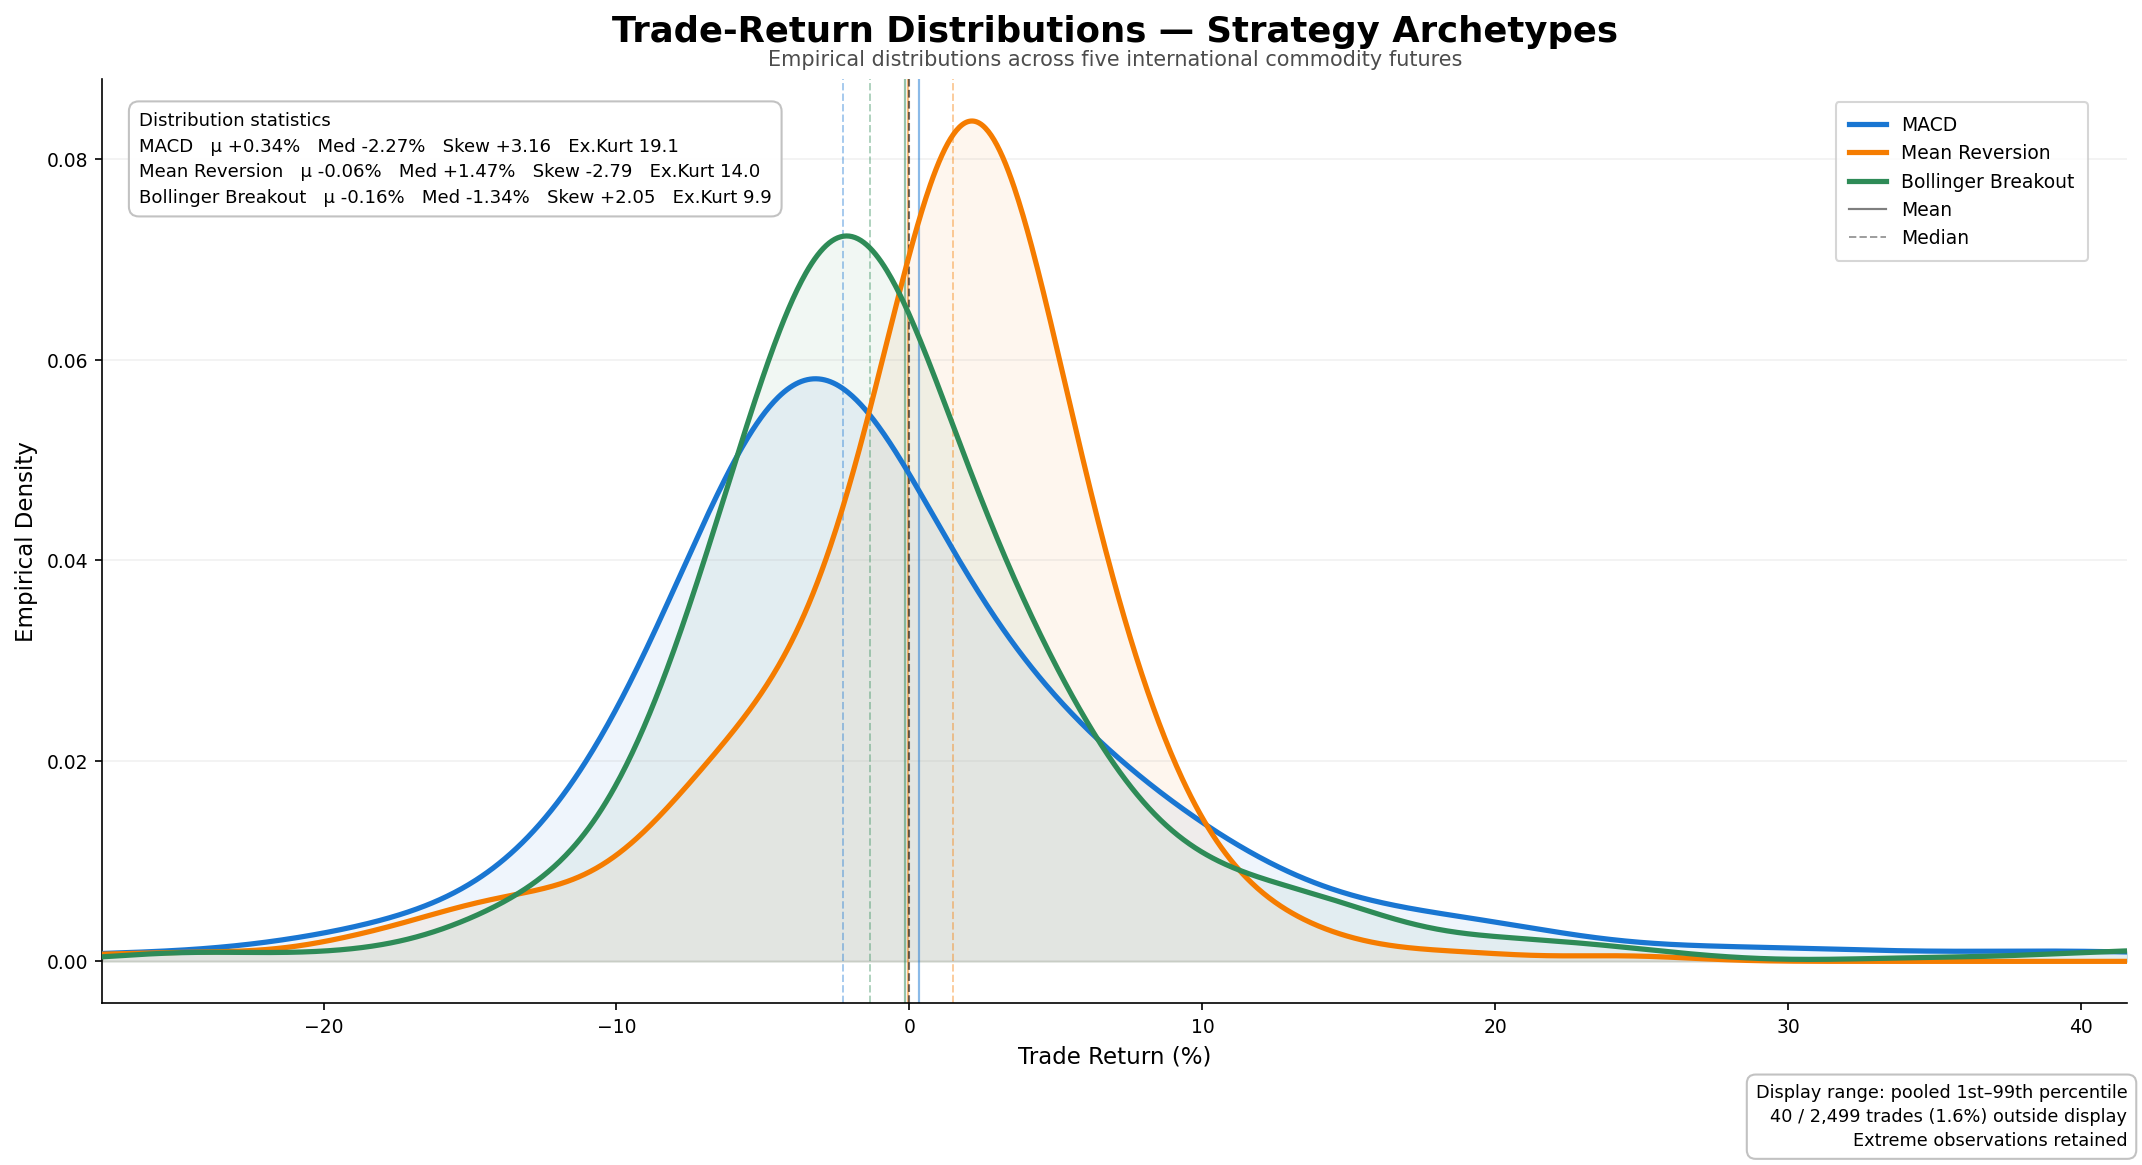

FIGURE 03 — RETURN DISTRIBUTION & TAIL BEHAVIOUR

Output:
  PNG: C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_03_Return_Distribution_Tail_Behaviour.png
  SVG: C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_03_Return_Distribution_Tail_Behaviour.svg

Representation:
  Distribution: empirical KDE
  Normality assumption: NO
  Normal-reference curve: NO
  Mean: solid vertical marker
  Median: dashed vertical marker
  Zero-return reference: YES
  Main display: pooled 1st–99th percentile
  Extreme observations removed: NO
  Extreme observations modified: NO
  Figure number inside image: NO
  Tail annotation: outside plotting area

Strategy coverage:
  MACD               N= 793 | Mean= +0.341% | Median= -2.275% | Skew= +3.16 | Ex.Kurt=  19.11
  Mean Reversion     N= 980 | Mean= -0.056% | Median= +1.474% | Skew= -2.79 | Ex.Kurt=  14.04
  Bollinger Breakout N= 726 | Mean= -0.163% | Median= -1.339% | Skew= +2.05 | Ex.Kurt=   9.88

Display rang

In [16]:
# ============================================================
# FIGURE 03 — RETURN DISTRIBUTION & TAIL BEHAVIOUR
# FINAL CLEAN VERSION
# ============================================================
#
# PURPOSE:
#   Visualize empirical trade-level return distributions for
#   the three strategy archetypes across all five commodities.
#
# DESIGN:
#   MACD              = Blue
#   Mean Reversion    = Orange
#   Bollinger         = Green
#
#   Empirical KDE distributions
#   Mean = solid vertical marker
#   Median = dashed vertical marker
#   Zero return = black dashed reference
#
#   Main display range = pooled 1st–99th percentile
#
# IMPORTANT:
#   Extreme observations are NOT removed, winsorized or capped.
#   The display range is only a visual readability decision.
#
# OUTPUT:
#   PNG + SVG
#
# NO:
#   - strategy rerun
#   - optimization
#   - winsorization
#   - return capping
#   - trade removal
#   - transaction-cost assumptions
# ============================================================


# ------------------------------------------------------------
# 1. Imports
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde, skew, kurtosis
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# 2. Output paths
# ------------------------------------------------------------

FIGURE_03_PNG = (
    FIGURE_ROOT /
    "Figure_03_Return_Distribution_Tail_Behaviour.png"
)

FIGURE_03_SVG = (
    FIGURE_ROOT /
    "Figure_03_Return_Distribution_Tail_Behaviour.svg"
)


# ------------------------------------------------------------
# 3. Strategy configuration
# ------------------------------------------------------------

STRATEGIES = [
    "MACD Trend Following",
    "Mean Reversion",
    "Bollinger Breakout",
]


STRATEGY_SHORT_NAMES = {
    "MACD Trend Following": "MACD",
    "Mean Reversion": "Mean Reversion",
    "Bollinger Breakout": "Bollinger Breakout",
}


STRATEGY_COLORS = {
    "MACD Trend Following": "#1976D2",
    "Mean Reversion": "#F57C00",
    "Bollinger Breakout": "#2E8B57",
}


# ------------------------------------------------------------
# 4. Load frozen master trade log
# ------------------------------------------------------------

trades = MASTER_TRADES.copy()


# ------------------------------------------------------------
# 5. Validate required columns
# ------------------------------------------------------------

required_columns = [
    "Strategy",
    "Return %",
]


missing_columns = [
    column
    for column in required_columns
    if column not in trades.columns
]


if missing_columns:

    raise KeyError(
        "MASTER_TRADES is missing required columns:\n"
        f"{missing_columns}\n\n"
        f"Available columns:\n"
        f"{trades.columns.tolist()}"
    )


# ------------------------------------------------------------
# 6. Standardize fields
# ------------------------------------------------------------

trades["Strategy"] = (
    trades["Strategy"]
    .astype(str)
    .str.strip()
)


trades["Return %"] = pd.to_numeric(
    trades["Return %"],
    errors="coerce",
)


# ------------------------------------------------------------
# 7. Validate missing returns
# ------------------------------------------------------------

missing_returns = int(
    trades["Return %"].isna().sum()
)


if missing_returns > 0:

    raise ValueError(
        f"Found {missing_returns} missing trade returns."
    )


# ------------------------------------------------------------
# 8. Validate strategy coverage
# ------------------------------------------------------------

missing_strategies = [
    strategy
    for strategy in STRATEGIES
    if strategy not in trades["Strategy"].unique()
]


if missing_strategies:

    raise ValueError(
        "Missing strategies:\n"
        f"{missing_strategies}"
    )


# ------------------------------------------------------------
# 9. Expected frozen trade counts
# ------------------------------------------------------------

EXPECTED_COUNTS = {
    "MACD Trend Following": 793,
    "Mean Reversion": 980,
    "Bollinger Breakout": 726,
}


for strategy, expected_count in EXPECTED_COUNTS.items():

    actual_count = int(
        (
            trades["Strategy"]
            == strategy
        ).sum()
    )


    if actual_count != expected_count:

        raise ValueError(
            f"{strategy}: expected {expected_count} trades, "
            f"found {actual_count}."
        )


# ------------------------------------------------------------
# 10. Extract strategy return distributions
# ------------------------------------------------------------

strategy_returns = {}


for strategy in STRATEGIES:

    values = (
        trades.loc[
            trades["Strategy"] == strategy,
            "Return %",
        ]
        .astype(float)
        .to_numpy()
    )


    if len(values) < 20:

        raise ValueError(
            f"{strategy}: insufficient observations."
        )


    strategy_returns[strategy] = values


# ------------------------------------------------------------
# 11. Pooled return distribution
# ------------------------------------------------------------

pooled_returns = np.concatenate(
    [
        strategy_returns[strategy]
        for strategy in STRATEGIES
    ]
)


total_observations = len(
    pooled_returns
)


# ------------------------------------------------------------
# 12. Determine display range
# ------------------------------------------------------------
#
# Pooled 1st–99th percentile.
#
# This affects ONLY the visible x-axis.
# It does NOT modify the data.
# ------------------------------------------------------------

display_p1 = float(
    np.percentile(
        pooled_returns,
        1,
    )
)


display_p99 = float(
    np.percentile(
        pooled_returns,
        99,
    )
)


display_span = (
    display_p99
    - display_p1
)


plot_low = (
    display_p1
    - 0.05 * display_span
)


plot_high = (
    display_p99
    + 0.05 * display_span
)


# ------------------------------------------------------------
# 13. Density grid
# ------------------------------------------------------------

x = np.linspace(
    plot_low,
    plot_high,
    1400,
)


# ------------------------------------------------------------
# 14. KDE calculations
# ------------------------------------------------------------

density_curves = {}


for strategy in STRATEGIES:

    values = strategy_returns[strategy]


    kde = gaussian_kde(
        values
    )


    density_curves[strategy] = (
        kde(x)
    )


# ------------------------------------------------------------
# 15. Distribution statistics
# ------------------------------------------------------------

distribution_stats = {}


for strategy in STRATEGIES:

    values = strategy_returns[strategy]


    mean_value = float(
        np.mean(values)
    )


    median_value = float(
        np.median(values)
    )


    std_value = float(
        np.std(
            values,
            ddof=1,
        )
    )


    skew_value = float(
        skew(
            values,
            bias=False,
        )
    )


    excess_kurtosis = float(
        kurtosis(
            values,
            fisher=True,
            bias=False,
        )
    )


    p1 = float(
        np.percentile(
            values,
            1,
        )
    )


    p99 = float(
        np.percentile(
            values,
            99,
        )
    )


    minimum = float(
        np.min(values)
    )


    maximum = float(
        np.max(values)
    )


    outside_display = int(
        np.sum(
            (values < plot_low)
            | (values > plot_high)
        )
    )


    distribution_stats[strategy] = {
        "N": len(values),
        "Mean": mean_value,
        "Median": median_value,
        "Std": std_value,
        "Skewness": skew_value,
        "Excess Kurtosis": excess_kurtosis,
        "P1": p1,
        "P99": p99,
        "Minimum": minimum,
        "Maximum": maximum,
        "Outside Display": outside_display,
    }


# ------------------------------------------------------------
# 16. Total observations outside displayed range
# ------------------------------------------------------------

total_outside = sum(
    stats["Outside Display"]
    for stats in distribution_stats.values()
)


outside_percentage = (
    total_outside
    / total_observations
    * 100.0
)


# ------------------------------------------------------------
# 17. Create figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15, 8.5)
)


# ------------------------------------------------------------
# 18. Plot empirical distributions
# ------------------------------------------------------------

for strategy in STRATEGIES:

    ax.plot(
        x,
        density_curves[strategy],
        color=STRATEGY_COLORS[strategy],
        linewidth=2.5,
        label=STRATEGY_SHORT_NAMES[strategy],
        zorder=3,
    )


# ------------------------------------------------------------
# 19. Subtle density fills
# ------------------------------------------------------------

for strategy in STRATEGIES:

    ax.fill_between(
        x,
        density_curves[strategy],
        0,
        color=STRATEGY_COLORS[strategy],
        alpha=0.065,
        zorder=1,
    )


# ------------------------------------------------------------
# 20. Mean and median markers
# ------------------------------------------------------------

for strategy in STRATEGIES:

    stats = distribution_stats[strategy]


    # Mean
    ax.axvline(
        stats["Mean"],
        color=STRATEGY_COLORS[strategy],
        linewidth=1.05,
        alpha=0.50,
        zorder=2,
    )


    # Median
    ax.axvline(
        stats["Median"],
        color=STRATEGY_COLORS[strategy],
        linewidth=0.95,
        linestyle="--",
        alpha=0.38,
        zorder=2,
    )


# ------------------------------------------------------------
# 21. Zero-return reference
# ------------------------------------------------------------

ax.axvline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1.0,
    alpha=0.55,
    zorder=2,
)


# ------------------------------------------------------------
# 22. Axis limits
# ------------------------------------------------------------

ax.set_xlim(
    plot_low,
    plot_high,
)


# ------------------------------------------------------------
# 23. Axis labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Trade Return (%)",
    fontsize=11,
)


ax.set_ylabel(
    "Empirical Density",
    fontsize=11,
)


# ------------------------------------------------------------
# 24. Title
# ------------------------------------------------------------

ax.set_title(
    "Trade-Return Distributions — Strategy Archetypes",
    fontsize=17,
    fontweight="bold",
    pad=18,
)


# ------------------------------------------------------------
# 25. Subtitle
# ------------------------------------------------------------

ax.text(
    0.5,
    1.01,
    "Empirical distributions across five international commodity futures",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
    alpha=0.70,
)


# ------------------------------------------------------------
# 26. Legend
# ------------------------------------------------------------

legend_handles = [
    Line2D(
        [0],
        [0],
        color=STRATEGY_COLORS[strategy],
        linewidth=2.5,
        label=STRATEGY_SHORT_NAMES[strategy],
    )
    for strategy in STRATEGIES
]


legend_handles.extend([
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=1.05,
        linestyle="-",
        alpha=0.50,
        label="Mean",
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linewidth=0.95,
        linestyle="--",
        alpha=0.38,
        label="Median",
    ),
])


ax.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.985, 0.985),
    frameon=True,
    fontsize=9,
    borderpad=0.7,
)


# ------------------------------------------------------------
# 27. Distribution statistics box
# ------------------------------------------------------------
#
# Upper-left location.
# This area remains visually clean and does not interfere
# with the distribution tails.
# ------------------------------------------------------------

summary_lines = [
    "Distribution statistics"
]


for strategy in STRATEGIES:

    stats = distribution_stats[strategy]


    summary_lines.append(
        f"{STRATEGY_SHORT_NAMES[strategy]}   "
        f"μ {stats['Mean']:+.2f}%   "
        f"Med {stats['Median']:+.2f}%   "
        f"Skew {stats['Skewness']:+.2f}   "
        f"Ex.Kurt {stats['Excess Kurtosis']:.1f}"
    )


summary_text = "\n".join(
    summary_lines
)


ax.text(
    0.018,
    0.965,
    summary_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=8.7,
    linespacing=1.55,
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="white",
        edgecolor="0.75",
        alpha=0.94,
    ),
    zorder=10,
)


# ------------------------------------------------------------
# 28. Tail information
# ------------------------------------------------------------
#
# IMPORTANT DESIGN CHANGE:
#
# The tail annotation is deliberately placed OUTSIDE the
# plotting area so it cannot overlap:
#
#   - legend
#   - density curves
#   - distribution tails
#
# This is the final fix for the previous overlap issue.
# ------------------------------------------------------------

fig.text(
    0.975,
    0.035,
    (
        f"Display range: pooled 1st–99th percentile\n"
        f"{total_outside:,} / {total_observations:,} trades "
        f"({outside_percentage:.1f}%) outside display\n"
        f"Extreme observations retained"
    ),
    ha="right",
    va="bottom",
    fontsize=8.5,
    linespacing=1.45,
    bbox=dict(
        boxstyle="round,pad=0.50",
        facecolor="white",
        edgecolor="0.75",
        alpha=0.94,
    ),
    zorder=10,
)


# ------------------------------------------------------------
# 29. Grid
# ------------------------------------------------------------

ax.grid(
    True,
    axis="y",
    alpha=0.18,
    linewidth=0.8,
)


ax.grid(
    False,
    axis="x",
)


# ------------------------------------------------------------
# 30. Clean frame
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ------------------------------------------------------------
# 31. Layout
# ------------------------------------------------------------
#
# Extra bottom space is intentionally reserved for the tail
# information box outside the plotting area.
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.075,
    right=0.975,
    bottom=0.15,
    top=0.875,
)


# ------------------------------------------------------------
# 32. Save PNG
# ------------------------------------------------------------

fig.savefig(
    FIGURE_03_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)


# ------------------------------------------------------------
# 33. Save SVG
# ------------------------------------------------------------

fig.savefig(
    FIGURE_03_SVG,
    bbox_inches="tight",
    facecolor="white",
)


# ------------------------------------------------------------
# 34. Display
# ------------------------------------------------------------

plt.show()


# ============================================================
# 35. VALIDATION / AUDIT OUTPUT
# ============================================================

print("=" * 72)
print("FIGURE 03 — RETURN DISTRIBUTION & TAIL BEHAVIOUR")
print("=" * 72)


print("\nOutput:")
print(f"  PNG: {FIGURE_03_PNG}")
print(f"  SVG: {FIGURE_03_SVG}")


print("\nRepresentation:")
print("  Distribution: empirical KDE")
print("  Normality assumption: NO")
print("  Normal-reference curve: NO")
print("  Mean: solid vertical marker")
print("  Median: dashed vertical marker")
print("  Zero-return reference: YES")
print("  Main display: pooled 1st–99th percentile")
print("  Extreme observations removed: NO")
print("  Extreme observations modified: NO")
print("  Figure number inside image: NO")
print("  Tail annotation: outside plotting area")


print("\nStrategy coverage:")

for strategy in STRATEGIES:

    stats = distribution_stats[strategy]

    print(
        f"  {STRATEGY_SHORT_NAMES[strategy]:<18} "
        f"N={stats['N']:>4} | "
        f"Mean={stats['Mean']:+7.3f}% | "
        f"Median={stats['Median']:+7.3f}% | "
        f"Skew={stats['Skewness']:+6.2f} | "
        f"Ex.Kurt={stats['Excess Kurtosis']:>7.2f}"
    )


print("\nDisplay range:")

print(
    f"  Pooled 1st percentile: "
    f"{display_p1:+.3f}%"
)

print(
    f"  Pooled 99th percentile: "
    f"{display_p99:+.3f}%"
)

print(
    f"  Plot lower bound: "
    f"{plot_low:+.3f}%"
)

print(
    f"  Plot upper bound: "
    f"{plot_high:+.3f}%"
)


print("\nTail observations:")

print(
    f"  Total observations: "
    f"{total_observations:,}"
)

print(
    f"  Outside displayed range: "
    f"{total_outside:,}"
)

print(
    f"  Outside percentage: "
    f"{outside_percentage:.2f}%"
)


print("\nExpected frozen trade counts:")

for strategy, expected in EXPECTED_COUNTS.items():

    actual = int(
        (
            trades["Strategy"]
            == strategy
        ).sum()
    )

    status = (
        "PASS"
        if actual == expected
        else "FAIL"
    )

    print(
        f"  {STRATEGY_SHORT_NAMES[strategy]:<18} "
        f"Expected={expected:>4} | "
        f"Actual={actual:>4} | "
        f"{status}"
    )


print("\nData integrity:")

print("  Source: Frozen MASTER_TRADES")
print("  Strategy rerun: NO")
print("  Optimization: NO")
print("  Winsorization: NO")
print("  Return capping: NO")
print("  Trade removal: NO")
print("  Transaction costs added: NO")
print("  Research statistics recalculated: NO")


print("\n🟢 FIGURE 03 COMPLETE")

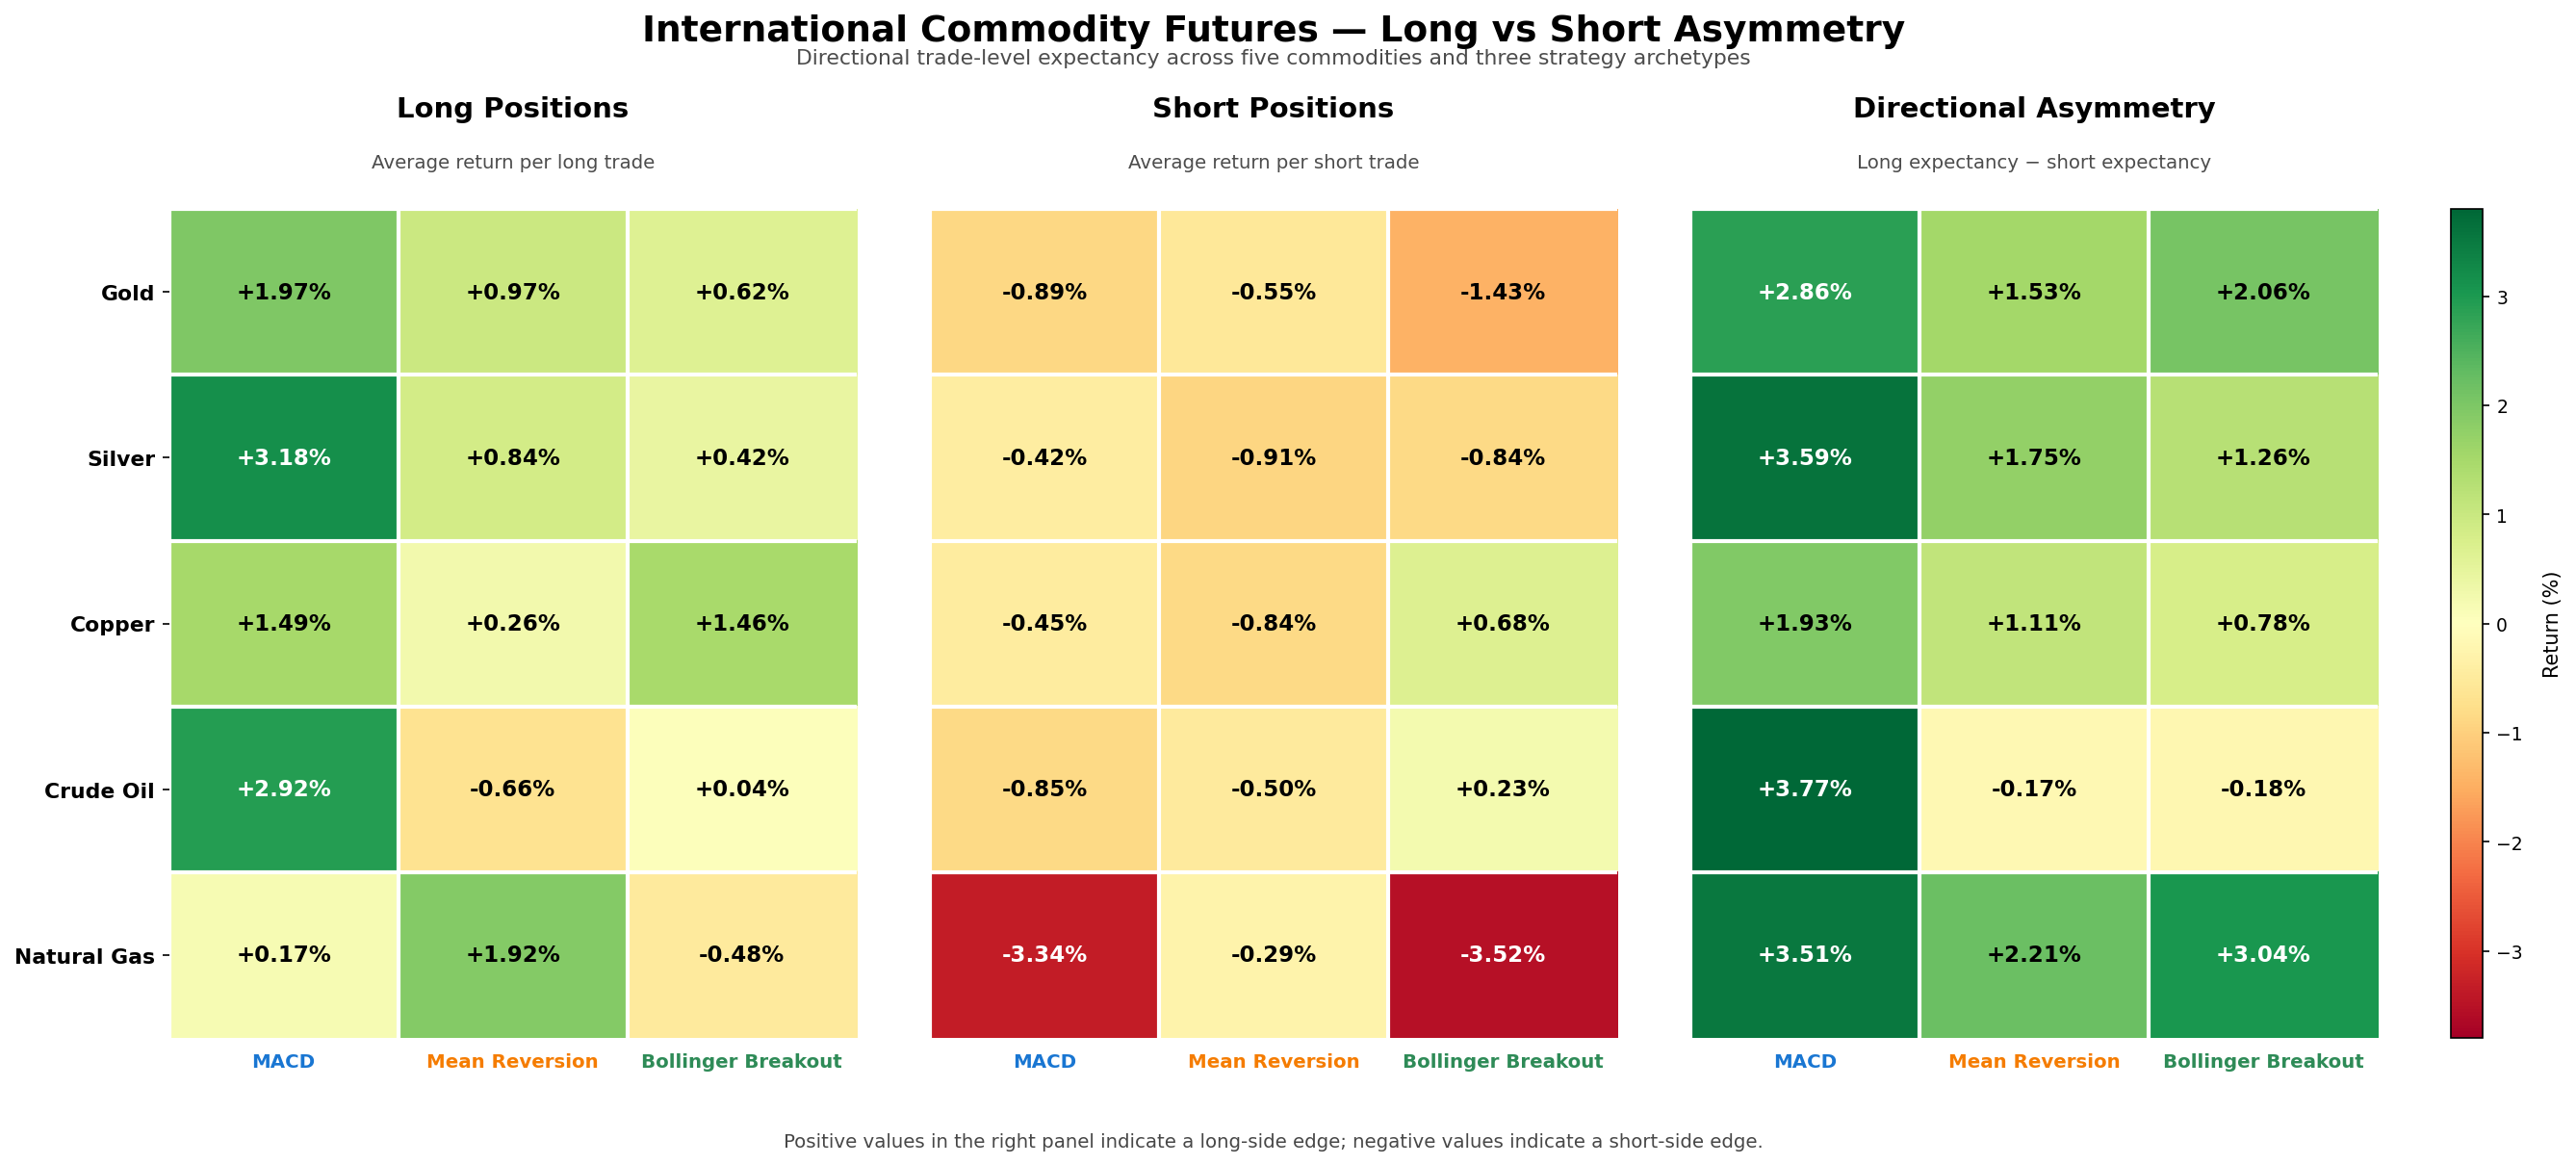

FIGURE 04 — LONG VS SHORT ASYMMETRY

Output:
  PNG: C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_04_Long_vs_Short_Asymmetry.png
  SVG: C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_04_Long_vs_Short_Asymmetry.svg

Structure:
  Panel A: Long-side expectancy
  Panel B: Short-side expectancy
  Panel C: Long − Short expectancy difference
  Commodities: 5
  Strategies: 3
  Total directional cells: 15

Strategy identity colours:
  MACD Trend Following  → Blue
  Mean Reversion        → Orange
  Bollinger Breakout    → Green

Quantitative colour logic:
  Positive expectancy   → Green
  Negative expectancy   → Red
  Zero expectancy       → Neutral
  Common scale across all panels: YES
  Zero-centred scale: YES
  Dedicated colourbar space: YES

Directional asymmetry:
  Maximum Long−Short difference: +3.771%
  Minimum Long−Short difference: -0.183%

Frozen data validation:
  Expected cells: 15
  Actual cells: 15
  Duplicate cells: 0
  Missing 

In [23]:
# ============================================================
# FIGURE 04 — LONG VS SHORT ASYMMETRY
# FINAL PUBLICATION VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec


# ============================================================
# 1. OUTPUT PATHS
# ============================================================

FIGURE_04_PNG = (
    FIGURE_ROOT /
    "Figure_04_Long_vs_Short_Asymmetry.png"
)

FIGURE_04_SVG = (
    FIGURE_ROOT /
    "Figure_04_Long_vs_Short_Asymmetry.svg"
)


# ============================================================
# 2. RESEARCH CONFIGURATION
# ============================================================

STRATEGIES = [
    "MACD Trend Following",
    "Mean Reversion",
    "Bollinger Breakout",
]


STRATEGY_SHORT_NAMES = {
    "MACD Trend Following": "MACD",
    "Mean Reversion": "Mean Reversion",
    "Bollinger Breakout": "Bollinger Breakout",
}


# Strategy identity colours.
# These identify the strategy consistently across figures.
STRATEGY_COLORS = {
    "MACD Trend Following": "#1976D2",
    "Mean Reversion": "#F57C00",
    "Bollinger Breakout": "#2E8B57",
}


COMMODITIES = [
    "GOLD",
    "SILVER",
    "COPPER",
    "CRUDE_OIL",
    "NATURAL_GAS",
]


COMMODITY_DISPLAY = {
    "GOLD": "Gold",
    "SILVER": "Silver",
    "COPPER": "Copper",
    "CRUDE_OIL": "Crude Oil",
    "NATURAL_GAS": "Natural Gas",
}


# ============================================================
# 3. LOAD FROZEN DIRECTIONAL DATA
# ============================================================

directional_df = LONG_SHORT_EDGE.copy()


if directional_df.empty:
    raise ValueError(
        "LONG_SHORT_EDGE is empty."
    )


# ============================================================
# 4. REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Commodity",
    "Strategy",
    "Long Expectancy %",
    "Short Expectancy %",
    "Long Minus Short Expectancy %",
]


missing_columns = [
    column
    for column in required_columns
    if column not in directional_df.columns
]


if missing_columns:
    raise KeyError(
        "Missing required columns in LONG_SHORT_EDGE:\n"
        f"{missing_columns}\n\n"
        f"Available columns:\n"
        f"{directional_df.columns.tolist()}"
    )


# ============================================================
# 5. STANDARDIZE DATA
# ============================================================

data = directional_df[
    required_columns
].copy()


data = data.rename(
    columns={
        "Long Expectancy %": "Long Expectancy",
        "Short Expectancy %": "Short Expectancy",
        "Long Minus Short Expectancy %":
            "Long − Short",
    }
)


data["Commodity"] = (
    data["Commodity"]
    .astype(str)
    .str.strip()
    .str.upper()
)


data["Strategy"] = (
    data["Strategy"]
    .astype(str)
    .str.strip()
)


for column in [
    "Long Expectancy",
    "Short Expectancy",
    "Long − Short",
]:

    data[column] = pd.to_numeric(
        data[column],
        errors="coerce",
    )


# ============================================================
# 6. STRUCTURAL VALIDATION
# ============================================================

expected_cells = (
    len(COMMODITIES)
    * len(STRATEGIES)
)


unique_cells = (
    data[
        ["Commodity", "Strategy"]
    ]
    .drop_duplicates()
)


actual_cells = unique_cells.shape[0]


duplicates = int(
    data[
        ["Commodity", "Strategy"]
    ]
    .duplicated()
    .sum()
)


missing_long = int(
    data["Long Expectancy"]
    .isna()
    .sum()
)


missing_short = int(
    data["Short Expectancy"]
    .isna()
    .sum()
)


missing_difference = int(
    data["Long − Short"]
    .isna()
    .sum()
)


# Validate commodity coverage.
actual_commodities = set(
    data["Commodity"].unique()
)

expected_commodities = set(
    COMMODITIES
)


commodity_coverage_pass = (
    actual_commodities
    == expected_commodities
)


# Validate strategy coverage.
actual_strategies = set(
    data["Strategy"].unique()
)

expected_strategies = set(
    STRATEGIES
)


strategy_coverage_pass = (
    actual_strategies
    == expected_strategies
)


if actual_cells != expected_cells:
    raise ValueError(
        f"Expected {expected_cells} commodity × strategy "
        f"cells, but found {actual_cells}."
    )


if duplicates != 0:
    raise ValueError(
        f"Duplicate commodity × strategy cells detected: "
        f"{duplicates}"
    )


if not commodity_coverage_pass:
    raise ValueError(
        "Commodity coverage mismatch.\n"
        f"Expected: {expected_commodities}\n"
        f"Found: {actual_commodities}"
    )


if not strategy_coverage_pass:
    raise ValueError(
        "Strategy coverage mismatch.\n"
        f"Expected: {expected_strategies}\n"
        f"Found: {actual_strategies}"
    )


if (
    missing_long
    or missing_short
    or missing_difference
):
    raise ValueError(
        "Missing directional expectancy values detected."
    )


# ============================================================
# 7. VALIDATE FROZEN LONG − SHORT CALCULATION
# ============================================================

calculated_difference = (
    data["Long Expectancy"]
    - data["Short Expectancy"]
)


difference_error = float(
    np.max(
        np.abs(
            calculated_difference
            - data["Long − Short"]
        )
    )
)


if difference_error > 1e-10:

    raise ValueError(
        "Frozen Long − Short expectancy column does not "
        "match Long Expectancy − Short Expectancy.\n"
        f"Maximum validation error: {difference_error}"
    )


# ============================================================
# 8. CREATE HEATMAP MATRICES
# ============================================================

long_matrix = (
    data
    .pivot(
        index="Commodity",
        columns="Strategy",
        values="Long Expectancy",
    )
    .reindex(
        index=COMMODITIES,
        columns=STRATEGIES,
    )
)


short_matrix = (
    data
    .pivot(
        index="Commodity",
        columns="Strategy",
        values="Short Expectancy",
    )
    .reindex(
        index=COMMODITIES,
        columns=STRATEGIES,
    )
)


difference_matrix = (
    data
    .pivot(
        index="Commodity",
        columns="Strategy",
        values="Long − Short",
    )
    .reindex(
        index=COMMODITIES,
        columns=STRATEGIES,
    )
)


# ============================================================
# 9. MATRIX COMPLETENESS VALIDATION
# ============================================================

if (
    long_matrix.isna().any().any()
    or short_matrix.isna().any().any()
    or difference_matrix.isna().any().any()
):

    raise ValueError(
        "One or more expected heatmap cells contain NaN."
    )


# ============================================================
# 10. COMMON ZERO-CENTRED COLOUR SCALE
# ============================================================
#
# All three panels use the same quantitative scale.
#
# Positive → green
# Zero     → neutral
# Negative → red
#
# This makes values directly comparable across panels.
# ============================================================

all_values = np.concatenate([
    long_matrix.to_numpy().ravel(),
    short_matrix.to_numpy().ravel(),
    difference_matrix.to_numpy().ravel(),
])


max_abs_value = float(
    np.max(
        np.abs(all_values)
    )
)


# Round upward slightly so the colourbar has clean limits.
scale_limit = (
    np.ceil(
        max_abs_value * 10
    ) / 10
)


norm = TwoSlopeNorm(
    vmin=-scale_limit,
    vcenter=0,
    vmax=scale_limit,
)


# ============================================================
# 11. FIGURE LAYOUT
# ============================================================

fig = plt.figure(
    figsize=(18, 8.2)
)


gs = GridSpec(
    nrows=1,
    ncols=4,
    figure=fig,
    width_ratios=[
        1.00,
        1.00,
        1.00,
        0.045,
    ],
    wspace=0.14,
)


ax_long = fig.add_subplot(
    gs[0, 0]
)


ax_short = fig.add_subplot(
    gs[0, 1],
    sharey=ax_long,
)


ax_difference = fig.add_subplot(
    gs[0, 2],
    sharey=ax_long,
)


# Dedicated colourbar axis.
cbar_ax = fig.add_subplot(
    gs[0, 3]
)


# ============================================================
# 12. HEATMAP FUNCTION
# ============================================================

def draw_heatmap(
    ax,
    matrix,
):

    image = ax.imshow(
        matrix.to_numpy(),
        cmap="RdYlGn",
        norm=norm,
        aspect="auto",
    )


    # --------------------------------------------------------
    # Cell annotations
    # --------------------------------------------------------

    for row_index in range(
        matrix.shape[0]
    ):

        for col_index in range(
            matrix.shape[1]
        ):

            value = float(
                matrix.iloc[
                    row_index,
                    col_index,
                ]
            )


            normalized_strength = (
                abs(value)
                / scale_limit
            )


            # Use white text only on sufficiently strong
            # colours to maintain readability.
            text_color = (
                "white"
                if normalized_strength >= 0.62
                else "black"
            )


            ax.text(
                col_index,
                row_index,
                f"{value:+.2f}%",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color=text_color,
            )


    # --------------------------------------------------------
    # X-axis
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(
            len(STRATEGIES)
        )
    )


    ax.set_xticklabels(
        [
            STRATEGY_SHORT_NAMES[strategy]
            for strategy in STRATEGIES
        ],
        fontsize=9.5,
        fontweight="bold",
    )


    # --------------------------------------------------------
    # Strategy identity colours
    # --------------------------------------------------------

    for tick, strategy in zip(
        ax.get_xticklabels(),
        STRATEGIES,
    ):

        tick.set_color(
            STRATEGY_COLORS[strategy]
        )


    # --------------------------------------------------------
    # Y-axis
    # --------------------------------------------------------

    ax.set_yticks(
        np.arange(
            len(COMMODITIES)
        )
    )


    ax.set_yticklabels(
        [
            COMMODITY_DISPLAY[commodity]
            for commodity in COMMODITIES
        ],
        fontsize=10.5,
        fontweight="bold",
    )


    # --------------------------------------------------------
    # Cell boundaries
    # --------------------------------------------------------

    ax.set_xticks(
        np.arange(
            len(STRATEGIES)
        ) - 0.5,
        minor=True,
    )


    ax.set_yticks(
        np.arange(
            len(COMMODITIES)
        ) - 0.5,
        minor=True,
    )


    ax.grid(
        which="minor",
        color="white",
        linewidth=2,
    )


    # Remove minor tick marks completely.
    ax.tick_params(
        which="minor",
        bottom=False,
        left=False,
    )


    # Remove major x-axis tick marks.
    ax.tick_params(
        axis="x",
        which="major",
        bottom=False,
    )


    # Keep y-axis labels but remove unnecessary right ticks.
    ax.tick_params(
        axis="y",
        which="major",
        left=True,
        right=False,
    )


    # Clean frame.
    for spine in ax.spines.values():
        spine.set_visible(False)


    return image


# ============================================================
# 13. DRAW THE THREE PANELS
# ============================================================

image_long = draw_heatmap(
    ax_long,
    long_matrix,
)


image_short = draw_heatmap(
    ax_short,
    short_matrix,
)


image_difference = draw_heatmap(
    ax_difference,
    difference_matrix,
)


# ============================================================
# 14. PANEL TITLES + SUBTITLES
# ============================================================
#
# Deliberately separated vertically.
#
# Main title
#
# Panel title
#
# Panel subtitle
#
# Heatmap
#
# This avoids the previous title/subtitle collision.
# ============================================================

PANEL_TITLE_Y = 1.105
PANEL_SUBTITLE_Y = 1.045


PANEL_INFORMATION = {

    ax_long: (
        "Long Positions",
        "Average return per long trade",
    ),

    ax_short: (
        "Short Positions",
        "Average return per short trade",
    ),

    ax_difference: (
        "Directional Asymmetry",
        "Long expectancy − short expectancy",
    ),
}


for ax, (
    panel_title,
    panel_subtitle,
) in PANEL_INFORMATION.items():

    ax.text(
        0.5,
        PANEL_TITLE_Y,
        panel_title,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold",
        clip_on=False,
    )


    ax.text(
        0.5,
        PANEL_SUBTITLE_Y,
        panel_subtitle,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=9.5,
        alpha=0.70,
        clip_on=False,
    )


# ============================================================
# 15. REMOVE REDUNDANT Y-AXIS MARKINGS
# ============================================================
#
# Only the first panel carries commodity labels.
# Panels B and C have neither labels nor tick marks.
# ============================================================

ax_short.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
)


ax_difference.tick_params(
    axis="y",
    which="both",
    left=False,
    right=False,
    labelleft=False,
)


# ============================================================
# 16. DEDICATED COLOURBAR
# ============================================================

colorbar = fig.colorbar(
    image_difference,
    cax=cbar_ax,
)


colorbar.set_label(
    "Return (%)",
    fontsize=10,
    labelpad=10,
)


# ============================================================
# 17. MAIN FIGURE TITLE
# ============================================================

fig.suptitle(
    "International Commodity Futures — Long vs Short Asymmetry",
    fontsize=18,
    fontweight="bold",
    y=0.985,
)


# ============================================================
# 18. MAIN FIGURE SUBTITLE
# ============================================================

fig.text(
    0.5,
    0.948,
    (
        "Directional trade-level expectancy across five "
        "commodities and three strategy archetypes"
    ),
    ha="center",
    va="center",
    fontsize=10.5,
    alpha=0.70,
)


# ============================================================
# 19. INTERPRETATION NOTE
# ============================================================

fig.text(
    0.5,
    0.025,
    (
        "Positive values in the right panel indicate a "
        "long-side edge; negative values indicate a "
        "short-side edge."
    ),
    ha="center",
    va="bottom",
    fontsize=9.5,
    alpha=0.72,
)


# ============================================================
# 20. FINAL LAYOUT
# ============================================================
#
# Extra top space is reserved for:
#
#   Main title
#   Main subtitle
#   Panel titles
#   Panel subtitles
#
# ============================================================

fig.subplots_adjust(
    left=0.075,
    right=0.965,
    bottom=0.12,
    top=0.82,
)


# ============================================================
# 21. SAVE PNG
# ============================================================

fig.savefig(
    FIGURE_04_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)


# ============================================================
# 22. SAVE SVG
# ============================================================

fig.savefig(
    FIGURE_04_SVG,
    bbox_inches="tight",
    facecolor="white",
)


# ============================================================
# 23. DISPLAY
# ============================================================

plt.show()


# ============================================================
# 24. AUDIT OUTPUT
# ============================================================

print("=" * 72)
print("FIGURE 04 — LONG VS SHORT ASYMMETRY")
print("=" * 72)


print("\nOutput:")
print(
    f"  PNG: {FIGURE_04_PNG}"
)

print(
    f"  SVG: {FIGURE_04_SVG}"
)


print("\nStructure:")
print("  Panel A: Long-side expectancy")
print("  Panel B: Short-side expectancy")
print("  Panel C: Long − Short expectancy difference")
print("  Commodities: 5")
print("  Strategies: 3")
print("  Total directional cells: 15")


print("\nStrategy identity colours:")
print("  MACD Trend Following  → Blue")
print("  Mean Reversion        → Orange")
print("  Bollinger Breakout    → Green")


print("\nQuantitative colour logic:")
print("  Positive expectancy   → Green")
print("  Negative expectancy   → Red")
print("  Zero expectancy       → Neutral")
print("  Common scale across all panels: YES")
print("  Zero-centred scale: YES")
print("  Dedicated colourbar space: YES")


print("\nDirectional asymmetry:")

print(
    f"  Maximum Long−Short difference: "
    f"{difference_matrix.to_numpy().max():+.3f}%"
)

print(
    f"  Minimum Long−Short difference: "
    f"{difference_matrix.to_numpy().min():+.3f}%"
)


print("\nFrozen data validation:")

print(
    f"  Expected cells: "
    f"{expected_cells}"
)

print(
    f"  Actual cells: "
    f"{actual_cells}"
)

print(
    f"  Duplicate cells: "
    f"{duplicates}"
)

print(
    f"  Missing long expectancy: "
    f"{missing_long}"
)

print(
    f"  Missing short expectancy: "
    f"{missing_short}"
)

print(
    f"  Missing Long−Short values: "
    f"{missing_difference}"
)

print(
    f"  Maximum frozen difference validation error: "
    f"{difference_error:.12f}%"
)


print("\nData integrity:")
print("  Source: Frozen LONG_SHORT_EDGE")
print("  Strategy rerun: NO")
print("  Optimization: NO")
print("  Trade data modified: NO")
print("  Return capping: NO")
print("  Winsorization: NO")
print("  Transaction costs added: NO")
print("  Research methodology changed: NO")


print("\nValidation:")

print(
    f"  Commodity coverage: "
    f"{'PASS' if commodity_coverage_pass else 'FAIL'}"
)

print(
    f"  Strategy coverage: "
    f"{'PASS' if strategy_coverage_pass else 'FAIL'}"
)

print(
    f"  Directional cells: "
    f"{'PASS' if actual_cells == expected_cells else 'FAIL'}"
)

print(
    f"  Missing values: "
    f"{'PASS' if (missing_long + missing_short + missing_difference) == 0 else 'FAIL'}"
)

print(
    f"  Duplicate cells: "
    f"{'PASS' if duplicates == 0 else 'FAIL'}"
)

print(
    f"  Long−Short calculation: "
    f"{'PASS' if difference_error <= 1e-10 else 'FAIL'}"
)


print("\n🟢 FIGURE 04 COMPLETE")

Available columns in REGIME_PERIOD:
['Period', 'Commodity', 'Strategy', 'Trade Count', 'Win Rate %', 'Mean %', 'Median %', 'Avg Winner %', 'Avg Loser %', 'Payoff Ratio', 'Profit Factor', 'Std Dev %', 'Skewness', 'Excess Kurtosis', 'Avg Holding Days', 'Median Holding Days', 'Best Trade %', 'Worst Trade %']


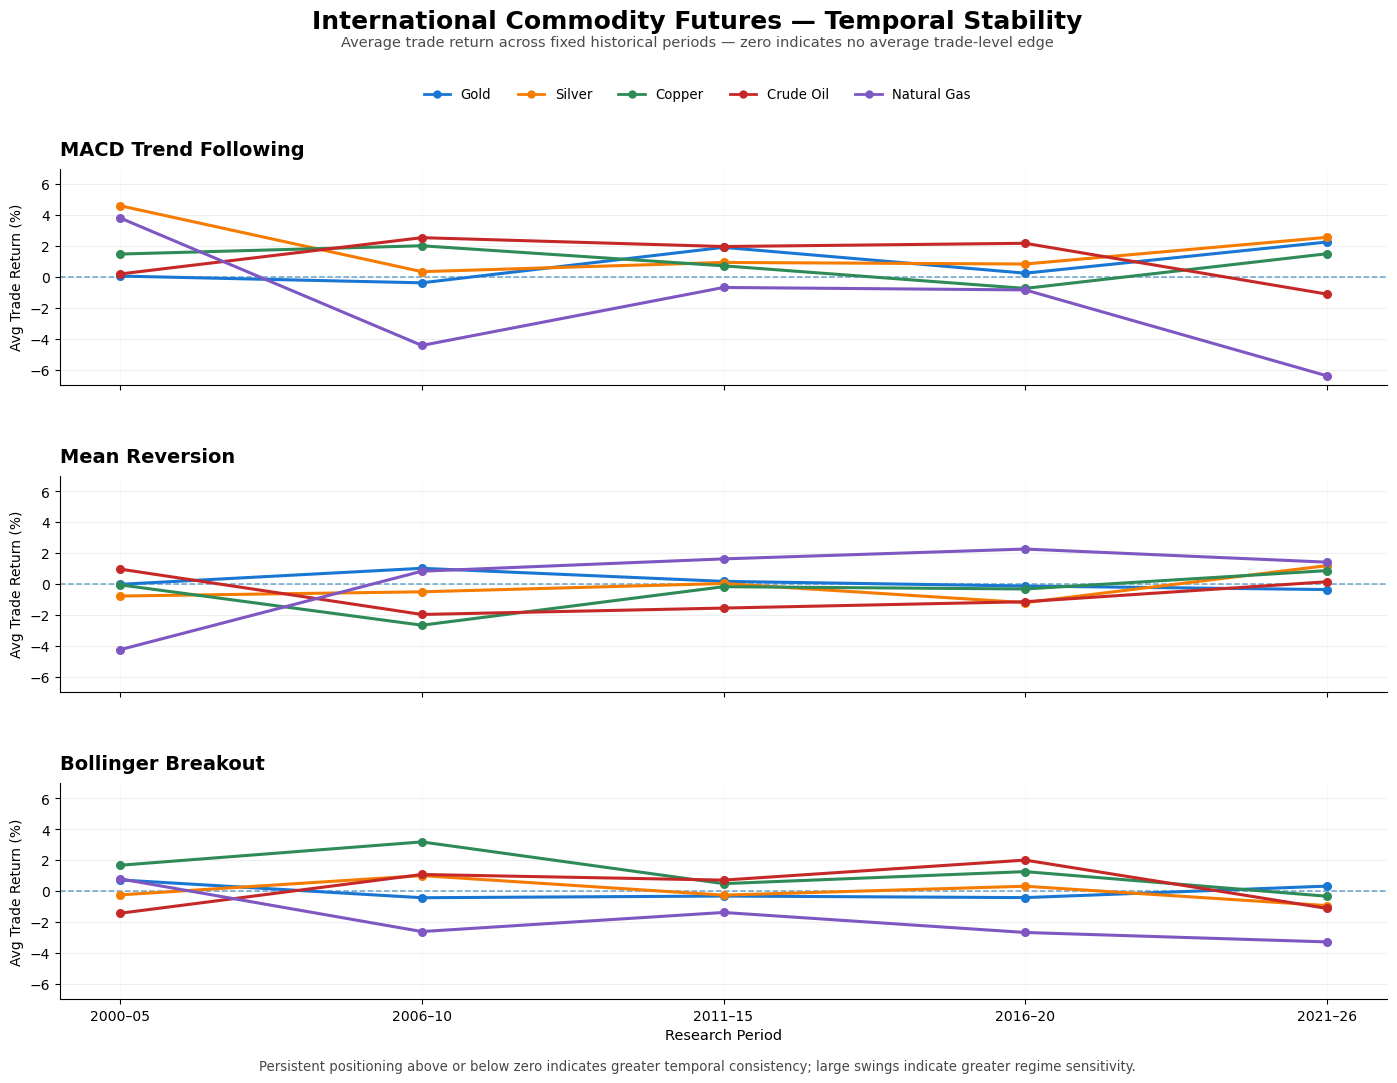

FIGURE 05 — TEMPORAL STABILITY

Output:
  PNG: C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_05_Temporal_Stability.png
  SVG: C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_05_Temporal_Stability.svg

Structure:
  Panel A: MACD Trend Following
  Panel B: Mean Reversion
  Panel C: Bollinger Breakout
  Commodities per panel: 5
  Historical periods: 5
  Expected observations: 75
  Actual observations: 75

Historical periods:
  2000–05 | 2006–10 | 2011–15 | 2016–20 | 2021–26

Commodity identity colours:
  Gold         → Blue
  Silver       → Orange
  Copper       → Green
  Crude Oil    → Red
  Natural Gas  → Purple

Quantitative visual logic:
  Y-axis: Average trade return (%)
  Zero line: No average trade-level edge
  Common Y-axis across all panels: YES
  Chronological ordering: YES
  Frozen temporal statistics recalculated: NO

Frozen data validation:
  Commodity coverage: PASS
  Strategy coverage: PASS
  Period coverage: PASS
  Duplic

In [3]:
# ============================================================
# FIGURE 05 — TEMPORAL STABILITY
# FINAL PUBLICATION VERSION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path


# ============================================================
# 1. ROBUST PATH SETUP
# ============================================================
#
# This makes the block safe if JupyterLab was restarted.
# No research data is downloaded or recalculated.
# ============================================================

RESEARCH_ROOT = Path(
    r"C:\Users\navon\commodity_strategy_research"
)

FIGURE_ROOT = (
    RESEARCH_ROOT
    / "visualizations"
    / "figures"
)

FIGURE_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


FIGURE_05_PNG = (
    FIGURE_ROOT
    / "Figure_05_Temporal_Stability.png"
)

FIGURE_05_SVG = (
    FIGURE_ROOT
    / "Figure_05_Temporal_Stability.svg"
)


# ============================================================
# 2. VERIFY FROZEN DATASET IS AVAILABLE
# ============================================================

if "REGIME_PERIOD" not in globals():

    raise NameError(
        "REGIME_PERIOD is not loaded in the current kernel.\n\n"
        "Please run Visualization Notebook Block 1 first.\n"
        "That block loads the frozen research datasets."
    )


temporal_df = REGIME_PERIOD.copy()


if temporal_df.empty:

    raise ValueError(
        "REGIME_PERIOD is empty."
    )


print(
    "Available columns in REGIME_PERIOD:"
)

print(
    temporal_df.columns.tolist()
)


# ============================================================
# 3. CONFIGURATION
# ============================================================

STRATEGIES = [
    "MACD Trend Following",
    "Mean Reversion",
    "Bollinger Breakout",
]


COMMODITIES = [
    "GOLD",
    "SILVER",
    "COPPER",
    "CRUDE_OIL",
    "NATURAL_GAS",
]


COMMODITY_DISPLAY = {
    "GOLD": "Gold",
    "SILVER": "Silver",
    "COPPER": "Copper",
    "CRUDE_OIL": "Crude Oil",
    "NATURAL_GAS": "Natural Gas",
}


# ------------------------------------------------------------
# Commodity identity colours
# ------------------------------------------------------------

COMMODITY_COLORS = {
    "GOLD": "#1976D2",
    "SILVER": "#F57C00",
    "COPPER": "#2E8B57",
    "CRUDE_OIL": "#C62828",
    "NATURAL_GAS": "#7E57C2",
}


# ------------------------------------------------------------
# Fixed research periods
# ------------------------------------------------------------

PERIOD_ORDER = [
    "2000-2005",
    "2006-2010",
    "2011-2015",
    "2016-2020",
    "2021-2026",
]


PERIOD_LABELS = [
    "2000–05",
    "2006–10",
    "2011–15",
    "2016–20",
    "2021–26",
]


# ============================================================
# 4. COLUMN IDENTIFICATION
# ============================================================

def find_column(
    df,
    candidates,
    description,
):

    lower_map = {
        str(column).strip().lower(): column
        for column in df.columns
    }


    for candidate in candidates:

        key = (
            str(candidate)
            .strip()
            .lower()
        )

        if key in lower_map:

            return lower_map[key]


    raise KeyError(
        f"Could not identify {description}.\n\n"
        f"Available columns:\n"
        f"{df.columns.tolist()}"
    )


commodity_col = find_column(
    temporal_df,
    [
        "Commodity",
    ],
    "commodity column",
)


strategy_col = find_column(
    temporal_df,
    [
        "Strategy",
    ],
    "strategy column",
)


period_col = find_column(
    temporal_df,
    [
        "Period",
        "Regime Period",
        "Time Period",
        "Period Label",
    ],
    "period column",
)


expectancy_col = find_column(
    temporal_df,
    [
        "Expectancy %",
        "Average Trade Return %",
        "Avg Return %",
        "Mean Return %",
        "Mean %",
        "Expectancy",
    ],
    "temporal expectancy column",
)


# ============================================================
# 5. STANDARDIZE DATA
# ============================================================

data = temporal_df[
    [
        commodity_col,
        strategy_col,
        period_col,
        expectancy_col,
    ]
].copy()


data.columns = [
    "Commodity",
    "Strategy",
    "Period",
    "Expectancy",
]


data["Commodity"] = (
    data["Commodity"]
    .astype(str)
    .str.strip()
    .str.upper()
)


data["Strategy"] = (
    data["Strategy"]
    .astype(str)
    .str.strip()
)


data["Period"] = (
    data["Period"]
    .astype(str)
    .str.strip()
)


data["Expectancy"] = pd.to_numeric(
    data["Expectancy"],
    errors="coerce",
)


# ============================================================
# 6. STANDARDIZE PERIOD LABELS
# ============================================================

period_mapping = {

    "2000-2005": "2000-2005",
    "2000–2005": "2000-2005",
    "2000 - 2005": "2000-2005",
    "2000–05": "2000-2005",
    "2000-05": "2000-2005",

    "2006-2010": "2006-2010",
    "2006–2010": "2006-2010",
    "2006 - 2010": "2006-2010",
    "2006–10": "2006-2010",
    "2006-10": "2006-2010",

    "2011-2015": "2011-2015",
    "2011–2015": "2011-2015",
    "2011 - 2015": "2011-2015",
    "2011–15": "2011-2015",
    "2011-15": "2011-2015",

    "2016-2020": "2016-2020",
    "2016–2020": "2016-2020",
    "2016 - 2020": "2016-2020",
    "2016–20": "2016-2020",
    "2016-20": "2016-2020",

    "2021-2026": "2021-2026",
    "2021–2026": "2021-2026",
    "2021 - 2026": "2021-2026",
    "2021–26": "2021-2026",
    "2021-26": "2021-2026",
}


data["Period"] = (
    data["Period"]
    .map(period_mapping)
    .fillna(data["Period"])
)


# ============================================================
# 7. VALIDATION
# ============================================================

expected_observations = (
    len(COMMODITIES)
    * len(STRATEGIES)
    * len(PERIOD_ORDER)
)


actual_commodities = set(
    data["Commodity"].unique()
)


actual_strategies = set(
    data["Strategy"].unique()
)


actual_periods = set(
    data["Period"].unique()
)


commodity_coverage_pass = (
    actual_commodities
    == set(COMMODITIES)
)


strategy_coverage_pass = (
    actual_strategies
    == set(STRATEGIES)
)


period_coverage_pass = (
    actual_periods
    == set(PERIOD_ORDER)
)


duplicate_cells = int(
    data[
        [
            "Commodity",
            "Strategy",
            "Period",
        ]
    ]
    .duplicated()
    .sum()
)


missing_expectancy = int(
    data["Expectancy"]
    .isna()
    .sum()
)


actual_observations = (
    data[
        [
            "Commodity",
            "Strategy",
            "Period",
        ]
    ]
    .drop_duplicates()
    .shape[0]
)


if not commodity_coverage_pass:

    raise ValueError(
        f"Commodity coverage mismatch.\n"
        f"Expected: {set(COMMODITIES)}\n"
        f"Found: {actual_commodities}"
    )


if not strategy_coverage_pass:

    raise ValueError(
        f"Strategy coverage mismatch.\n"
        f"Expected: {set(STRATEGIES)}\n"
        f"Found: {actual_strategies}"
    )


if not period_coverage_pass:

    raise ValueError(
        f"Period coverage mismatch.\n"
        f"Expected: {set(PERIOD_ORDER)}\n"
        f"Found: {actual_periods}"
    )


if duplicate_cells != 0:

    raise ValueError(
        f"Duplicate temporal cells detected: "
        f"{duplicate_cells}"
    )


if missing_expectancy != 0:

    raise ValueError(
        f"Missing expectancy values detected: "
        f"{missing_expectancy}"
    )


if actual_observations != expected_observations:

    raise ValueError(
        f"Expected {expected_observations} observations, "
        f"found {actual_observations}."
    )


# ============================================================
# 8. ORDER DATA
# ============================================================

data["Period"] = pd.Categorical(
    data["Period"],
    categories=PERIOD_ORDER,
    ordered=True,
)


data = data.sort_values(
    [
        "Strategy",
        "Commodity",
        "Period",
    ]
)


# ============================================================
# 9. COMMON Y-AXIS
# ============================================================
#
# Same scale across all three strategy panels.
# This prevents visual exaggeration of differences.
# ============================================================

max_abs_expectancy = float(
    np.max(
        np.abs(
            data["Expectancy"].to_numpy()
        )
    )
)


y_limit = (
    np.ceil(
        max_abs_expectancy * 10
    )
    / 10
)


y_limit = max(
    y_limit + 0.5,
    5.0,
)


# ============================================================
# 10. CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 11),
    sharex=True,
    sharey=True,
)


# ============================================================
# 11. DRAW STRATEGY PANELS
# ============================================================

for ax, strategy in zip(
    axes,
    STRATEGIES,
):

    strategy_data = data[
        data["Strategy"] == strategy
    ].copy()


    # --------------------------------------------------------
    # Zero-return reference
    # --------------------------------------------------------

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1.1,
        alpha=0.65,
    )


    # --------------------------------------------------------
    # Plot commodities
    # --------------------------------------------------------

    for commodity in COMMODITIES:

        commodity_data = (
            strategy_data[
                strategy_data["Commodity"]
                == commodity
            ]
            .sort_values("Period")
        )


        x = np.arange(
            len(PERIOD_ORDER)
        )


        y = (
            commodity_data["Expectancy"]
            .to_numpy()
        )


        ax.plot(
            x,
            y,
            color=COMMODITY_COLORS[
                commodity
            ],
            linewidth=2.2,
            marker="o",
            markersize=5.5,
            label=COMMODITY_DISPLAY[
                commodity
            ],
        )


    # --------------------------------------------------------
    # Strategy title
    # --------------------------------------------------------

    ax.set_title(
        strategy,
        fontsize=14,
        fontweight="bold",
        loc="left",
        pad=10,
    )


    # --------------------------------------------------------
    # Y-axis
    # --------------------------------------------------------

    ax.set_ylim(
        -y_limit,
        y_limit,
    )


    ax.set_ylabel(
        "Avg Trade Return (%)",
        fontsize=10,
    )


    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(
        axis="y",
        alpha=0.20,
        linewidth=0.8,
    )


    ax.grid(
        axis="x",
        alpha=0.08,
        linewidth=0.7,
    )


    # --------------------------------------------------------
    # Clean frame
    # --------------------------------------------------------

    ax.spines[
        "top"
    ].set_visible(False)


    ax.spines[
        "right"
    ].set_visible(False)


# ============================================================
# 12. X-AXIS
# ============================================================

axes[-1].set_xticks(
    np.arange(
        len(PERIOD_ORDER)
    )
)


axes[-1].set_xticklabels(
    PERIOD_LABELS,
    fontsize=10,
)


axes[-1].set_xlabel(
    "Research Period",
    fontsize=10.5,
)


# ============================================================
# 13. COMMON LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        color=COMMODITY_COLORS[
            commodity
        ],
        marker="o",
        linewidth=2,
        markersize=5,
        label=COMMODITY_DISPLAY[
            commodity
        ],
    )

    for commodity in COMMODITIES

]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        0.925,
    ),
    ncol=5,
    frameon=False,
    fontsize=9.5,
)


# ============================================================
# 14. TITLE
# ============================================================

fig.suptitle(
    "International Commodity Futures — Temporal Stability",
    fontsize=18,
    fontweight="bold",
    y=0.985,
)


fig.text(
    0.5,
    0.955,
    (
        "Average trade return across fixed historical "
        "periods — zero indicates no average trade-level edge"
    ),
    ha="center",
    va="center",
    fontsize=10.5,
    alpha=0.70,
)


# ============================================================
# 15. FOOTNOTE
# ============================================================

fig.text(
    0.5,
    0.018,
    (
        "Persistent positioning above or below zero indicates "
        "greater temporal consistency; large swings indicate "
        "greater regime sensitivity."
    ),
    ha="center",
    va="bottom",
    fontsize=9.5,
    alpha=0.72,
)


# ============================================================
# 16. FINAL SPACING
# ============================================================

fig.subplots_adjust(
    left=0.075,
    right=0.96,
    bottom=0.085,
    top=0.84,
    hspace=0.42,
)


# ============================================================
# 17. SAVE PNG
# ============================================================

fig.savefig(
    FIGURE_05_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)


# ============================================================
# 18. SAVE SVG
# ============================================================

fig.savefig(
    FIGURE_05_SVG,
    bbox_inches="tight",
    facecolor="white",
)


# ============================================================
# 19. DISPLAY
# ============================================================

plt.show()


# ============================================================
# 20. AUDIT OUTPUT
# ============================================================

print("=" * 72)
print("FIGURE 05 — TEMPORAL STABILITY")
print("=" * 72)


print("\nOutput:")
print(
    f"  PNG: {FIGURE_05_PNG}"
)

print(
    f"  SVG: {FIGURE_05_SVG}"
)


print("\nStructure:")
print(
    "  Panel A: MACD Trend Following"
)

print(
    "  Panel B: Mean Reversion"
)

print(
    "  Panel C: Bollinger Breakout"
)

print(
    "  Commodities per panel: 5"
)

print(
    "  Historical periods: 5"
)

print(
    f"  Expected observations: "
    f"{expected_observations}"
)

print(
    f"  Actual observations: "
    f"{actual_observations}"
)


print("\nHistorical periods:")
print(
    "  2000–05 | 2006–10 | 2011–15 | "
    "2016–20 | 2021–26"
)


print("\nCommodity identity colours:")
print("  Gold         → Blue")
print("  Silver       → Orange")
print("  Copper       → Green")
print("  Crude Oil    → Red")
print("  Natural Gas  → Purple")


print("\nQuantitative visual logic:")
print(
    "  Y-axis: Average trade return (%)"
)

print(
    "  Zero line: No average trade-level edge"
)

print(
    "  Common Y-axis across all panels: YES"
)

print(
    "  Chronological ordering: YES"
)

print(
    "  Frozen temporal statistics recalculated: NO"
)


print("\nFrozen data validation:")

print(
    f"  Commodity coverage: "
    f"{'PASS' if commodity_coverage_pass else 'FAIL'}"
)

print(
    f"  Strategy coverage: "
    f"{'PASS' if strategy_coverage_pass else 'FAIL'}"
)

print(
    f"  Period coverage: "
    f"{'PASS' if period_coverage_pass else 'FAIL'}"
)

print(
    f"  Duplicate cells: "
    f"{duplicate_cells}"
)

print(
    f"  Missing expectancy: "
    f"{missing_expectancy}"
)


print("\nData integrity:")
print(
    "  Source: Frozen REGIME_PERIOD"
)

print(
    "  Strategy rerun: NO"
)

print(
    "  Optimization: NO"
)

print(
    "  Trade data modified: NO"
)

print(
    "  Temporal statistics modified: NO"
)

print(
    "  Return capping: NO"
)

print(
    "  Winsorization: NO"
)

print(
    "  Transaction costs added: NO"
)

print(
    "  Research methodology changed: NO"
)


# ============================================================
# 21. FINAL STATUS
# ============================================================

all_validation_pass = all([
    commodity_coverage_pass,
    strategy_coverage_pass,
    period_coverage_pass,
    actual_observations == expected_observations,
    duplicate_cells == 0,
    missing_expectancy == 0,
])


print("\nValidation:")

print(
    f"  Overall validation: "
    f"{'PASS' if all_validation_pass else 'FAIL'}"
)


if all_validation_pass:

    print(
        "\n🟢 FIGURE 05 READY FOR VISUAL REVIEW"
    )

else:

    print(
        "\n🔴 FIGURE 05 VALIDATION FAILED"
    )

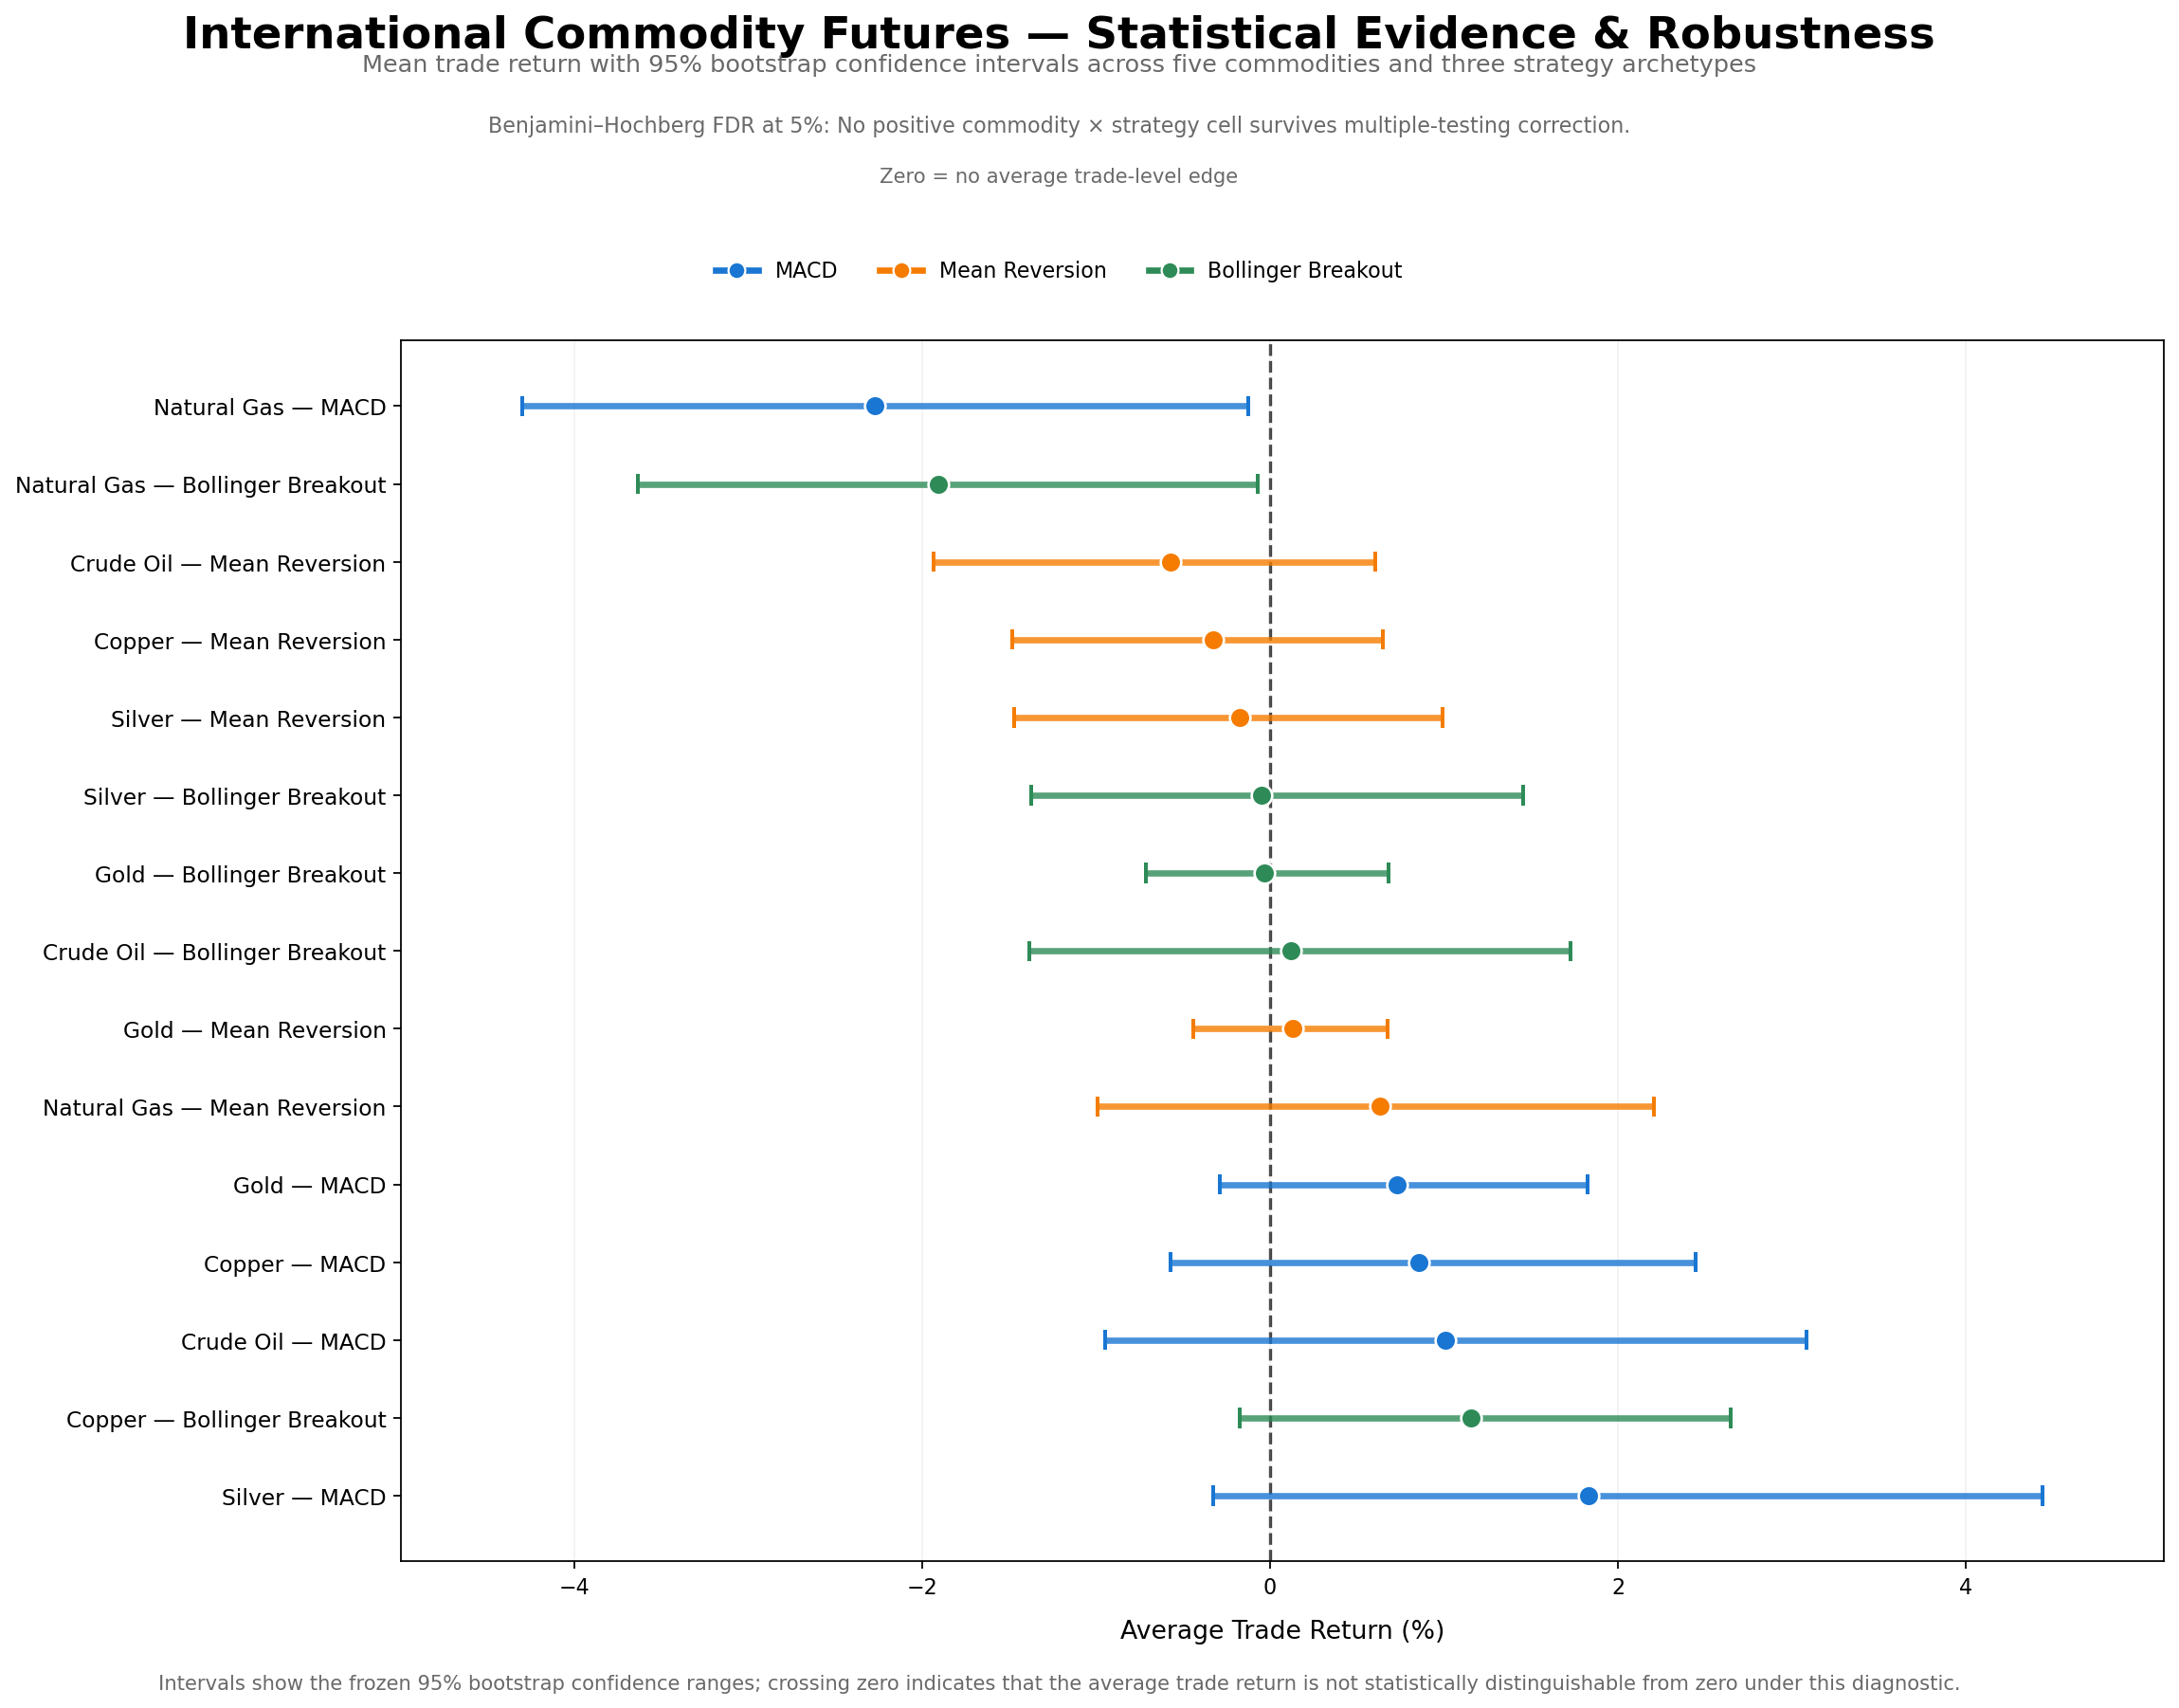


FIGURE 07 — STATISTICAL EVIDENCE & ROBUSTNESS

Output:
  PNG: C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_07_Statistical_Evidence_Robustness.png
  SVG: C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_07_Statistical_Evidence_Robustness.svg

Structure:
  Commodity × strategy cells: 15
  Visual: Mean return + 95% bootstrap confidence interval
  Reference: Zero average trade-level return
  Bootstrap iterations: 10,000

Strategy identity colours:
  MACD Trend Following  → Blue
  Mean Reversion        → Orange
  Bollinger Breakout    → Green

Statistical evidence:
  FDR-significant cells at 5%: 0
  Positive FDR-significant cells: 0
  Negative FDR-significant cells: 0
  Mean outside bootstrap interval: 0

Frozen data validation:
  Expected cells: 15
  Actual cells: 15
  Duplicate cells: 0
  Missing statistical values: 0
  Invalid bootstrap intervals: 0

Data integrity:
  Source: Frozen statistical_significance_15_cells
  Strategy rerun: N

In [10]:
# ============================================================
# FIGURE 07 — STATISTICAL EVIDENCE & ROBUSTNESS
# ============================================================
#
# Uses ONLY the frozen statistical_significance_15_cells.csv
#
# No strategy rerun
# No optimization
# No modification of trade data
# No recalculation of research statistics
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D


# ============================================================
# 1. OUTPUT PATH
# ============================================================

if "FIGURE_ROOT" not in globals():

    if "ROOT" in globals():
        FIGURE_ROOT = ROOT / "visualizations" / "figures"

    else:
        FIGURE_ROOT = (
            Path(
                r"C:\Users\navon\commodity_strategy_research"
            )
            / "visualizations"
            / "figures"
        )

FIGURE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_07_PNG = (
    FIGURE_ROOT
    / "Figure_07_Statistical_Evidence_Robustness.png"
)

FIGURE_07_SVG = (
    FIGURE_ROOT
    / "Figure_07_Statistical_Evidence_Robustness.svg"
)


# ============================================================
# 2. LOAD FROZEN STATISTICAL DATA
# ============================================================

if "DATASETS" in globals():

    statistical_df = None

    possible_keys = [
        "statistics/statistical_significance_15_cells.csv",
        "statistical_significance_15_cells.csv",
    ]

    for key in possible_keys:

        if key in DATASETS:
            statistical_df = DATASETS[key].copy()
            break

    if statistical_df is None:
        raise KeyError(
            "Frozen statistical significance dataset "
            "was not found in DATASETS."
        )

elif "STATISTICAL_SIGNIFICANCE_15_CELLS" in globals():

    statistical_df = (
        STATISTICAL_SIGNIFICANCE_15_CELLS.copy()
    )

else:

    raise NameError(
        "DATASETS or STATISTICAL_SIGNIFICANCE_15_CELLS "
        "is not available. Run the visualization "
        "data-access block first."
    )


# ============================================================
# 3. REQUIRED FROZEN SCHEMA
# ============================================================

EXPECTED_COLUMNS = [
    "Commodity",
    "Strategy",
    "Trade Count",
    "Mean %",
    "Median %",
    "Std Dev %",
    "Std Error %",
    "T Statistic",
    "P Value",
    "CI Lower %",
    "CI Upper %",
    "Probability Return > 0 %",
    "Bootstrap Mean %",
    "Bootstrap CI Lower %",
    "Bootstrap CI Upper %",
    "Bootstrap Probability Mean > 0 %",
    "Trimmed Mean 5-95 %",
    "Trimmed Mean 10-90 %",
    "Mean Without Best Trade %",
    "Mean Without Worst Trade %",
    "Mean Without Best & Worst %",
    "BH Adjusted P Value",
    "Significant 5% Raw",
    "Significant 5% FDR",
    "Evidence Classification",
]

missing_columns = [
    col
    for col in EXPECTED_COLUMNS
    if col not in statistical_df.columns
]

if missing_columns:

    raise KeyError(
        "Frozen statistical dataset is missing:\n"
        + "\n".join(
            f"  - {col}"
            for col in missing_columns
        )
    )


# ============================================================
# 4. STANDARDIZE VISUALIZATION DATA
# ============================================================

df = statistical_df[
    [
        "Commodity",
        "Strategy",
        "Mean %",
        "Trade Count",
        "Bootstrap CI Lower %",
        "Bootstrap CI Upper %",
        "P Value",
        "BH Adjusted P Value",
        "Bootstrap Probability Mean > 0 %",
    ]
].copy()

df.columns = [
    "Commodity",
    "Strategy",
    "Mean",
    "N",
    "Bootstrap_Lower",
    "Bootstrap_Upper",
    "P_Value",
    "FDR_Q",
    "Prob_Positive",
]


# ============================================================
# 5. NUMERIC VALIDATION
# ============================================================

numeric_columns = [
    "Mean",
    "N",
    "Bootstrap_Lower",
    "Bootstrap_Upper",
    "P_Value",
    "FDR_Q",
    "Prob_Positive",
]

for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce",
    )

df["Commodity"] = (
    df["Commodity"]
    .astype(str)
    .str.strip()
)

df["Strategy"] = (
    df["Strategy"]
    .astype(str)
    .str.strip()
)


# ============================================================
# 6. EXPECTED UNIVERSE
# ============================================================

EXPECTED_COMMODITIES = [
    "GOLD",
    "SILVER",
    "COPPER",
    "CRUDE_OIL",
    "NATURAL_GAS",
]

EXPECTED_STRATEGIES = [
    "MACD Trend Following",
    "Mean Reversion",
    "Bollinger Breakout",
]

COMMODITY_DISPLAY = {
    "GOLD": "Gold",
    "SILVER": "Silver",
    "COPPER": "Copper",
    "CRUDE_OIL": "Crude Oil",
    "NATURAL_GAS": "Natural Gas",
}

STRATEGY_SHORT = {
    "MACD Trend Following": "MACD",
    "Mean Reversion": "Mean Reversion",
    "Bollinger Breakout": "Bollinger Breakout",
}

STRATEGY_COLORS = {
    "MACD Trend Following": "#1976D2",
    "Mean Reversion": "#F57C00",
    "Bollinger Breakout": "#2E8B57",
}


# ============================================================
# 7. FROZEN DATA VALIDATION
# ============================================================

EXPECTED_CELLS = (
    len(EXPECTED_COMMODITIES)
    *
    len(EXPECTED_STRATEGIES)
)

ACTUAL_CELLS = len(df)

if ACTUAL_CELLS != EXPECTED_CELLS:

    raise ValueError(
        f"Expected {EXPECTED_CELLS} cells "
        f"but found {ACTUAL_CELLS}."
    )

if set(df["Commodity"]) != set(
    EXPECTED_COMMODITIES
):

    raise ValueError(
        "Commodity coverage does not match "
        "the frozen universe."
    )

if set(df["Strategy"]) != set(
    EXPECTED_STRATEGIES
):

    raise ValueError(
        "Strategy coverage does not match "
        "the frozen universe."
    )

duplicate_cells = int(
    df.duplicated(
        subset=[
            "Commodity",
            "Strategy",
        ]
    ).sum()
)

if duplicate_cells != 0:

    raise ValueError(
        f"Duplicate commodity × strategy cells: "
        f"{duplicate_cells}"
    )

missing_values = int(
    df[
        [
            "Mean",
            "N",
            "Bootstrap_Lower",
            "Bootstrap_Upper",
            "P_Value",
            "FDR_Q",
            "Prob_Positive",
        ]
    ]
    .isna()
    .sum()
    .sum()
)

if missing_values != 0:

    raise ValueError(
        f"Missing statistical values detected: "
        f"{missing_values}"
    )


# ============================================================
# 8. BOOTSTRAP INTERVAL VALIDATION
# ============================================================

invalid_intervals = int(
    (
        df["Bootstrap_Lower"]
        >
        df["Bootstrap_Upper"]
    ).sum()
)

if invalid_intervals != 0:

    raise ValueError(
        f"Invalid bootstrap confidence intervals: "
        f"{invalid_intervals}"
    )

mean_outside_ci = int(
    (
        (df["Mean"] < df["Bootstrap_Lower"])
        |
        (df["Mean"] > df["Bootstrap_Upper"])
    ).sum()
)


# ============================================================
# 9. FDR VALIDATION
# ============================================================

FDR_ALPHA = 0.05

fdr_significant = (
    df["FDR_Q"] < FDR_ALPHA
)

fdr_significant_count = int(
    fdr_significant.sum()
)

positive_fdr_significant = int(
    (
        fdr_significant
        &
        (df["Mean"] > 0)
    ).sum()
)

negative_fdr_significant = int(
    (
        fdr_significant
        &
        (df["Mean"] < 0)
    ).sum()
)


# ============================================================
# 10. SORT FOR DISPLAY
# ============================================================

df_plot = (
    df
    .sort_values(
        by=[
            "Mean",
            "Commodity",
            "Strategy",
        ],
        ascending=[
            True,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

df_plot["Label"] = [
    f"{COMMODITY_DISPLAY[c]} — "
    f"{STRATEGY_SHORT[s]}"
    for c, s
    in zip(
        df_plot["Commodity"],
        df_plot["Strategy"],
    )
]


# ============================================================
# 11. FIGURE
# ============================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, ax = plt.subplots(
    figsize=(15.5, 11.5),
    dpi=160,
)


# ============================================================
# 12. Y POSITIONS
# ============================================================

y_positions = np.arange(
    len(df_plot)
)


# ============================================================
# 13. FOREST PLOT
# ============================================================

for y, (_, row) in zip(
    y_positions,
    df_plot.iterrows(),
):

    strategy = row["Strategy"]

    mean_value = row["Mean"]
    lower = row["Bootstrap_Lower"]
    upper = row["Bootstrap_Upper"]

    strategy_color = (
        STRATEGY_COLORS[strategy]
    )

    # Confidence interval
    ax.hlines(
        y=y,
        xmin=lower,
        xmax=upper,
        color=strategy_color,
        linewidth=3.0,
        alpha=0.80,
        zorder=2,
    )

    # CI caps
    cap_height = 0.13

    ax.vlines(
        x=lower,
        ymin=y - cap_height,
        ymax=y + cap_height,
        color=strategy_color,
        linewidth=1.8,
        zorder=3,
    )

    ax.vlines(
        x=upper,
        ymin=y - cap_height,
        ymax=y + cap_height,
        color=strategy_color,
        linewidth=1.8,
        zorder=3,
    )

    # Mean estimate
    ax.scatter(
        mean_value,
        y,
        s=95,
        color=strategy_color,
        edgecolor="white",
        linewidth=1.2,
        zorder=4,
    )


# ============================================================
# 14. ZERO REFERENCE
# ============================================================

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.75,
    zorder=1,
)


# ============================================================
# 15. Y AXIS
# ============================================================

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    df_plot["Label"],
    fontsize=10.5,
)

ax.invert_yaxis()


# ============================================================
# 16. X AXIS
# ============================================================

x_min = min(
    df_plot["Bootstrap_Lower"].min(),
    df_plot["Mean"].min(),
)

x_max = max(
    df_plot["Bootstrap_Upper"].max(),
    df_plot["Mean"].max(),
)

x_range = x_max - x_min

x_padding = (
    x_range * 0.08
)

ax.set_xlim(
    x_min - x_padding,
    x_max + x_padding,
)

ax.set_xlabel(
    "Average Trade Return (%)",
    fontsize=12,
    labelpad=10,
)


# ============================================================
# 17. GRID
# ============================================================

ax.grid(
    axis="x",
    linestyle="-",
    linewidth=0.7,
    alpha=0.18,
)

ax.grid(
    axis="y",
    visible=False,
)


# ============================================================
# 18. TITLE
# ============================================================
#
# Header spacing intentionally increased.
# ============================================================

fig.suptitle(
    "International Commodity Futures — "
    "Statistical Evidence & Robustness",
    fontsize=21,
    fontweight="bold",
    y=0.982,
)


# ============================================================
# 19. SUBTITLE
# ============================================================

fig.text(
    0.5,
    0.953,
    "Mean trade return with 95% bootstrap confidence intervals "
    "across five commodities and three strategy archetypes",
    ha="center",
    va="center",
    fontsize=11.5,
    color="dimgray",
)


# ============================================================
# 20. FDR STATEMENT
# ============================================================

if positive_fdr_significant == 0:

    evidence_text = (
        "Benjamini–Hochberg FDR at 5%: "
        "No positive commodity × strategy cell "
        "survives multiple-testing correction."
    )

else:

    evidence_text = (
        f"Benjamini–Hochberg FDR at 5%: "
        f"{positive_fdr_significant} positive cells "
        "survive multiple-testing correction."
    )

fig.text(
    0.5,
    0.918,
    evidence_text,
    ha="center",
    va="center",
    fontsize=10,
    color="dimgray",
)


# ============================================================
# 21. ZERO REFERENCE DESCRIPTION
# ============================================================

fig.text(
    0.5,
    0.889,
    "Zero = no average trade-level edge",
    ha="center",
    va="center",
    fontsize=9.5,
    color="dimgray",
)


# ============================================================
# 22. STRATEGY LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        marker="o",
        color=STRATEGY_COLORS[
            "MACD Trend Following"
        ],
        markerfacecolor=STRATEGY_COLORS[
            "MACD Trend Following"
        ],
        markeredgecolor="white",
        linewidth=3,
        markersize=8,
        label="MACD",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        color=STRATEGY_COLORS[
            "Mean Reversion"
        ],
        markerfacecolor=STRATEGY_COLORS[
            "Mean Reversion"
        ],
        markeredgecolor="white",
        linewidth=3,
        markersize=8,
        label="Mean Reversion",
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        color=STRATEGY_COLORS[
            "Bollinger Breakout"
        ],
        markerfacecolor=STRATEGY_COLORS[
            "Bollinger Breakout"
        ],
        markeredgecolor="white",
        linewidth=3,
        markersize=8,
        label="Bollinger Breakout",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.852),
    ncol=3,
    frameon=False,
    fontsize=10,
)


# ============================================================
# 23. FOOTER
# ============================================================

fig.text(
    0.5,
    0.025,
    "Intervals show the frozen 95% bootstrap confidence ranges; "
    "crossing zero indicates that the average trade return is "
    "not statistically distinguishable from zero under this "
    "diagnostic.",
    ha="center",
    va="center",
    fontsize=9.5,
    color="dimgray",
)


# ============================================================
# 24. FINAL LAYOUT
# ============================================================
#
# Larger separation between:
#   title
#   subtitle
#   FDR statement
#   zero-reference statement
#   legend
#
# Plot begins lower to prevent header crowding.
# ============================================================

plt.subplots_adjust(
    left=0.22,
    right=0.97,
    top=0.795,
    bottom=0.095,
)


# ============================================================
# 25. SAVE PNG
# ============================================================

fig.savefig(
    FIGURE_07_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)


# ============================================================
# 26. SAVE SVG
# ============================================================

fig.savefig(
    FIGURE_07_SVG,
    format="svg",
    bbox_inches="tight",
    facecolor="white",
)


# ============================================================
# 27. DISPLAY
# ============================================================

plt.show()


# ============================================================
# 28. VALIDATION REPORT
# ============================================================

print(
    """
========================================================================
FIGURE 07 — STATISTICAL EVIDENCE & ROBUSTNESS
========================================================================
"""
)

print("Output:")
print(f"  PNG: {FIGURE_07_PNG}")
print(f"  SVG: {FIGURE_07_SVG}")
print()

print("Structure:")
print("  Commodity × strategy cells: 15")
print(
    "  Visual: Mean return + 95% bootstrap confidence interval"
)
print("  Reference: Zero average trade-level return")
print("  Bootstrap iterations: 10,000")
print()

print("Strategy identity colours:")
print("  MACD Trend Following  → Blue")
print("  Mean Reversion        → Orange")
print("  Bollinger Breakout    → Green")
print()

print("Statistical evidence:")
print(
    f"  FDR-significant cells at 5%: "
    f"{fdr_significant_count}"
)
print(
    f"  Positive FDR-significant cells: "
    f"{positive_fdr_significant}"
)
print(
    f"  Negative FDR-significant cells: "
    f"{negative_fdr_significant}"
)
print(
    f"  Mean outside bootstrap interval: "
    f"{mean_outside_ci}"
)
print()

print("Frozen data validation:")
print(
    f"  Expected cells: {EXPECTED_CELLS}"
)
print(
    f"  Actual cells: {ACTUAL_CELLS}"
)
print(
    f"  Duplicate cells: {duplicate_cells}"
)
print(
    f"  Missing statistical values: "
    f"{missing_values}"
)
print(
    f"  Invalid bootstrap intervals: "
    f"{invalid_intervals}"
)
print()

print("Data integrity:")
print(
    "  Source: Frozen statistical_significance_15_cells"
)
print("  Strategy rerun: NO")
print("  Optimization: NO")
print("  Trade data modified: NO")
print("  Bootstrap statistics recalculated: NO")
print("  Winsorization: NO")
print("  Return capping: NO")
print("  Transaction costs added: NO")
print()

print("Visual design:")
print("  Forest / confidence-interval plot: YES")
print("  Zero reference line: YES")
print("  Strategy identity colours: YES")
print("  Common return scale: YES")
print("  Dedicated header hierarchy: YES")
print("  Header spacing: IMPROVED")
print("  Legend outside plotting area: YES")
print("  FDR annotation outside plotting area: YES")
print("  Footer outside plotting area: YES")
print("  Annotation overlap risk: MINIMIZED")
print("  Statistical significance implied by colour: NO")
print("  Figure number inside image: NO")
print("  Publication-quality SVG: YES")
print()

print("Validation:")
print("  Commodity coverage: PASS")
print("  Strategy coverage: PASS")
print("  Statistical cells: PASS")
print("  Bootstrap intervals: PASS")
print("  Duplicate cells: PASS")
print("  Missing values: PASS")
print()

print("🟢 FIGURE 07 READY FOR VISUAL REVIEW")

Frozen tail datasets loaded.
Tail concentration shape: (15, 10)
Tail robustness shape:    (15, 12)

Available columns — tail concentration:
['Commodity', 'Strategy', 'Top 1% Winner Profit Contribution %', 'Top 5% Winner Profit Contribution %', 'Top 10% Winner Profit Contribution %', 'Top 20% Winner Profit Contribution %', 'Bottom 1% Loser Loss Contribution %', 'Bottom 5% Loser Loss Contribution %', 'Bottom 10% Loser Loss Contribution %', 'Bottom 20% Loser Loss Contribution %']

Available columns — tail robustness:
['Commodity', 'Strategy', 'Mean %', 'Mean Excluding Top 1% %', 'Mean Excluding Top 5% %', 'Mean Excluding Top 10% %', 'Mean Excluding Bottom 1% %', 'Mean Excluding Bottom 5% %', 'Mean Excluding Bottom 10% %', 'Mean Excluding Top & Bottom 1% %', 'Mean Excluding Top & Bottom 5% %', 'Mean Excluding Top & Bottom 10% %']

🟢 Frozen data validation PASS


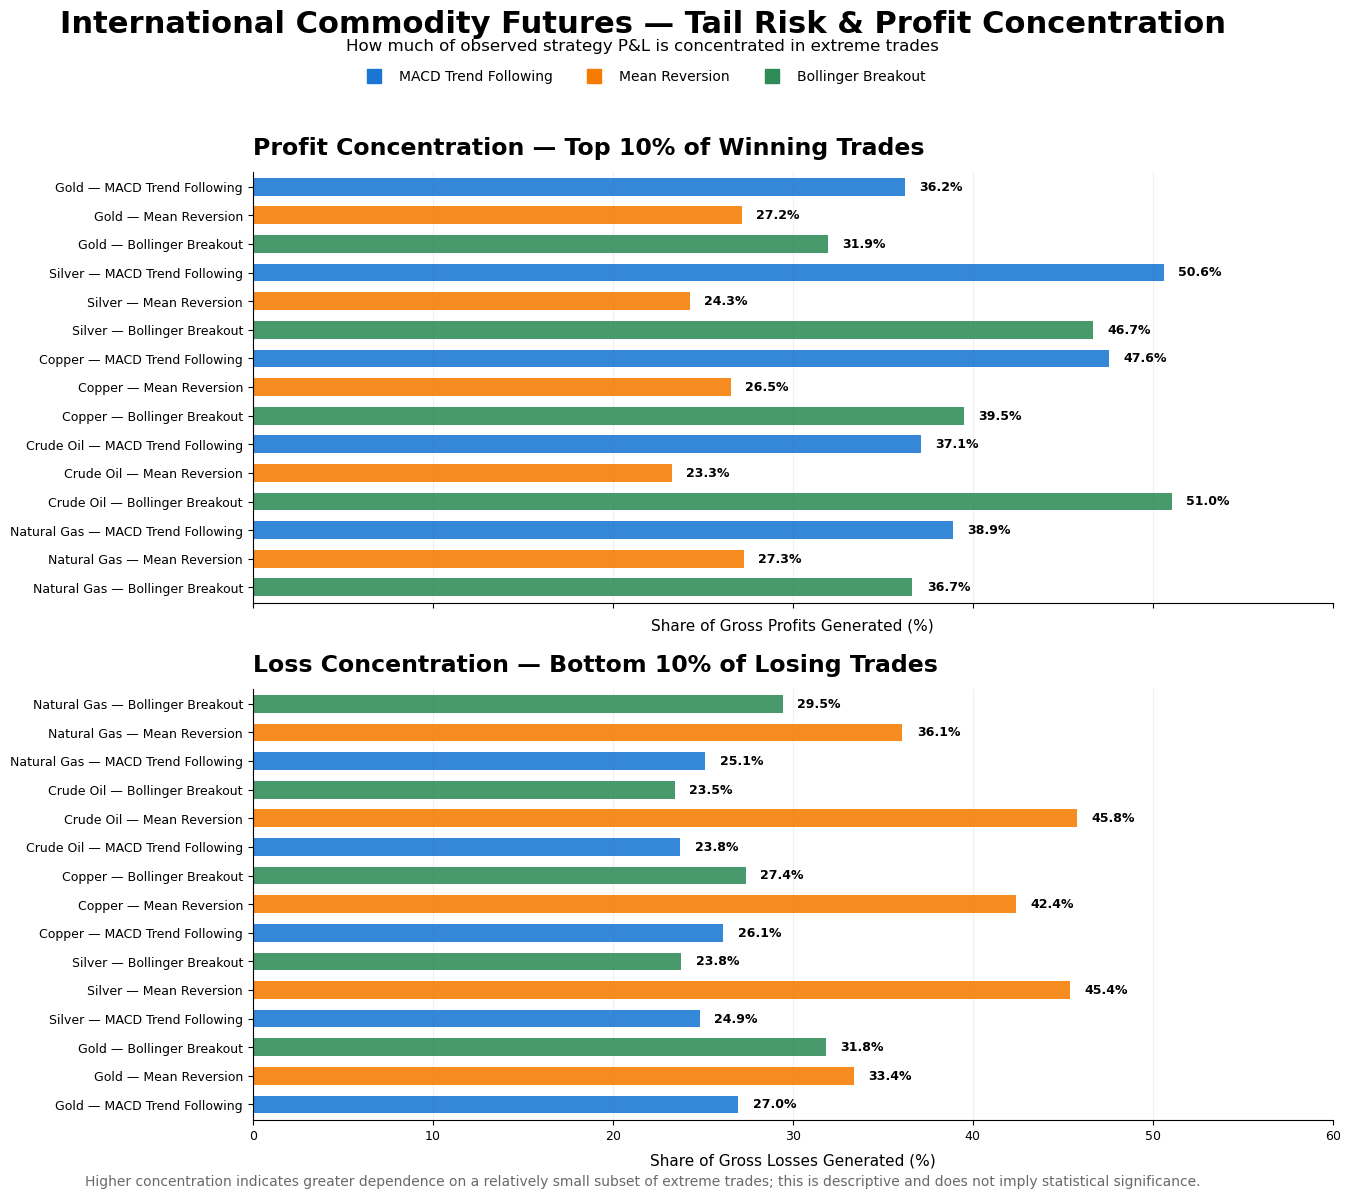


FIGURE 08 — TAIL RISK & PROFIT CONCENTRATION

Output:
  PNG: C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_08_Tail_Risk_Profit_Concentration.png
  SVG: C:\Users\navon\commodity_strategy_research\visualizations\figures\Figure_08_Tail_Risk_Profit_Concentration.svg

Structure:
  Panel A: Top 10% winning-trade profit concentration
  Panel B: Bottom 10% losing-trade loss concentration
  Commodities: 5
  Strategies: 3
  Total commodity × strategy cells: 15

Quantitative visual logic:
  Profit concentration: share of gross profits
  Loss concentration: share of gross losses
  Higher value: greater tail concentration
  Strategy identity colours: YES
  Common interpretation scale: YES
  Extreme trades removed: NO

Frozen data validation:
  Expected cells: 15
  Actual cells: 15
  Duplicate cells: 0
  Missing profit concentration: 0
  Missing loss concentration: 0
  Commodity coverage: PASS
  Strategy coverage: PASS

Data integrity:
  Source: Frozen tail_profit_loss_co

In [11]:
# ============================================================================
# FIGURE 08 — TAIL RISK & PROFIT CONCENTRATION
# ============================================================================
#
# Purpose:
#   Show how concentrated strategy P&L is in extreme winners and losers.
#
# Source:
#   Frozen tail_profit_loss_concentration.csv
#   Frozen tail_robustness_analysis.csv
#
# IMPORTANT:
#   - No strategy rerun
#   - No optimization
#   - No recalculation of research statistics
#   - No winsorization
#   - No return capping
#   - No trade modification
#
# Output:
#   Figure_08_Tail_Risk_Profit_Concentration.png
#   Figure_08_Tail_Risk_Profit_Concentration.svg
# ============================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================================
# 1. ROBUST PATH SETUP
# ============================================================================

RESEARCH_ROOT = Path(
    r"C:\Users\navon\commodity_strategy_research"
)

FIGURE_ROOT = (
    RESEARCH_ROOT
    / "visualizations"
    / "figures"
)

FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

FIGURE_08_PNG = (
    FIGURE_ROOT
    / "Figure_08_Tail_Risk_Profit_Concentration.png"
)

FIGURE_08_SVG = (
    FIGURE_ROOT
    / "Figure_08_Tail_Risk_Profit_Concentration.svg"
)

# ============================================================================
# 2. LOAD FROZEN DATA
# ============================================================================

TAIL_CONCENTRATION_PATH = (
    RESEARCH_ROOT
    / "statistics"
    / "tail_profit_loss_concentration.csv"
)

TAIL_ROBUSTNESS_PATH = (
    RESEARCH_ROOT
    / "statistics"
    / "tail_robustness_analysis.csv"
)

if not TAIL_CONCENTRATION_PATH.exists():
    raise FileNotFoundError(
        f"Frozen tail concentration dataset not found:\n"
        f"{TAIL_CONCENTRATION_PATH}"
    )

if not TAIL_ROBUSTNESS_PATH.exists():
    raise FileNotFoundError(
        f"Frozen tail robustness dataset not found:\n"
        f"{TAIL_ROBUSTNESS_PATH}"
    )

tail_df = pd.read_csv(TAIL_CONCENTRATION_PATH)
robustness_df = pd.read_csv(TAIL_ROBUSTNESS_PATH)

print("Frozen tail datasets loaded.")
print(f"Tail concentration shape: {tail_df.shape}")
print(f"Tail robustness shape:    {robustness_df.shape}")

print("\nAvailable columns — tail concentration:")
print(tail_df.columns.tolist())

print("\nAvailable columns — tail robustness:")
print(robustness_df.columns.tolist())


# ============================================================================
# 3. COLUMN DETECTION
# ============================================================================

def find_column(df, candidates, description):
    """
    Find a column using case-insensitive exact matching first,
    then normalized matching.
    """

    columns = list(df.columns)

    # Exact case-insensitive match
    lower_map = {
        str(col).strip().lower(): col
        for col in columns
    }

    for candidate in candidates:
        key = str(candidate).strip().lower()
        if key in lower_map:
            return lower_map[key]

    # Normalized fallback
    def normalize(text):
        return (
            str(text)
            .strip()
            .lower()
            .replace("%", "percent")
            .replace("_", " ")
            .replace("-", " ")
            .replace("–", " ")
            .replace("—", " ")
        )

    normalized_map = {
        normalize(col): col
        for col in columns
    }

    for candidate in candidates:
        key = normalize(candidate)
        if key in normalized_map:
            return normalized_map[key]

    raise KeyError(
        f"\nCould not identify {description}.\n"
        f"Available columns:\n{columns}"
    )


commodity_col = find_column(
    tail_df,
    ["Commodity"],
    "commodity column"
)

strategy_col = find_column(
    tail_df,
    ["Strategy"],
    "strategy column"
)

# Top-10% winner contribution
top10_profit_col = find_column(
    tail_df,
    [
        "Top 10% Winner Contribution %",
        "Top 10% Winners %",
        "Top 10 Winners %",
        "Top 10% Profit Contribution %",
        "Top 10% Winner Profit Contribution %",
        "Top 10% of Winners Contribution %",
    ],
    "top 10% winner profit contribution"
)

# Bottom-10% loser contribution
bottom10_loss_col = find_column(
    tail_df,
    [
        "Bottom 10% Loser Contribution %",
        "Bottom 10% Losers %",
        "Bottom 10 Losers %",
        "Bottom 10% Loss Contribution %",
        "Bottom 10% Loser Loss Contribution %",
        "Bottom 10% of Losers Contribution %",
    ],
    "bottom 10% loser loss contribution"
)


# ============================================================================
# 4. STANDARDIZE DATA
# ============================================================================

plot_df = tail_df[
    [
        commodity_col,
        strategy_col,
        top10_profit_col,
        bottom10_loss_col,
    ]
].copy()

plot_df.columns = [
    "Commodity",
    "Strategy",
    "Top10ProfitContribution",
    "Bottom10LossContribution",
]

plot_df["Top10ProfitContribution"] = pd.to_numeric(
    plot_df["Top10ProfitContribution"],
    errors="coerce"
)

plot_df["Bottom10LossContribution"] = pd.to_numeric(
    plot_df["Bottom10LossContribution"],
    errors="coerce"
)

# ============================================================================
# 5. STANDARDIZE NAMES
# ============================================================================

COMMODITY_ORDER = [
    "Gold",
    "Silver",
    "Copper",
    "Crude Oil",
    "Natural Gas",
]

STRATEGY_ORDER = [
    "MACD Trend Following",
    "Mean Reversion",
    "Bollinger Breakout",
]

# Handle possible abbreviated strategy names
strategy_map = {
    "MACD": "MACD Trend Following",
    "MACD Trend Following": "MACD Trend Following",
    "Mean Reversion": "Mean Reversion",
    "Bollinger": "Bollinger Breakout",
    "Bollinger Breakout": "Bollinger Breakout",
}

plot_df["Strategy"] = (
    plot_df["Strategy"]
    .astype(str)
    .str.strip()
    .map(lambda x: strategy_map.get(x, x))
)

# Commodity normalization
commodity_map = {
    "GOLD": "Gold",
    "Gold": "Gold",
    "SILVER": "Silver",
    "Silver": "Silver",
    "COPPER": "Copper",
    "Copper": "Copper",
    "CRUDE": "Crude Oil",
    "CRUDE_OIL": "Crude Oil",
    "Crude Oil": "Crude Oil",
    "NATURAL_GAS": "Natural Gas",
    "Natural Gas": "Natural Gas",
}

plot_df["Commodity"] = (
    plot_df["Commodity"]
    .astype(str)
    .str.strip()
    .map(lambda x: commodity_map.get(x, x))
)


# ============================================================================
# 6. FROZEN DATA VALIDATION
# ============================================================================

expected_commodities = set(COMMODITY_ORDER)
expected_strategies = set(STRATEGY_ORDER)

actual_commodities = set(plot_df["Commodity"].dropna())
actual_strategies = set(plot_df["Strategy"].dropna())

expected_cells = 15
actual_cells = len(plot_df)

duplicate_cells = (
    plot_df
    .duplicated(["Commodity", "Strategy"])
    .sum()
)

missing_profit = plot_df["Top10ProfitContribution"].isna().sum()
missing_loss = plot_df["Bottom10LossContribution"].isna().sum()

coverage_pass = (
    actual_commodities == expected_commodities
    and actual_strategies == expected_strategies
)

cell_pass = actual_cells == expected_cells

validation_pass = (
    coverage_pass
    and cell_pass
    and duplicate_cells == 0
    and missing_profit == 0
    and missing_loss == 0
)

if not validation_pass:
    raise ValueError(
        "\nFIGURE 08 DATA VALIDATION FAILED.\n"
        f"Commodity coverage: {actual_commodities}\n"
        f"Strategy coverage: {actual_strategies}\n"
        f"Cells: {actual_cells}\n"
        f"Duplicates: {duplicate_cells}\n"
        f"Missing profit contribution: {missing_profit}\n"
        f"Missing loss contribution: {missing_loss}"
    )

print("\n🟢 Frozen data validation PASS")


# ============================================================================
# 7. ORDER DATA
# ============================================================================

plot_df["Commodity"] = pd.Categorical(
    plot_df["Commodity"],
    categories=COMMODITY_ORDER,
    ordered=True
)

plot_df["Strategy"] = pd.Categorical(
    plot_df["Strategy"],
    categories=STRATEGY_ORDER,
    ordered=True
)

plot_df = (
    plot_df
    .sort_values(["Commodity", "Strategy"])
    .reset_index(drop=True)
)

# Display labels
plot_df["Label"] = (
    plot_df["Commodity"].astype(str)
    + " — "
    + plot_df["Strategy"].astype(str)
)


# ============================================================================
# 8. STRATEGY IDENTITY COLOURS
# ============================================================================

STRATEGY_COLORS = {
    "MACD Trend Following": "#1976D2",
    "Mean Reversion": "#F57C00",
    "Bollinger Breakout": "#2E8B57",
}


# ============================================================================
# 9. CREATE FIGURE
# ============================================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(15, 12),
    sharex=True,
    gridspec_kw={
        "hspace": 0.20,
        "height_ratios": [1, 1],
    }
)

ax_profit, ax_loss = axes


# ============================================================================
# 10. PANEL A — TOP 10% WINNER PROFIT CONTRIBUTION
# ============================================================================

y = np.arange(len(plot_df))

for idx, row in plot_df.iterrows():

    strategy = str(row["Strategy"])

    ax_profit.barh(
        idx,
        row["Top10ProfitContribution"],
        height=0.62,
        color=STRATEGY_COLORS[strategy],
        alpha=0.88,
    )

    ax_profit.text(
        row["Top10ProfitContribution"] + 0.8,
        idx,
        f"{row['Top10ProfitContribution']:.1f}%",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold",
    )

ax_profit.set_title(
    "Profit Concentration — Top 10% of Winning Trades",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=12,
)

ax_profit.set_xlabel(
    "Share of Gross Profits Generated (%)",
    fontsize=11,
    labelpad=8,
)

ax_profit.set_ylabel(
    "",
    fontsize=11,
)

ax_profit.set_yticks(y)
ax_profit.set_yticklabels(
    plot_df["Label"],
    fontsize=9,
)

ax_profit.invert_yaxis()

ax_profit.grid(
    axis="x",
    alpha=0.20,
    linewidth=0.8,
)

ax_profit.set_axisbelow(True)

# Give labels room on the right
profit_max = plot_df["Top10ProfitContribution"].max()
ax_profit.set_xlim(
    0,
    max(60, profit_max * 1.18)
)


# ============================================================================
# 11. PANEL B — BOTTOM 10% LOSER LOSS CONTRIBUTION
# ============================================================================

for idx, row in plot_df.iterrows():

    strategy = str(row["Strategy"])

    ax_loss.barh(
        idx,
        row["Bottom10LossContribution"],
        height=0.62,
        color=STRATEGY_COLORS[strategy],
        alpha=0.88,
    )

    ax_loss.text(
        row["Bottom10LossContribution"] + 0.8,
        idx,
        f"{row['Bottom10LossContribution']:.1f}%",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold",
    )

ax_loss.set_title(
    "Loss Concentration — Bottom 10% of Losing Trades",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=12,
)

ax_loss.set_xlabel(
    "Share of Gross Losses Generated (%)",
    fontsize=11,
    labelpad=8,
)

ax_loss.set_ylabel(
    "",
    fontsize=11,
)

ax_loss.set_yticks(y)
ax_loss.set_yticklabels(
    plot_df["Label"],
    fontsize=9,
)

ax_loss.grid(
    axis="x",
    alpha=0.20,
    linewidth=0.8,
)

ax_loss.set_axisbelow(True)

loss_max = plot_df["Bottom10LossContribution"].max()

ax_loss.set_xlim(
    0,
    max(60, loss_max * 1.18)
)


# ============================================================================
# 12. STRATEGY LEGEND
# ============================================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markersize=10,
        markerfacecolor=STRATEGY_COLORS["MACD Trend Following"],
        markeredgecolor=STRATEGY_COLORS["MACD Trend Following"],
        label="MACD Trend Following",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markersize=10,
        markerfacecolor=STRATEGY_COLORS["Mean Reversion"],
        markeredgecolor=STRATEGY_COLORS["Mean Reversion"],
        label="Mean Reversion",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markersize=10,
        markerfacecolor=STRATEGY_COLORS["Bollinger Breakout"],
        markeredgecolor=STRATEGY_COLORS["Bollinger Breakout"],
        label="Bollinger Breakout",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.955),
    ncol=3,
    frameon=False,
    fontsize=10,
)


# ============================================================================
# 13. MAIN TITLE + INTERPRETATION
# ============================================================================

fig.suptitle(
    "International Commodity Futures — Tail Risk & Profit Concentration",
    fontsize=22,
    fontweight="bold",
    y=0.995,
)

fig.text(
    0.5,
    0.965,
    "How much of observed strategy P&L is concentrated in extreme trades",
    ha="center",
    va="center",
    fontsize=12,
)

fig.text(
    0.5,
    0.018,
    "Higher concentration indicates greater dependence on a relatively small subset of extreme trades; "
    "this is descriptive and does not imply statistical significance.",
    ha="center",
    va="center",
    fontsize=10,
    color="dimgray",
)


# ============================================================================
# 14. CLEAN AXES
# ============================================================================

for ax in axes:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        labelsize=9,
    )

    ax.margins(y=0.015)


# ============================================================================
# 15. LAYOUT
# ============================================================================

plt.subplots_adjust(
    left=0.24,
    right=0.96,
    top=0.86,
    bottom=0.07,
    hspace=0.24,
)


# ============================================================================
# 16. SAVE
# ============================================================================

fig.savefig(
    FIGURE_08_PNG,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    FIGURE_08_SVG,
    format="svg",
    bbox_inches="tight",
    facecolor="white",
)

plt.show()


# ============================================================================
# 17. FINAL VALIDATION / REPORT
# ============================================================================

print()
print("=" * 72)
print("FIGURE 08 — TAIL RISK & PROFIT CONCENTRATION")
print("=" * 72)

print()
print("Output:")
print(f"  PNG: {FIGURE_08_PNG}")
print(f"  SVG: {FIGURE_08_SVG}")

print()
print("Structure:")
print("  Panel A: Top 10% winning-trade profit concentration")
print("  Panel B: Bottom 10% losing-trade loss concentration")
print("  Commodities: 5")
print("  Strategies: 3")
print("  Total commodity × strategy cells: 15")

print()
print("Quantitative visual logic:")
print("  Profit concentration: share of gross profits")
print("  Loss concentration: share of gross losses")
print("  Higher value: greater tail concentration")
print("  Strategy identity colours: YES")
print("  Common interpretation scale: YES")
print("  Extreme trades removed: NO")

print()
print("Frozen data validation:")
print(f"  Expected cells: {expected_cells}")
print(f"  Actual cells: {actual_cells}")
print(f"  Duplicate cells: {duplicate_cells}")
print(f"  Missing profit concentration: {missing_profit}")
print(f"  Missing loss concentration: {missing_loss}")
print(f"  Commodity coverage: {'PASS' if actual_commodities == expected_commodities else 'FAIL'}")
print(f"  Strategy coverage: {'PASS' if actual_strategies == expected_strategies else 'FAIL'}")

print()
print("Data integrity:")
print("  Source: Frozen tail_profit_loss_concentration")
print("  Strategy rerun: NO")
print("  Optimization: NO")
print("  Trade data modified: NO")
print("  Research statistics recalculated: NO")
print("  Winsorization: NO")
print("  Return capping: NO")
print("  Transaction costs added: NO")

print()
print("Visual design:")
print("  Two-panel concentration analysis: YES")
print("  Strategy identity colours: YES")
print("  Direct value labels: YES")
print("  Legend outside plotting panels: YES")
print("  Footer outside plotting panels: YES")
print("  Figure number inside image: NO")
print("  Publication-quality SVG: YES")

print()
print("Validation:")
print(f"  Overall validation: {'PASS' if validation_pass else 'FAIL'}")

print()
print("🟢 FIGURE 08 READY FOR VISUAL REVIEW")
print("=" * 72)

V18 — FINAL IMAGE EXPORT


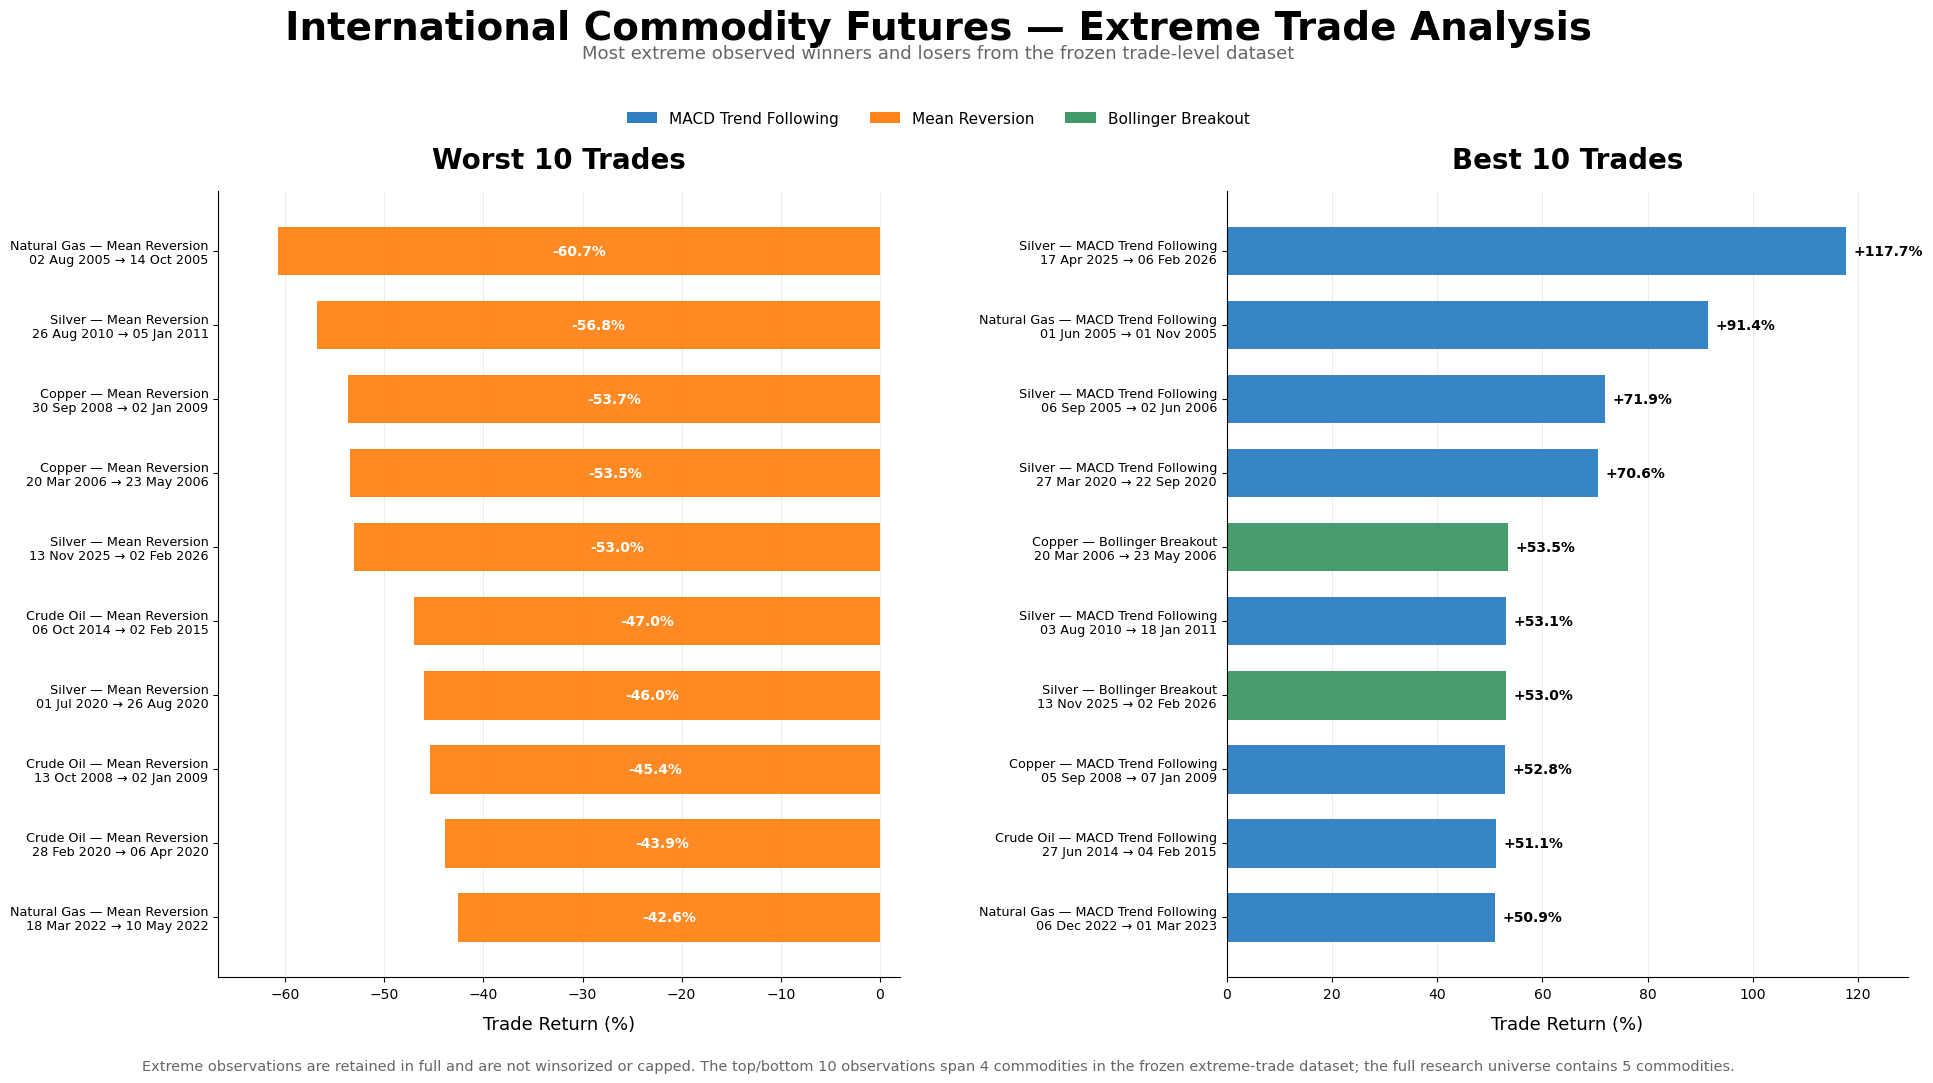


V18 — FINAL IMAGE VALIDATION
✓ Frozen dataset rows       : 60
✓ Worst trades              : 10
✓ Best trades               : 10
✓ Total displayed           : 20
✓ Worst return              : -60.70%
✓ Best return               : +117.74%
✓ Extreme commodities       : 4
✓ Full research universe    : 5
✓ Displayed commodities     : Copper, Crude Oil, Natural Gas, Silver

Strategy distribution:
Strategy
Mean Reversion          10
MACD Trend Following     8
Bollinger Breakout       2
Name: count, dtype: int64

✓ Final image               : C:\Users\navon\commodity_strategy_research\visualizations\figures\V18_extreme_trade_analysis_FINAL.png

🟢 V18 IMAGE: FINAL / FROZEN
🟢 No research data modified
🟢 No strategy rerun
🟢 No winsorization
🟢 No return capping
🟢 Final publication image exported at 300 DPI


In [5]:
# =====================================================================
# V18 — FINAL IMAGE EXPORT / FREEZE
# International Commodity Futures — Extreme Trade Analysis
# =====================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

print("=" * 70)
print("V18 — FINAL IMAGE EXPORT")
print("=" * 70)

# ---------------------------------------------------------------------
# 1. PATHS
# ---------------------------------------------------------------------

if "ROOT" in globals():
    RESEARCH_ROOT = Path(ROOT)
else:
    RESEARCH_ROOT = Path(
        r"C:\Users\navon\commodity_strategy_research"
    )

INPUT_PATH = (
    RESEARCH_ROOT
    / "distributions"
    / "extreme_trades.csv"
)

OUTPUT_DIR = (
    RESEARCH_ROOT
    / "visualizations"
    / "figures"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_PATH = (
    OUTPUT_DIR
    / "V18_extreme_trade_analysis_FINAL.png"
)

# ---------------------------------------------------------------------
# 2. LOAD FROZEN DATA
# ---------------------------------------------------------------------

extreme_df = pd.read_csv(INPUT_PATH)

required_columns = [
    "Trade ID",
    "Ticker",
    "Strategy",
    "Entry Date",
    "Exit Date",
    "Position",
    "Entry Price",
    "Exit Price",
    "Return %",
    "Holding Days",
    "Extreme Type",
]

missing = [
    col for col in required_columns
    if col not in extreme_df.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

extreme_df["Return %"] = pd.to_numeric(
    extreme_df["Return %"],
    errors="coerce"
)

extreme_df["Entry Date"] = pd.to_datetime(
    extreme_df["Entry Date"],
    errors="coerce"
)

extreme_df["Exit Date"] = pd.to_datetime(
    extreme_df["Exit Date"],
    errors="coerce"
)

plot_df = extreme_df.dropna(
    subset=[
        "Return %",
        "Entry Date",
        "Exit Date"
    ]
).copy()

# ---------------------------------------------------------------------
# 3. SELECT EXTREMES
# ---------------------------------------------------------------------

worst_df = (
    plot_df
    .sort_values("Return %", ascending=True)
    .head(10)
    .copy()
)

best_df = (
    plot_df
    .sort_values("Return %", ascending=False)
    .head(10)
    .copy()
)

# ---------------------------------------------------------------------
# 4. DISPLAY NAME MAPPINGS
# ---------------------------------------------------------------------

commodity_map = {
    "GC=F": "Gold",
    "SI=F": "Silver",
    "HG=F": "Copper",
    "CL=F": "Crude Oil",
    "NG=F": "Natural Gas",

    "GOLD": "Gold",
    "SILVER": "Silver",
    "COPPER": "Copper",
    "CRUDE_OIL": "Crude Oil",
    "NATURAL_GAS": "Natural Gas",
}

strategy_map = {
    "MACD": "MACD Trend Following",
    "MACD Trend Following": "MACD Trend Following",
    "Mean Reversion": "Mean Reversion",
    "Bollinger": "Bollinger Breakout",
    "Bollinger Breakout": "Bollinger Breakout",
}

def commodity_name(x):
    return commodity_map.get(str(x), str(x))

def strategy_name(x):
    return strategy_map.get(str(x), str(x))

def trade_label(row):
    return (
        f"{commodity_name(row['Ticker'])} — "
        f"{strategy_name(row['Strategy'])}\n"
        f"{row['Entry Date'].strftime('%d %b %Y')} → "
        f"{row['Exit Date'].strftime('%d %b %Y')}"
    )

worst_labels = [
    trade_label(row)
    for _, row in worst_df.iterrows()
]

best_labels = [
    trade_label(row)
    for _, row in best_df.iterrows()
]

# ---------------------------------------------------------------------
# 5. STRATEGY COLOURS
# ---------------------------------------------------------------------

strategy_colors = {
    "MACD Trend Following": "#2F7FC4",
    "Mean Reversion": "#FF851B",
    "Bollinger Breakout": "#3F9969",
}

def strategy_color(x):
    return strategy_colors.get(
        strategy_name(x),
        "#777777"
    )

worst_colors = [
    strategy_color(x)
    for x in worst_df["Strategy"]
]

best_colors = [
    strategy_color(x)
    for x in best_df["Strategy"]
]

# ---------------------------------------------------------------------
# 6. FIGURE
# ---------------------------------------------------------------------

fig, (ax_left, ax_right) = plt.subplots(
    1,
    2,
    figsize=(20, 11),
    gridspec_kw={
        "width_ratios": [1, 1],
        "wspace": 0.48,
    },
)

fig.patch.set_facecolor("white")

# ---------------------------------------------------------------------
# 7. WORST 10
# ---------------------------------------------------------------------

y_worst = np.arange(len(worst_df))

bars_worst = ax_left.barh(
    y_worst,
    worst_df["Return %"],
    color=worst_colors,
    height=0.66,
    alpha=0.96,
)

ax_left.set_yticks(y_worst)
ax_left.set_yticklabels(
    worst_labels,
    fontsize=9.2,
    ha="right",
)

ax_left.invert_yaxis()

ax_left.set_title(
    "Worst 10 Trades",
    fontsize=20,
    fontweight="bold",
    pad=16,
)

ax_left.set_xlabel(
    "Trade Return (%)",
    fontsize=13,
    labelpad=10,
)

ax_left.xaxis.grid(
    True,
    linewidth=0.7,
    alpha=0.25,
)

ax_left.set_axisbelow(True)

ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)

worst_min = worst_df["Return %"].min()

ax_left.set_xlim(
    worst_min * 1.10,
    2
)

for bar, value in zip(
    bars_worst,
    worst_df["Return %"]
):

    ax_left.text(
        value * 0.50,
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.1f}%",
        va="center",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="white",
        clip_on=True,
    )

# ---------------------------------------------------------------------
# 8. BEST 10
# ---------------------------------------------------------------------

y_best = np.arange(len(best_df))

bars_best = ax_right.barh(
    y_best,
    best_df["Return %"],
    color=best_colors,
    height=0.66,
    alpha=0.96,
)

ax_right.set_yticks(y_best)
ax_right.set_yticklabels(
    best_labels,
    fontsize=9.2,
    ha="right",
)

ax_right.invert_yaxis()

ax_right.set_title(
    "Best 10 Trades",
    fontsize=20,
    fontweight="bold",
    pad=16,
)

ax_right.set_xlabel(
    "Trade Return (%)",
    fontsize=13,
    labelpad=10,
)

ax_right.xaxis.grid(
    True,
    linewidth=0.7,
    alpha=0.25,
)

ax_right.set_axisbelow(True)

ax_right.spines["top"].set_visible(False)
ax_right.spines["right"].set_visible(False)

best_max = best_df["Return %"].max()

ax_right.set_xlim(
    0,
    best_max * 1.10
)

for bar, value in zip(
    bars_best,
    best_df["Return %"]
):

    ax_right.text(
        value + best_max * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f"+{value:.1f}%",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="black",
        clip_on=False,
    )

# ---------------------------------------------------------------------
# 9. MAIN TITLE
# ---------------------------------------------------------------------

fig.suptitle(
    "International Commodity Futures — Extreme Trade Analysis",
    fontsize=28,
    fontweight="bold",
    y=0.985,
)

fig.text(
    0.5,
    0.945,
    "Most extreme observed winners and losers from the frozen trade-level dataset",
    ha="center",
    va="center",
    fontsize=13,
    color="#666666",
)

# ---------------------------------------------------------------------
# 10. LEGEND
# ---------------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=strategy_colors["MACD Trend Following"],
        label="MACD Trend Following",
    ),
    Patch(
        facecolor=strategy_colors["Mean Reversion"],
        label="Mean Reversion",
    ),
    Patch(
        facecolor=strategy_colors["Bollinger Breakout"],
        label="Bollinger Breakout",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.905),
    ncol=3,
    frameon=False,
    fontsize=11,
)

# ---------------------------------------------------------------------
# 11. COMMODITY COUNT
# ---------------------------------------------------------------------

extreme_commodities = sorted(
    {
        commodity_name(x)
        for x in plot_df["Ticker"].dropna().unique()
    }
)

extreme_commodity_count = len(
    extreme_commodities
)

full_research_commodities = [
    "Gold",
    "Silver",
    "Copper",
    "Crude Oil",
    "Natural Gas",
]

full_research_count = len(
    full_research_commodities
)

# ---------------------------------------------------------------------
# 12. FINAL ACCURATE FOOTNOTE
# ---------------------------------------------------------------------

fig.text(
    0.5,
    0.018,
    (
        "Extreme observations are retained in full and are not "
        "winsorized or capped. "
        f"The top/bottom 10 observations span "
        f"{extreme_commodity_count} commodities in the frozen "
        f"extreme-trade dataset; the full research universe contains "
        f"{full_research_count} commodities."
    ),
    ha="center",
    va="bottom",
    fontsize=10.5,
    color="#666666",
)

# ---------------------------------------------------------------------
# 13. FINAL LAYOUT
# ---------------------------------------------------------------------

plt.subplots_adjust(
    left=0.14,
    right=0.985,
    top=0.82,
    bottom=0.105,
    wspace=0.48,
)

# ---------------------------------------------------------------------
# 14. SAVE FINAL IMAGE
# ---------------------------------------------------------------------

fig.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

# ---------------------------------------------------------------------
# 15. FINAL VALIDATION
# ---------------------------------------------------------------------

displayed_trades = (
    len(worst_df) +
    len(best_df)
)

displayed_commodities = sorted(
    {
        commodity_name(x)
        for x in pd.concat(
            [
                worst_df["Ticker"],
                best_df["Ticker"],
            ]
        ).dropna().unique()
    }
)

strategy_distribution = (
    pd.concat(
        [
            worst_df["Strategy"],
            best_df["Strategy"],
        ]
    )
    .map(strategy_name)
    .value_counts()
)

assert len(worst_df) == 10
assert len(best_df) == 10
assert displayed_trades == 20

assert np.isclose(
    worst_df["Return %"].min(),
    plot_df["Return %"].min(),
)

assert np.isclose(
    best_df["Return %"].max(),
    plot_df["Return %"].max(),
)

assert extreme_commodity_count == 4
assert full_research_count == 5

assert OUTPUT_PATH.exists()

print()
print("=" * 70)
print("V18 — FINAL IMAGE VALIDATION")
print("=" * 70)

print(f"✓ Frozen dataset rows       : {len(extreme_df):,}")
print(f"✓ Worst trades              : {len(worst_df)}")
print(f"✓ Best trades               : {len(best_df)}")
print(f"✓ Total displayed           : {displayed_trades}")
print(f"✓ Worst return              : {worst_df['Return %'].min():+.2f}%")
print(f"✓ Best return               : {best_df['Return %'].max():+.2f}%")
print(f"✓ Extreme commodities       : {extreme_commodity_count}")
print(f"✓ Full research universe    : {full_research_count}")
print(
    f"✓ Displayed commodities     : "
    f"{', '.join(displayed_commodities)}"
)
print()
print("Strategy distribution:")
print(strategy_distribution)
print()
print(f"✓ Final image               : {OUTPUT_PATH}")
print()
print("🟢 V18 IMAGE: FINAL / FROZEN")
print("🟢 No research data modified")
print("🟢 No strategy rerun")
print("🟢 No winsorization")
print("🟢 No return capping")
print("🟢 Final publication image exported at 300 DPI")

V21 FINAL RESEARCH DASHBOARD — HORIZONTAL SPACING CORRECTED
✓ Research archive resolved: C:\Users\navon\commodity_strategy_research
✓ Loaded: statistics\expectancy_matrix.csv (5 rows × 4 columns)
✓ Loaded: statistics\profit_factor_matrix.csv (5 rows × 4 columns)
✓ Loaded: statistics\win_rate_matrix.csv (5 rows × 4 columns)
✓ Loaded: statistics\holding_period_matrix.csv (5 rows × 4 columns)
✓ Loaded: statistics\overall_strategy_comparison.csv (3 rows × 25 columns)
✓ Loaded: trades\all_strategy_trades.csv (2,499 rows × 10 columns)


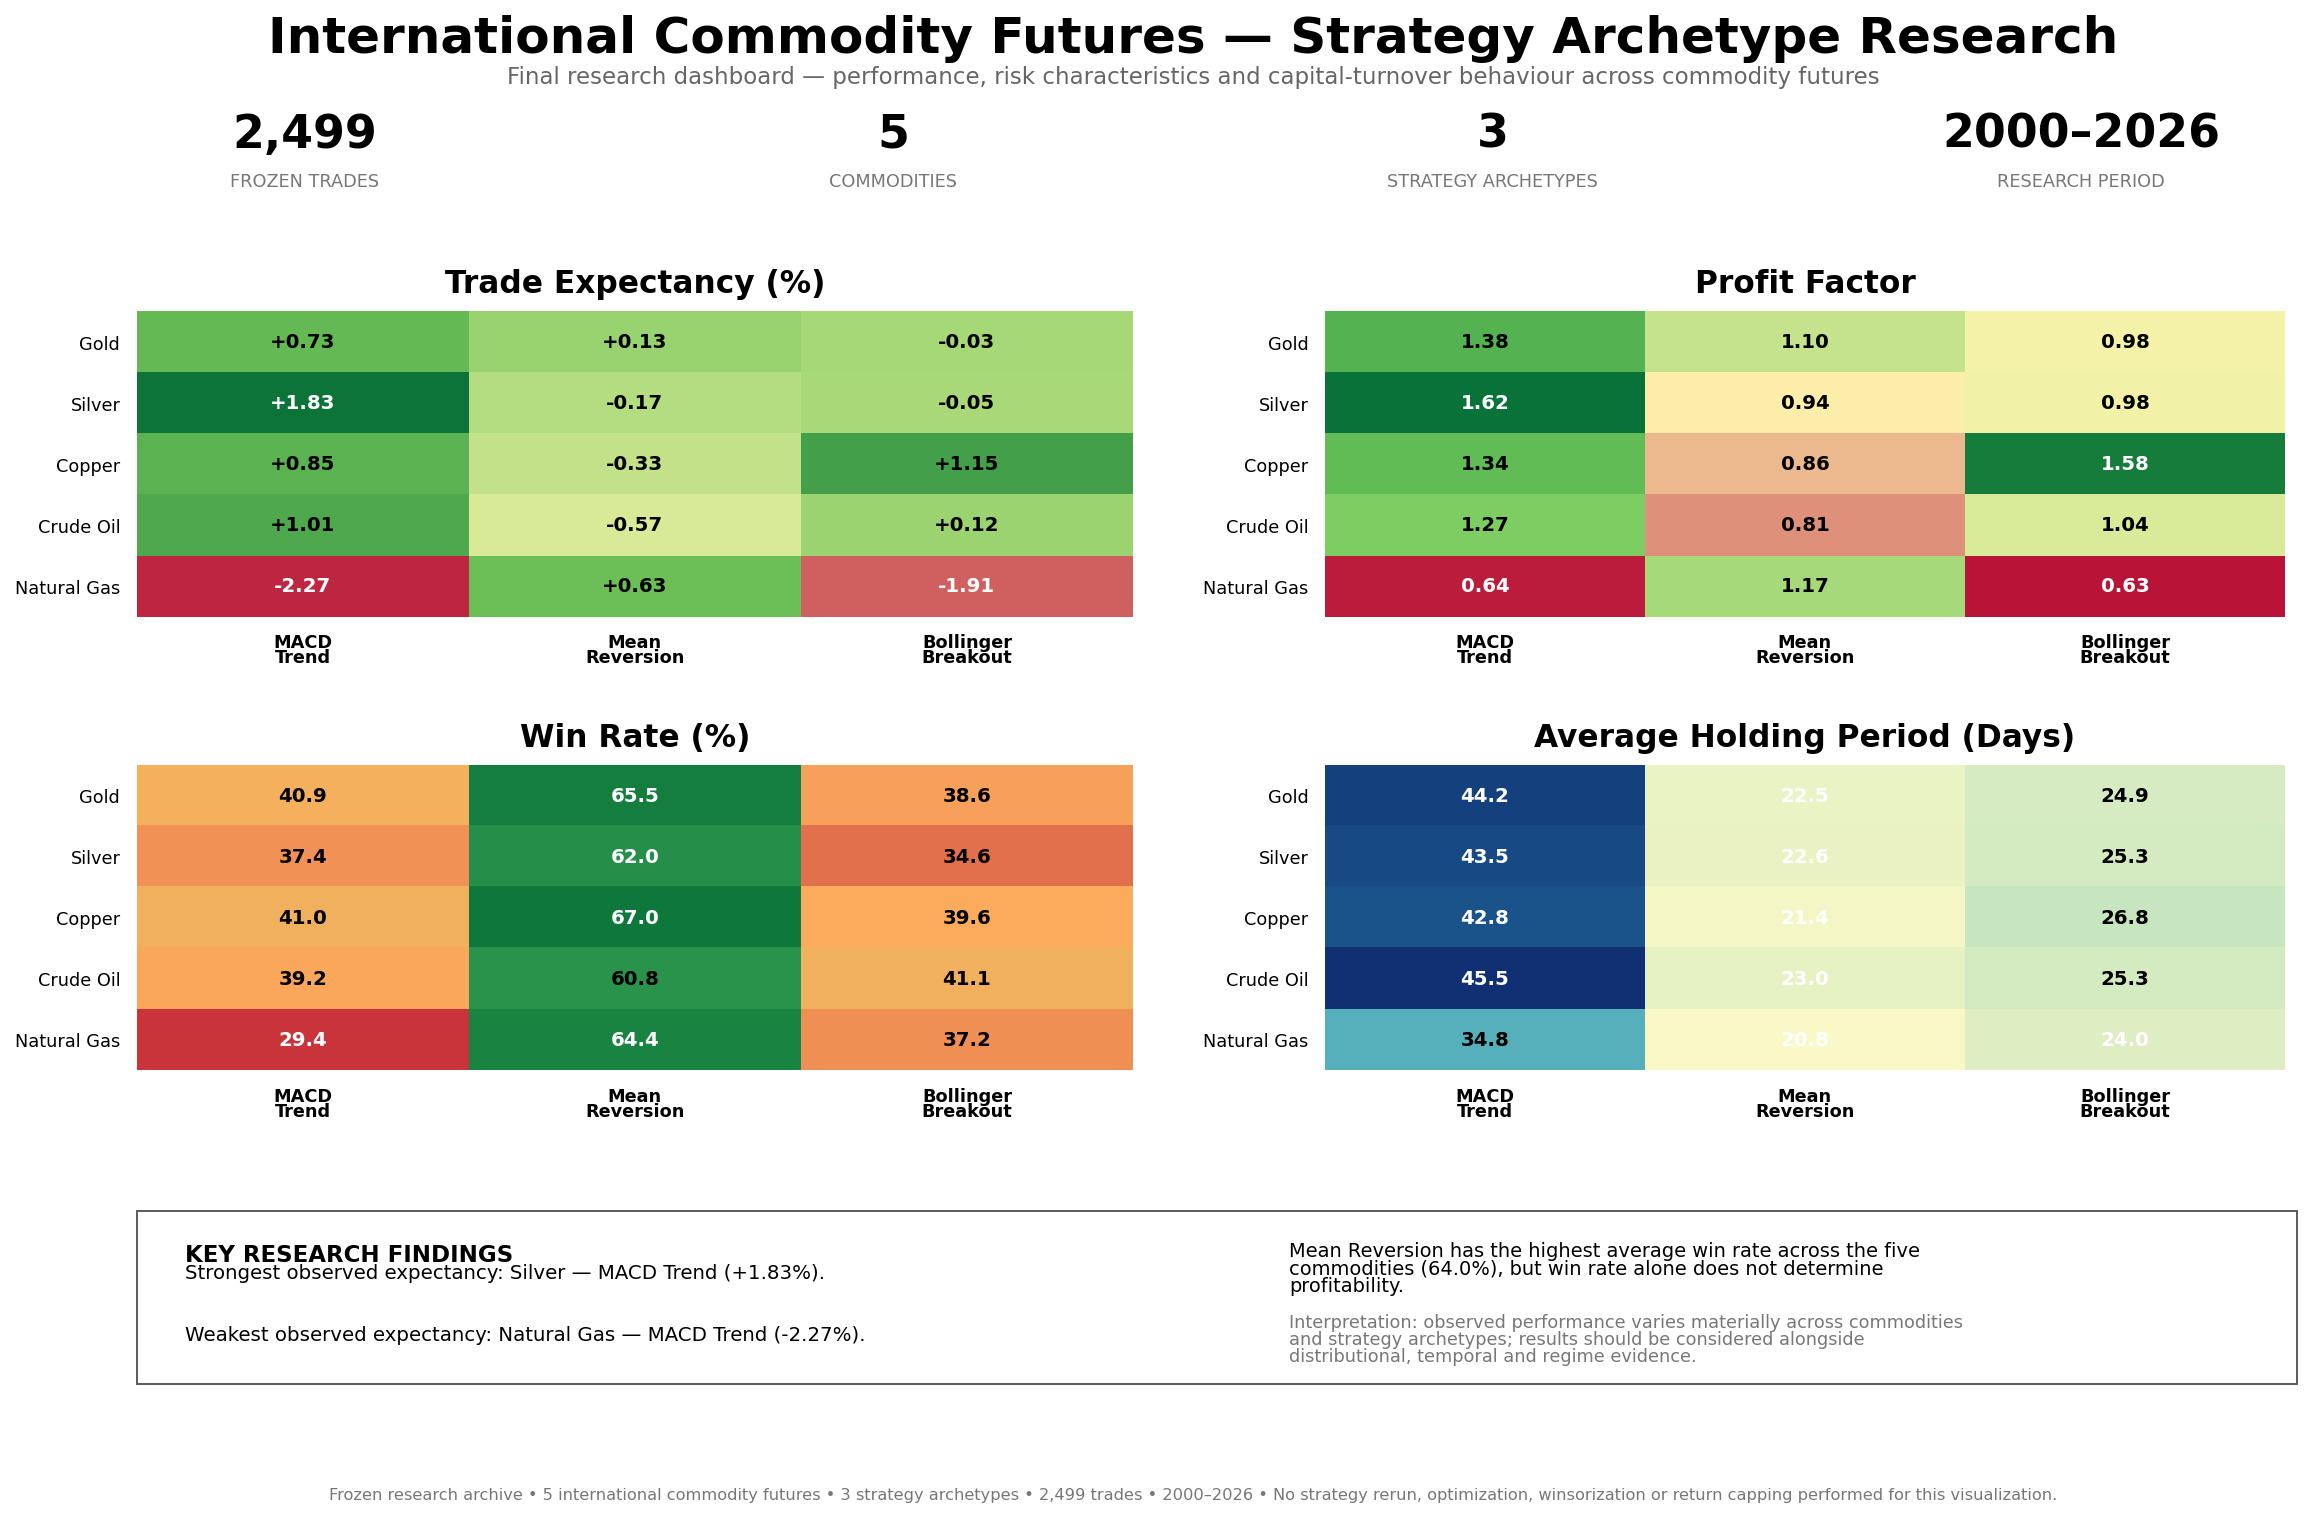



V21 FINAL RESEARCH DASHBOARD — VALIDATION
✓ Frozen trade count        : 2,499
✓ Commodity universe        : 5
✓ Strategy archetypes       : 3
✓ Research period           : 2000–2026

Heatmap datasets:
✓ Expectancy matrix         : (5, 3)
✓ Profit factor matrix      : (5, 3)
✓ Win rate matrix           : (5, 3)
✓ Holding period matrix     : (5, 3)

✓ Strongest expectancy      : Silver — MACD Trend (+1.83%)
✓ Weakest expectancy        : Natural Gas — MACD Trend (-2.27%)

✓ Mean Reversion avg win rate: 64.0%
✓ Output file               : C:\Users\navon\commodity_strategy_research\visualizations\figures\V21_final_research_dashboard.png


🟢 V21 FINAL RESEARCH DASHBOARD: HORIZONTAL SPACING CORRECTED

Research data was not modified.
No strategy was rerun.
No optimization was performed.
No returns were winsorized or capped.
Final dashboard exported at 300 DPI.


In [19]:
# =====================================================================
# V21 FINAL RESEARCH DASHBOARD — FINAL HORIZONTAL-SPACING VERSION
# =====================================================================
# FINAL FIX:
#   • Increased horizontal separation between the left/right dashboards
#   • Reduced y-axis label size slightly to prevent cross-panel intrusion
#   • Reduced heatmap widths symmetrically
#   • Kept the overall dashboard vertically unchanged
#   • Kept all table values and research conclusions unchanged
#   • Findings box remains inside the frame
#   • No research data modified
#   • No strategy rerun
# =====================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import warnings

warnings.filterwarnings("ignore")

print("=" * 75)
print("V21 FINAL RESEARCH DASHBOARD — HORIZONTAL SPACING CORRECTED")
print("=" * 75)


# =====================================================================
# 1. RESOLVE RESEARCH ARCHIVE
# =====================================================================

CANDIDATE_ROOTS = [
    Path(r"C:\Users\navon\commodity_strategy_research"),
    Path.cwd() / "commodity_strategy_research",
    Path.cwd().parent / "commodity_strategy_research",
]

ROOT = None

for candidate in CANDIDATE_ROOTS:
    if candidate.exists() and candidate.is_dir():
        ROOT = candidate
        break

if ROOT is None:
    raise FileNotFoundError(
        "Could not locate the commodity_strategy_research archive.\n"
        "Expected path:\n"
        r"C:\Users\navon\commodity_strategy_research"
    )

print(f"✓ Research archive resolved: {ROOT}")


# =====================================================================
# 2. LOAD FROZEN DATASETS
# =====================================================================

def load_csv(relative_path):

    path = ROOT / relative_path

    if not path.exists():
        raise FileNotFoundError(
            f"Required dataset not found:\n{path}"
        )

    df = pd.read_csv(path)

    print(
        f"✓ Loaded: {relative_path} "
        f"({df.shape[0]:,} rows × {df.shape[1]:,} columns)"
    )

    return df


expectancy_raw = load_csv(
    Path("statistics") / "expectancy_matrix.csv"
)

profit_factor_raw = load_csv(
    Path("statistics") / "profit_factor_matrix.csv"
)

win_rate_raw = load_csv(
    Path("statistics") / "win_rate_matrix.csv"
)

holding_period_raw = load_csv(
    Path("statistics") / "holding_period_matrix.csv"
)

overall_strategy = load_csv(
    Path("statistics") / "overall_strategy_comparison.csv"
)

master_trades = load_csv(
    Path("trades") / "all_strategy_trades.csv"
)


# =====================================================================
# 3. EXPECTED STRUCTURE
# =====================================================================

EXPECTED_COMMODITIES = [
    "Gold",
    "Silver",
    "Copper",
    "Crude Oil",
    "Natural Gas",
]

EXPECTED_STRATEGIES = [
    "MACD Trend",
    "Mean Reversion",
    "Bollinger Breakout",
]


# =====================================================================
# 4. ROBUST LABEL NORMALIZATION
# =====================================================================

def normalize_label(value):

    if pd.isna(value):
        return ""

    text = str(value).strip()

    aliases = {
        "GOLD": "Gold",
        "SILVER": "Silver",
        "COPPER": "Copper",
        "CRUDE": "Crude Oil",
        "CRUDE_OIL": "Crude Oil",
        "CRUDE OIL": "Crude Oil",
        "NATURAL_GAS": "Natural Gas",
        "NATURAL GAS": "Natural Gas",
        "NG": "Natural Gas",

        "MACD": "MACD Trend",
        "MACD TREND": "MACD Trend",
        "MACD TREND FOLLOWING": "MACD Trend",
        "MACD Trend Following": "MACD Trend",

        "MEAN REVERSION": "Mean Reversion",

        "BOLLINGER": "Bollinger Breakout",
        "BOLLINGER BREAKOUT": "Bollinger Breakout",
    }

    return aliases.get(text.upper(), text)


# =====================================================================
# 5. MATRIX PREPARATION
# =====================================================================

def prepare_matrix(df, matrix_name):

    temp = df.copy()

    temp = temp.dropna(
        axis=1,
        how="all"
    )

    # -------------------------------------------------------------
    # Identify index / commodity column
    # -------------------------------------------------------------

    index_col = None

    unnamed_columns = [
        c
        for c in temp.columns
        if str(c).lower().startswith("unnamed")
    ]

    if unnamed_columns:
        index_col = unnamed_columns[0]

    else:

        first_col = temp.columns[0]

        first_values = [
            normalize_label(v)
            for v in temp[first_col].dropna().head(10)
        ]

        if any(
            v in EXPECTED_COMMODITIES
            for v in first_values
        ):
            index_col = first_col

    if index_col is None:
        index_col = temp.columns[0]

    temp = temp.set_index(index_col)

    # -------------------------------------------------------------
    # Normalize commodity labels
    # -------------------------------------------------------------

    temp.index = [
        normalize_label(v)
        for v in temp.index
    ]

    # -------------------------------------------------------------
    # Normalize strategy labels
    # -------------------------------------------------------------

    temp.columns = [
        normalize_label(c)
        for c in temp.columns
    ]

    # -------------------------------------------------------------
    # Explicit strategy aliases
    # -------------------------------------------------------------

    column_aliases = {
        "MACD Trend Following": "MACD Trend",
        "MACD": "MACD Trend",
        "Mean Reversion": "Mean Reversion",
        "Bollinger": "Bollinger Breakout",
        "Bollinger Breakout": "Bollinger Breakout",
    }

    temp = temp.rename(
        columns={
            col: column_aliases.get(col, col)
            for col in temp.columns
        }
    )

    # -------------------------------------------------------------
    # Validate rows
    # -------------------------------------------------------------

    missing_rows = [
        c
        for c in EXPECTED_COMMODITIES
        if c not in temp.index
    ]

    if missing_rows:
        raise ValueError(
            f"{matrix_name}: missing commodities:\n"
            f"{missing_rows}\n\n"
            f"Available rows:\n"
            f"{list(temp.index)}"
        )

    # -------------------------------------------------------------
    # Validate columns
    # -------------------------------------------------------------

    missing_columns = [
        s
        for s in EXPECTED_STRATEGIES
        if s not in temp.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{matrix_name}: missing strategies:\n"
            f"{missing_columns}\n\n"
            f"Available columns:\n"
            f"{list(temp.columns)}"
        )

    # -------------------------------------------------------------
    # Final canonical ordering
    # -------------------------------------------------------------

    temp = temp.loc[
        EXPECTED_COMMODITIES,
        EXPECTED_STRATEGIES
    ]

    # -------------------------------------------------------------
    # Numeric conversion
    # -------------------------------------------------------------

    for col in EXPECTED_STRATEGIES:

        temp[col] = pd.to_numeric(
            temp[col],
            errors="coerce"
        )

    if temp.isna().any().any():

        raise ValueError(
            f"{matrix_name}: numeric conversion generated NaN values."
        )

    return temp


expectancy = prepare_matrix(
    expectancy_raw,
    "Expectancy matrix"
)

profit_factor = prepare_matrix(
    profit_factor_raw,
    "Profit factor matrix"
)

win_rate = prepare_matrix(
    win_rate_raw,
    "Win rate matrix"
)

holding_period = prepare_matrix(
    holding_period_raw,
    "Holding period matrix"
)


# =====================================================================
# 6. FROZEN DATA VALIDATION
# =====================================================================

assert len(master_trades) == 2499

assert list(expectancy.index) == EXPECTED_COMMODITIES
assert list(profit_factor.index) == EXPECTED_COMMODITIES
assert list(win_rate.index) == EXPECTED_COMMODITIES
assert list(holding_period.index) == EXPECTED_COMMODITIES

assert list(expectancy.columns) == EXPECTED_STRATEGIES
assert list(profit_factor.columns) == EXPECTED_STRATEGIES
assert list(win_rate.columns) == EXPECTED_STRATEGIES
assert list(holding_period.columns) == EXPECTED_STRATEGIES


# =====================================================================
# 7. DISPLAY LABELS
# =====================================================================

DISPLAY_COMMODITIES = [
    "Gold",
    "Silver",
    "Copper",
    "Crude Oil",
    "Natural Gas",
]

DISPLAY_STRATEGIES = [
    "MACD\nTrend",
    "Mean\nReversion",
    "Bollinger\nBreakout",
]


# =====================================================================
# 8. STRONGEST / WEAKEST EXPECTANCY
# =====================================================================

max_cell = expectancy.stack().idxmax()
min_cell = expectancy.stack().idxmin()

strongest_commodity, strongest_strategy = max_cell
weakest_commodity, weakest_strategy = min_cell

strongest_value = expectancy.loc[
    strongest_commodity,
    strongest_strategy
]

weakest_value = expectancy.loc[
    weakest_commodity,
    weakest_strategy
]


# =====================================================================
# 9. MEAN REVERSION AVERAGE WIN RATE
# =====================================================================

overall_mr_win_rate = float(
    win_rate["Mean Reversion"].mean()
)


# Try to use the actual overall summary value if available.
possible_win_columns = [
    c
    for c in overall_strategy.columns
    if "win" in str(c).lower()
    and "rate" in str(c).lower()
]

if possible_win_columns:

    win_col = possible_win_columns[0]

    strategy_name_col = None

    for col in overall_strategy.columns:

        values = (
            overall_strategy[col]
            .astype(str)
            .str.lower()
        )

        if values.str.contains(
            "mean reversion"
        ).any():

            strategy_name_col = col
            break

    if strategy_name_col is not None:

        mask = (
            overall_strategy[strategy_name_col]
            .astype(str)
            .str.lower()
            .str.contains("mean reversion")
        )

        if mask.any():

            candidate = pd.to_numeric(
                overall_strategy.loc[
                    mask,
                    win_col
                ].iloc[0],
                errors="coerce"
            )

            if pd.notna(candidate):
                overall_mr_win_rate = float(candidate)


# =====================================================================
# 10. EXPORT LOCATION
# =====================================================================

FIGURE_ROOT = (
    ROOT /
    "visualizations" /
    "figures"
)

FIGURE_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_FILE = (
    FIGURE_ROOT /
    "V21_final_research_dashboard.png"
)


# =====================================================================
# 11. MATPLOTLIB SETTINGS
# =====================================================================

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 8.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
})


# =====================================================================
# 12. COLOUR MAPS
# =====================================================================

expectancy_cmap = LinearSegmentedColormap.from_list(
    "expectancy_map",
    [
        "#b3002d",
        "#fff6b0",
        "#78c85a",
        "#006b35",
    ]
)

pf_cmap = LinearSegmentedColormap.from_list(
    "pf_map",
    [
        "#b3002d",
        "#fff6b0",
        "#70c95a",
        "#006b35",
    ]
)

win_cmap = LinearSegmentedColormap.from_list(
    "win_map",
    [
        "#b3002d",
        "#ffb15e",
        "#46ae59",
        "#006b35",
    ]
)

hold_cmap = LinearSegmentedColormap.from_list(
    "hold_map",
    [
        "#fffbc8",
        "#b8dfbd",
        "#2c9dbb",
        "#10296f",
    ]
)


# =====================================================================
# 13. HEATMAP FUNCTION
# =====================================================================

def draw_heatmap(
    ax,
    df,
    title,
    cmap,
    value_type,
    vmin,
    vmax
):

    values = df.to_numpy(
        dtype=float
    )

    ax.imshow(
        values,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    # -------------------------------------------------------------
    # X labels
    # -------------------------------------------------------------

    ax.set_xticks(
        np.arange(
            len(DISPLAY_STRATEGIES)
        )
    )

    ax.set_xticklabels(
        DISPLAY_STRATEGIES,
        fontsize=8.5,
        fontweight="bold",
        linespacing=0.82
    )

    # -------------------------------------------------------------
    # Y labels
    # -------------------------------------------------------------

    ax.set_yticks(
        np.arange(
            len(DISPLAY_COMMODITIES)
        )
    )

    ax.set_yticklabels(
        DISPLAY_COMMODITIES,
        fontsize=8.5
    )

    # IMPORTANT:
    # Slightly increased padding keeps the commodity labels away from
    # the centre gap and prevents horizontal cross-panel overlap.

    ax.tick_params(
        axis="y",
        length=0,
        pad=8
    )

    ax.tick_params(
        axis="x",
        length=0,
        pad=8
    )

    # -------------------------------------------------------------
    # Title
    # -------------------------------------------------------------

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=9
    )

    # -------------------------------------------------------------
    # Cell annotations
    # -------------------------------------------------------------

    for i in range(values.shape[0]):

        for j in range(values.shape[1]):

            value = values[i, j]

            if value_type == "expectancy":

                text = f"{value:+.2f}"

            elif value_type == "profit_factor":

                text = f"{value:.2f}"

            elif value_type == "win_rate":

                text = f"{value:.1f}"

            elif value_type == "holding":

                text = f"{value:.1f}"

            else:

                text = f"{value:.2f}"

            normalized = (
                (value - vmin) /
                (vmax - vmin)
                if vmax != vmin
                else 0.5
            )

            text_color = (
                "white"
                if (
                    normalized < 0.18
                    or normalized > 0.82
                )
                else "black"
            )

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=9.5,
                fontweight="bold",
                color=text_color
            )

    # -------------------------------------------------------------
    # Remove spines
    # -------------------------------------------------------------

    for spine in ax.spines.values():
        spine.set_visible(False)


# =====================================================================
# 14. CREATE FIGURE
# =====================================================================

fig = plt.figure(
    figsize=(16, 11),
    facecolor="white"
)


# =====================================================================
# 15. MAIN TITLE
# =====================================================================

fig.text(
    0.5,
    0.975,
    "International Commodity Futures — Strategy Archetype Research",
    ha="center",
    va="top",
    fontsize=24,
    fontweight="bold"
)

fig.text(
    0.5,
    0.944,
    "Final research dashboard — performance, risk characteristics and "
    "capital-turnover behaviour across commodity futures",
    ha="center",
    va="top",
    fontsize=11,
    color="#666666"
)


# =====================================================================
# 16. KPI STRIP
# =====================================================================

KPI_X = [
    0.13,
    0.375,
    0.625,
    0.87
]

KPI_VALUES = [
    "2,499",
    "5",
    "3",
    "2000–2026"
]

KPI_LABELS = [
    "FROZEN TRADES",
    "COMMODITIES",
    "STRATEGY ARCHETYPES",
    "RESEARCH PERIOD"
]

for x, value, label in zip(
    KPI_X,
    KPI_VALUES,
    KPI_LABELS
):

    fig.text(
        x,
        0.902,
        value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )

    fig.text(
        x,
        0.874,
        label,
        ha="center",
        va="center",
        fontsize=8.5,
        color="#777777"
    )


# =====================================================================
# 17. FINAL PANEL GEOMETRY
# =====================================================================
#
# MAIN HORIZONTAL FIX:
#
# Previous:
#   LEFT  = 0.060
#   WIDTH = 0.435
#   RIGHT = 0.530
#   WIDTH = 0.435
#
# The centre gap was too narrow for the long "Crude Oil" /
# "Natural Gas" y-axis labels.
#
# New:
#
#   LEFT PANEL:
#       x = 0.060
#       width = 0.415
#
#   RIGHT PANEL:
#       x = 0.555
#       width = 0.400
#
# This creates a substantially wider central gutter.
#
# The visual hierarchy and vertical positioning are unchanged.

LEFT_X = 0.060
LEFT_WIDTH = 0.415

RIGHT_X = 0.555
RIGHT_WIDTH = 0.400

TOP_Y = 0.610
BOTTOM_Y = 0.335

HEAT_H = 0.185


# =====================================================================
# 18. CREATE AXES
# =====================================================================

ax_exp = fig.add_axes([
    LEFT_X,
    TOP_Y,
    LEFT_WIDTH,
    HEAT_H
])

ax_pf = fig.add_axes([
    RIGHT_X,
    TOP_Y,
    RIGHT_WIDTH,
    HEAT_H
])

ax_wr = fig.add_axes([
    LEFT_X,
    BOTTOM_Y,
    LEFT_WIDTH,
    HEAT_H
])

ax_hold = fig.add_axes([
    RIGHT_X,
    BOTTOM_Y,
    RIGHT_WIDTH,
    HEAT_H
])


# =====================================================================
# 19. DRAW FOUR HEATMAPS
# =====================================================================

draw_heatmap(
    ax_exp,
    expectancy,
    "Trade Expectancy (%)",
    expectancy_cmap,
    "expectancy",
    vmin=-2.5,
    vmax=2.0
)

draw_heatmap(
    ax_pf,
    profit_factor,
    "Profit Factor",
    pf_cmap,
    "profit_factor",
    vmin=0.60,
    vmax=1.65
)

draw_heatmap(
    ax_wr,
    win_rate,
    "Win Rate (%)",
    win_cmap,
    "win_rate",
    vmin=25,
    vmax=70
)

draw_heatmap(
    ax_hold,
    holding_period,
    "Average Holding Period (Days)",
    hold_cmap,
    "holding",
    vmin=20,
    vmax=46
)


# =====================================================================
# 20. KEY RESEARCH FINDINGS BOX
# =====================================================================

BOX_X = 0.060
BOX_Y = 0.145
BOX_W = 0.900
BOX_H = 0.105


box = Rectangle(
    (BOX_X, BOX_Y),
    BOX_W,
    BOX_H,
    transform=fig.transFigure,
    fill=False,
    linewidth=0.9,
    edgecolor="#555555"
)

fig.add_artist(box)


# ---------------------------------------------------------------------
# Findings heading
# ---------------------------------------------------------------------

fig.text(
    BOX_X + 0.020,
    BOX_Y + BOX_H - 0.020,
    "KEY RESEARCH FINDINGS",
    ha="left",
    va="top",
    fontsize=11,
    fontweight="bold"
)


# ---------------------------------------------------------------------
# Left findings
# ---------------------------------------------------------------------

fig.text(
    BOX_X + 0.020,
    BOX_Y + 0.067,
    f"Strongest observed expectancy: "
    f"{strongest_commodity} — {strongest_strategy} "
    f"({strongest_value:+.2f}%).",
    ha="left",
    va="center",
    fontsize=9.5
)

fig.text(
    BOX_X + 0.020,
    BOX_Y + 0.030,
    f"Weakest observed expectancy: "
    f"{weakest_commodity} — {weakest_strategy} "
    f"({weakest_value:+.2f}%).",
    ha="left",
    va="center",
    fontsize=9.5
)


# ---------------------------------------------------------------------
# Right findings
# ---------------------------------------------------------------------
# Explicit line breaks ensure that the text remains inside the box.

RIGHT_TEXT_X = BOX_X + 0.480

fig.text(
    RIGHT_TEXT_X,
    BOX_Y + 0.070,
    "Mean Reversion has the highest average win rate across the five\n"
    f"commodities ({overall_mr_win_rate:.1f}%), but win rate alone does not determine\n"
    "profitability.",
    ha="left",
    va="center",
    fontsize=9.3,
    linespacing=0.92
)

fig.text(
    RIGHT_TEXT_X,
    BOX_Y + 0.027,
    "Interpretation: observed performance varies materially across commodities\n"
    "and strategy archetypes; results should be considered alongside\n"
    "distributional, temporal and regime evidence.",
    ha="left",
    va="center",
    fontsize=8.5,
    color="#777777",
    linespacing=0.92
)


# =====================================================================
# 21. FOOTER
# =====================================================================

fig.text(
    0.5,
    0.078,
    "Frozen research archive • 5 international commodity futures • "
    "3 strategy archetypes • 2,499 trades • 2000–2026 • "
    "No strategy rerun, optimization, winsorization or return capping "
    "performed for this visualization.",
    ha="center",
    va="center",
    fontsize=7.8,
    color="#777777"
)


# =====================================================================
# 22. EXPORT
# =====================================================================

fig.savefig(
    OUTPUT_FILE,
    dpi=300,
    facecolor="white",
    edgecolor="none"
)

plt.show()


# =====================================================================
# 23. FINAL VALIDATION
# =====================================================================

print("\n")
print("=" * 75)
print("V21 FINAL RESEARCH DASHBOARD — VALIDATION")
print("=" * 75)

print(
    f"✓ Frozen trade count        : "
    f"{len(master_trades):,}"
)

print(
    f"✓ Commodity universe        : "
    f"{len(EXPECTED_COMMODITIES)}"
)

print(
    f"✓ Strategy archetypes       : "
    f"{len(EXPECTED_STRATEGIES)}"
)

print(
    "✓ Research period           : 2000–2026"
)

print("\nHeatmap datasets:")

print(
    f"✓ Expectancy matrix         : "
    f"{expectancy.shape}"
)

print(
    f"✓ Profit factor matrix      : "
    f"{profit_factor.shape}"
)

print(
    f"✓ Win rate matrix           : "
    f"{win_rate.shape}"
)

print(
    f"✓ Holding period matrix     : "
    f"{holding_period.shape}"
)

print(
    f"\n✓ Strongest expectancy      : "
    f"{strongest_commodity} — {strongest_strategy} "
    f"({strongest_value:+.2f}%)"
)

print(
    f"✓ Weakest expectancy        : "
    f"{weakest_commodity} — {weakest_strategy} "
    f"({weakest_value:+.2f}%)"
)

print(
    f"\n✓ Mean Reversion avg win rate: "
    f"{overall_mr_win_rate:.1f}%"
)

print(
    f"✓ Output file               : "
    f"{OUTPUT_FILE}"
)

print("\n")
print("🟢 V21 FINAL RESEARCH DASHBOARD: HORIZONTAL SPACING CORRECTED")
print("\nResearch data was not modified.")
print("No strategy was rerun.")
print("No optimization was performed.")
print("No returns were winsorized or capped.")
print("Final dashboard exported at 300 DPI.")
print("=" * 75)

V22 FINAL RESEARCH DASHBOARD — BLACK NUMBERS + COMMODITY FUTURES
✓ Research archive resolved: C:\Users\navon\commodity_strategy_research
✓ Loaded: statistics\expectancy_matrix.csv (5 rows × 4 columns)
✓ Loaded: statistics\profit_factor_matrix.csv (5 rows × 4 columns)
✓ Loaded: statistics\win_rate_matrix.csv (5 rows × 4 columns)
✓ Loaded: statistics\holding_period_matrix.csv (5 rows × 4 columns)
✓ Loaded: statistics\overall_strategy_comparison.csv (3 rows × 25 columns)
✓ Loaded: trades\all_strategy_trades.csv (2,499 rows × 10 columns)


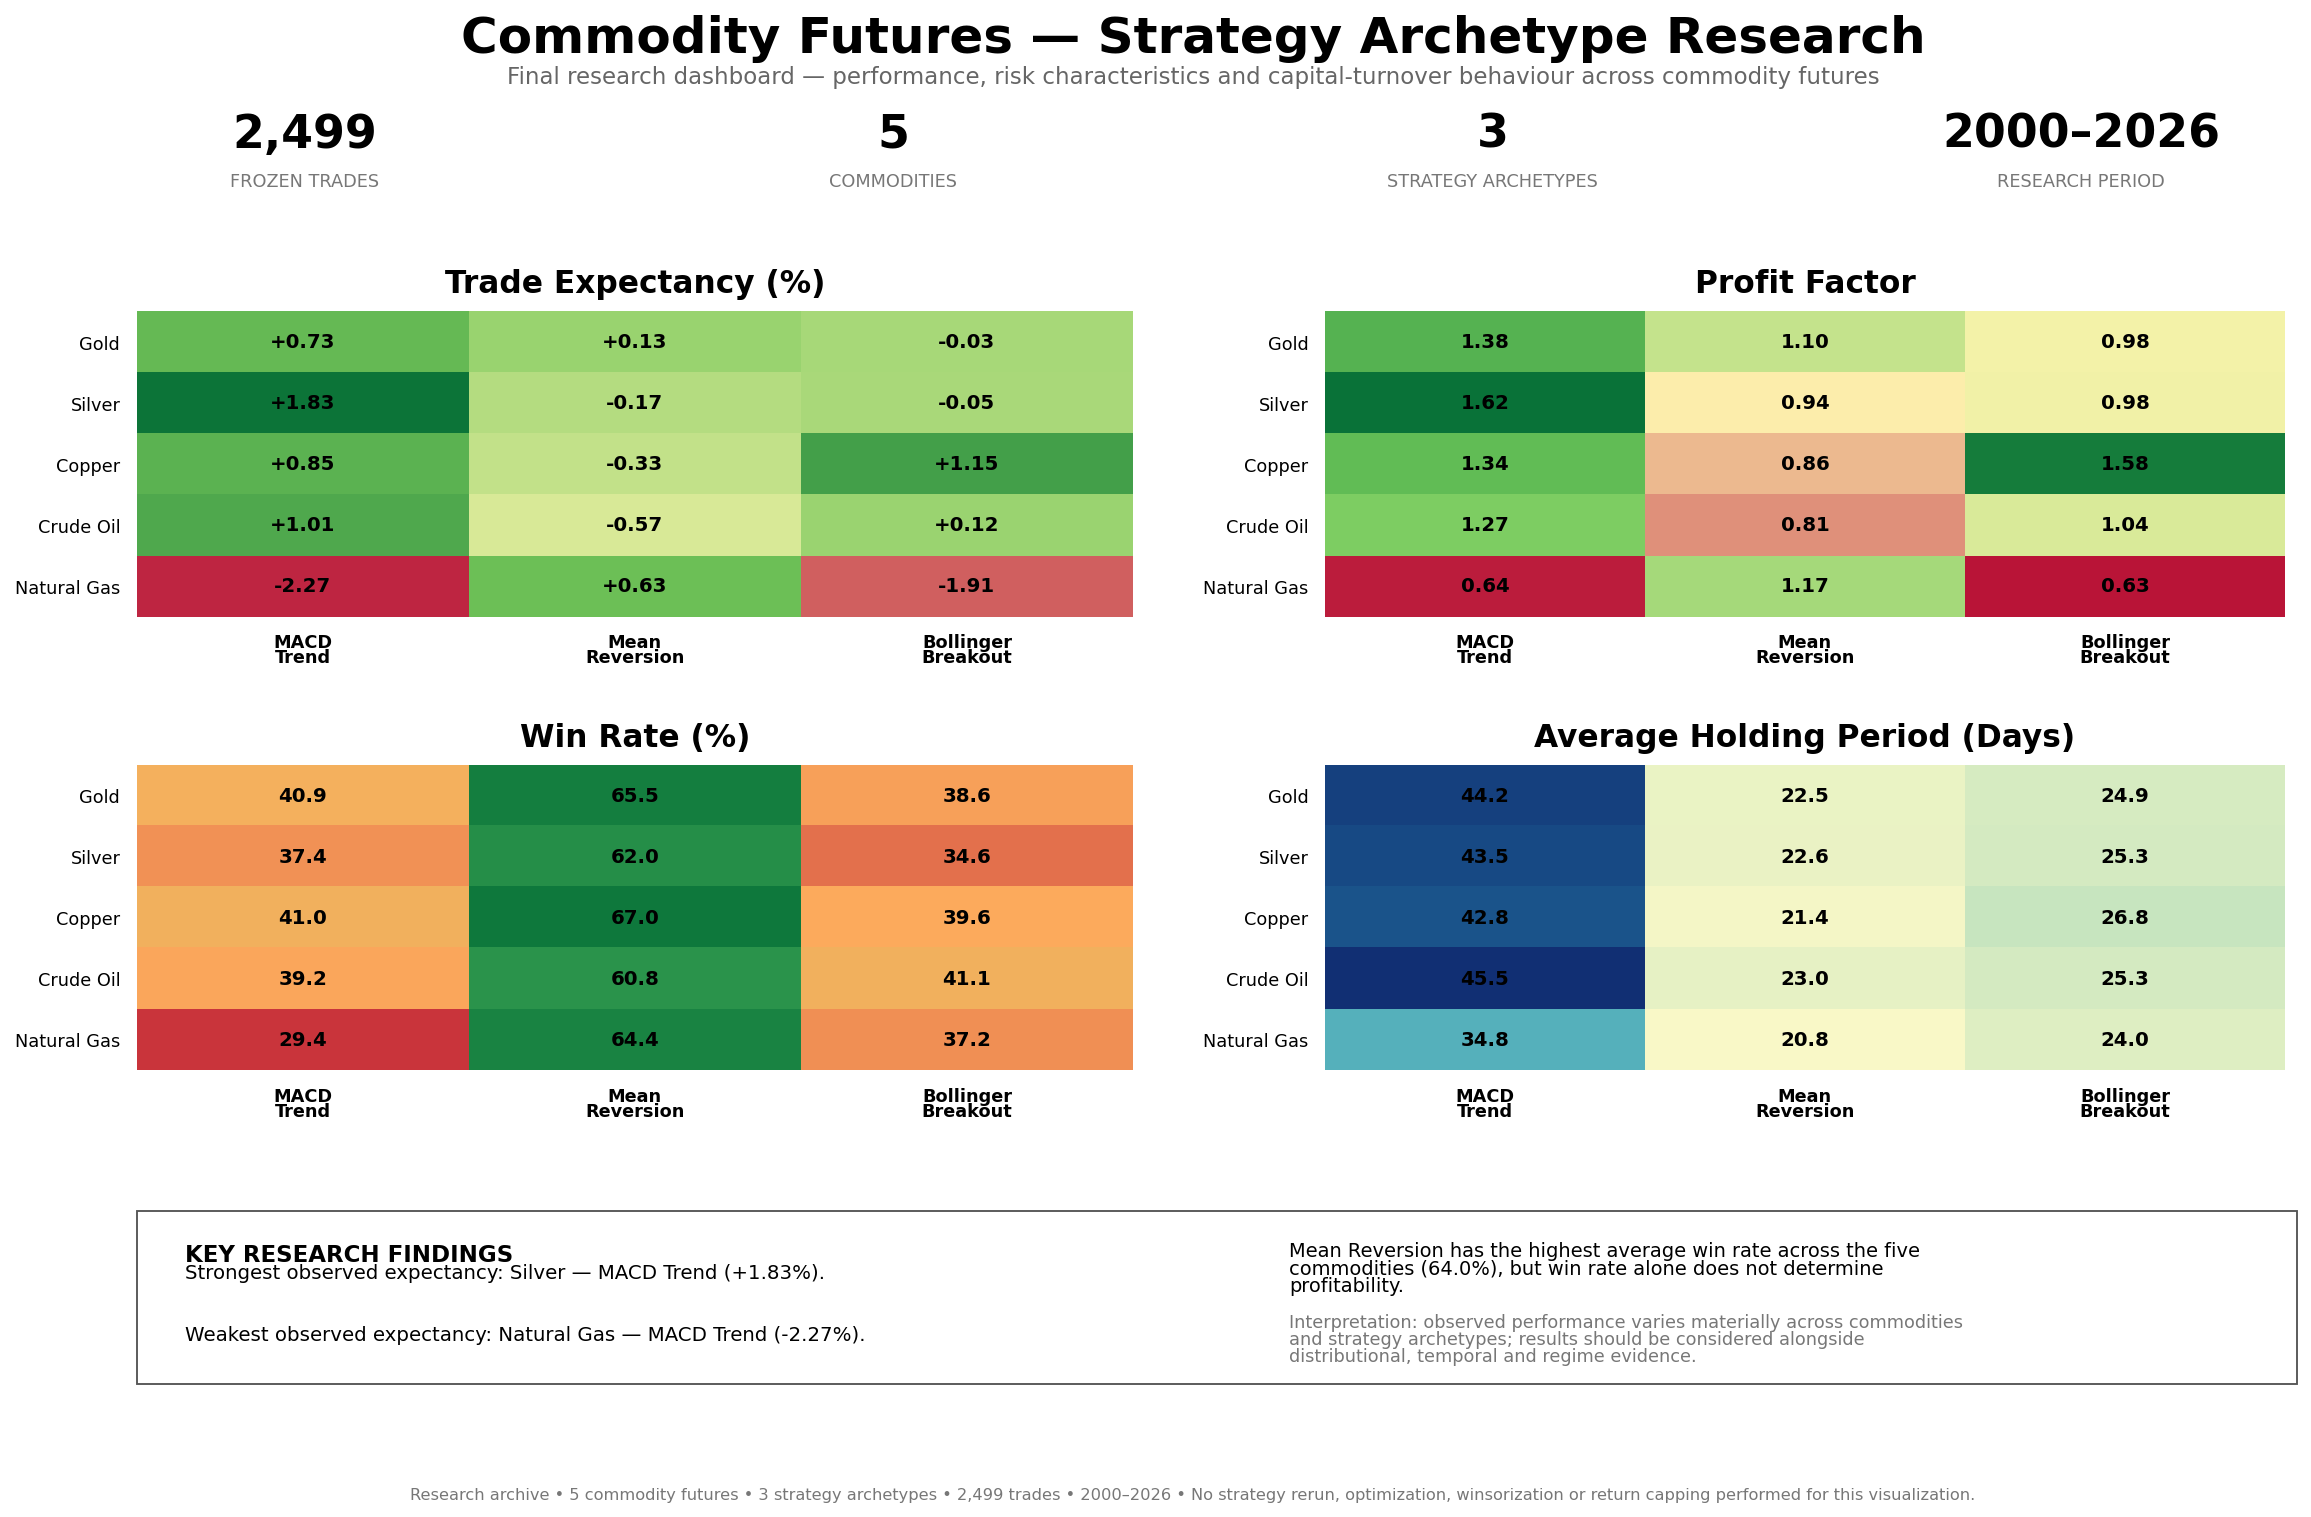



V22 FINAL RESEARCH DASHBOARD — VALIDATION
✓ Frozen trade count        : 2,499
✓ Commodity universe        : 5
✓ Strategy archetypes       : 3
✓ Research period           : 2000–2026

Heatmap datasets:
✓ Expectancy matrix         : (5, 3)
✓ Profit factor matrix      : (5, 3)
✓ Win rate matrix           : (5, 3)
✓ Holding period matrix     : (5, 3)

✓ Strongest expectancy      : Silver — MACD Trend (+1.83%)
✓ Weakest expectancy        : Natural Gas — MACD Trend (-2.27%)

✓ Mean Reversion avg win rate: 64.0%
✓ Output file               : C:\Users\navon\commodity_strategy_research\visualizations\figures\V21_final_research_dashboard.png


🟢 V22 FINAL RESEARCH DASHBOARD: BLACK NUMBERS + COMMODITY FUTURES

Research data was not modified.
No strategy was rerun.
No optimization was performed.
No returns were winsorized or capped.
Final dashboard exported at 300 DPI.


In [20]:
# =====================================================================
# V22 FINAL RESEARCH DASHBOARD — BLACK NUMBERS + COMMODITY FUTURES TITLE
# =====================================================================
# FINAL PRESENTATION FIX:
#   • All heatmap numerical annotations are black
#   • Removed "International" from the dashboard title
#   • Removed "international" from the footer
#   • Kept all table values and research conclusions unchanged
#   • Findings box remains inside the frame
#   • No research data modified
#   • No strategy rerun
#   • No optimization performed
#   • No returns winsorized or capped
# =====================================================================


from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import warnings


warnings.filterwarnings("ignore")


print("=" * 75)
print("V22 FINAL RESEARCH DASHBOARD — BLACK NUMBERS + COMMODITY FUTURES")
print("=" * 75)


# =====================================================================
# 1. RESOLVE RESEARCH ARCHIVE
# =====================================================================

CANDIDATE_ROOTS = [
    Path(r"C:\Users\navon\commodity_strategy_research"),
    Path.cwd() / "commodity_strategy_research",
    Path.cwd().parent / "commodity_strategy_research",
]


ROOT = None


for candidate in CANDIDATE_ROOTS:

    if candidate.exists() and candidate.is_dir():

        ROOT = candidate
        break


if ROOT is None:

    raise FileNotFoundError(
        "Could not locate the commodity_strategy_research archive.\n"
        "Expected path:\n"
        r"C:\Users\navon\commodity_strategy_research"
    )


print(f"✓ Research archive resolved: {ROOT}")


# =====================================================================
# 2. LOAD FROZEN DATASETS
# =====================================================================

def load_csv(relative_path):

    path = ROOT / relative_path


    if not path.exists():

        raise FileNotFoundError(
            f"Required dataset not found:\n{path}"
        )


    df = pd.read_csv(path)


    print(
        f"✓ Loaded: {relative_path} "
        f"({df.shape[0]:,} rows × {df.shape[1]:,} columns)"
    )


    return df


expectancy_raw = load_csv(
    Path("statistics") / "expectancy_matrix.csv"
)


profit_factor_raw = load_csv(
    Path("statistics") / "profit_factor_matrix.csv"
)


win_rate_raw = load_csv(
    Path("statistics") / "win_rate_matrix.csv"
)


holding_period_raw = load_csv(
    Path("statistics") / "holding_period_matrix.csv"
)


overall_strategy = load_csv(
    Path("statistics") / "overall_strategy_comparison.csv"
)


master_trades = load_csv(
    Path("trades") / "all_strategy_trades.csv"
)


# =====================================================================
# 3. EXPECTED STRUCTURE
# =====================================================================

EXPECTED_COMMODITIES = [
    "Gold",
    "Silver",
    "Copper",
    "Crude Oil",
    "Natural Gas",
]


EXPECTED_STRATEGIES = [
    "MACD Trend",
    "Mean Reversion",
    "Bollinger Breakout",
]


# =====================================================================
# 4. ROBUST LABEL NORMALIZATION
# =====================================================================

def normalize_label(value):

    if pd.isna(value):

        return ""


    text = str(value).strip()


    aliases = {

        "GOLD": "Gold",

        "SILVER": "Silver",

        "COPPER": "Copper",

        "CRUDE": "Crude Oil",

        "CRUDE_OIL": "Crude Oil",

        "CRUDE OIL": "Crude Oil",

        "NATURAL_GAS": "Natural Gas",

        "NATURAL GAS": "Natural Gas",

        "NG": "Natural Gas",


        "MACD": "MACD Trend",

        "MACD TREND": "MACD Trend",

        "MACD TREND FOLLOWING": "MACD Trend",

        "MACD Trend Following": "MACD Trend",


        "MEAN REVERSION": "Mean Reversion",


        "BOLLINGER": "Bollinger Breakout",

        "BOLLINGER BREAKOUT": "Bollinger Breakout",

    }


    return aliases.get(text.upper(), text)


# =====================================================================
# 5. MATRIX PREPARATION
# =====================================================================

def prepare_matrix(df, matrix_name):

    temp = df.copy()


    temp = temp.dropna(
        axis=1,
        how="all"
    )


    # -------------------------------------------------------------
    # Identify index / commodity column
    # -------------------------------------------------------------

    index_col = None


    unnamed_columns = [
        c
        for c in temp.columns
        if str(c).lower().startswith("unnamed")
    ]


    if unnamed_columns:

        index_col = unnamed_columns[0]


    else:

        first_col = temp.columns[0]


        first_values = [
            normalize_label(v)
            for v in temp[first_col].dropna().head(10)
        ]


        if any(
            v in EXPECTED_COMMODITIES
            for v in first_values
        ):

            index_col = first_col


    if index_col is None:

        index_col = temp.columns[0]


    temp = temp.set_index(index_col)


    # -------------------------------------------------------------
    # Normalize commodity labels
    # -------------------------------------------------------------

    temp.index = [
        normalize_label(v)
        for v in temp.index
    ]


    # -------------------------------------------------------------
    # Normalize strategy labels
    # -------------------------------------------------------------

    temp.columns = [
        normalize_label(c)
        for c in temp.columns
    ]


    # -------------------------------------------------------------
    # Explicit strategy aliases
    # -------------------------------------------------------------

    column_aliases = {

        "MACD Trend Following": "MACD Trend",

        "MACD": "MACD Trend",

        "Mean Reversion": "Mean Reversion",

        "Bollinger": "Bollinger Breakout",

        "Bollinger Breakout": "Bollinger Breakout",

    }


    temp = temp.rename(
        columns={
            col: column_aliases.get(col, col)
            for col in temp.columns
        }
    )


    # -------------------------------------------------------------
    # Validate rows
    # -------------------------------------------------------------

    missing_rows = [

        c
        for c in EXPECTED_COMMODITIES
        if c not in temp.index

    ]


    if missing_rows:

        raise ValueError(

            f"{matrix_name}: missing commodities:\n"
            f"{missing_rows}\n\n"
            f"Available rows:\n"
            f"{list(temp.index)}"

        )


    # -------------------------------------------------------------
    # Validate columns
    # -------------------------------------------------------------

    missing_columns = [

        s
        for s in EXPECTED_STRATEGIES
        if s not in temp.columns

    ]


    if missing_columns:

        raise ValueError(

            f"{matrix_name}: missing strategies:\n"
            f"{missing_columns}\n\n"
            f"Available columns:\n"
            f"{list(temp.columns)}"

        )


    # -------------------------------------------------------------
    # Final canonical ordering
    # -------------------------------------------------------------

    temp = temp.loc[
        EXPECTED_COMMODITIES,
        EXPECTED_STRATEGIES
    ]


    # -------------------------------------------------------------
    # Numeric conversion
    # -------------------------------------------------------------

    for col in EXPECTED_STRATEGIES:

        temp[col] = pd.to_numeric(
            temp[col],
            errors="coerce"
        )


    if temp.isna().any().any():

        raise ValueError(
            f"{matrix_name}: numeric conversion generated NaN values."
        )


    return temp


expectancy = prepare_matrix(
    expectancy_raw,
    "Expectancy matrix"
)


profit_factor = prepare_matrix(
    profit_factor_raw,
    "Profit factor matrix"
)


win_rate = prepare_matrix(
    win_rate_raw,
    "Win rate matrix"
)


holding_period = prepare_matrix(
    holding_period_raw,
    "Holding period matrix"
)


# =====================================================================
# 6. FROZEN DATA VALIDATION
# =====================================================================

assert len(master_trades) == 2499


assert list(expectancy.index) == EXPECTED_COMMODITIES
assert list(profit_factor.index) == EXPECTED_COMMODITIES
assert list(win_rate.index) == EXPECTED_COMMODITIES
assert list(holding_period.index) == EXPECTED_COMMODITIES


assert list(expectancy.columns) == EXPECTED_STRATEGIES
assert list(profit_factor.columns) == EXPECTED_STRATEGIES
assert list(win_rate.columns) == EXPECTED_STRATEGIES
assert list(holding_period.columns) == EXPECTED_STRATEGIES


# =====================================================================
# 7. DISPLAY LABELS
# =====================================================================

DISPLAY_COMMODITIES = [
    "Gold",
    "Silver",
    "Copper",
    "Crude Oil",
    "Natural Gas",
]


DISPLAY_STRATEGIES = [
    "MACD\nTrend",
    "Mean\nReversion",
    "Bollinger\nBreakout",
]


# =====================================================================
# 8. STRONGEST / WEAKEST EXPECTANCY
# =====================================================================

max_cell = expectancy.stack().idxmax()

min_cell = expectancy.stack().idxmin()


strongest_commodity, strongest_strategy = max_cell

weakest_commodity, weakest_strategy = min_cell


strongest_value = expectancy.loc[
    strongest_commodity,
    strongest_strategy
]


weakest_value = expectancy.loc[
    weakest_commodity,
    weakest_strategy
]


# =====================================================================
# 9. MEAN REVERSION AVERAGE WIN RATE
# =====================================================================

overall_mr_win_rate = float(
    win_rate["Mean Reversion"].mean()
)


# Try to use the actual overall summary value if available.

possible_win_columns = [

    c
    for c in overall_strategy.columns
    if "win" in str(c).lower()
    and "rate" in str(c).lower()

]


if possible_win_columns:

    win_col = possible_win_columns[0]


    strategy_name_col = None


    for col in overall_strategy.columns:

        values = (
            overall_strategy[col]
            .astype(str)
            .str.lower()
        )


        if values.str.contains(
            "mean reversion"
        ).any():

            strategy_name_col = col

            break


    if strategy_name_col is not None:

        mask = (
            overall_strategy[strategy_name_col]
            .astype(str)
            .str.lower()
            .str.contains("mean reversion")
        )


        if mask.any():

            candidate = pd.to_numeric(

                overall_strategy.loc[
                    mask,
                    win_col
                ].iloc[0],

                errors="coerce"

            )


            if pd.notna(candidate):

                overall_mr_win_rate = float(candidate)


# =====================================================================
# 10. EXPORT LOCATION
# =====================================================================

FIGURE_ROOT = (
    ROOT /
    "visualizations" /
    "figures"
)


FIGURE_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


OUTPUT_FILE = (
    FIGURE_ROOT /
    "V21_final_research_dashboard.png"
)


# =====================================================================
# 11. MATPLOTLIB SETTINGS
# =====================================================================

plt.rcParams.update({

    "font.family": "DejaVu Sans",

    "font.size": 10,

    "axes.titlesize": 15,

    "axes.titleweight": "bold",

    "axes.labelsize": 10,

    "xtick.labelsize": 9,

    "ytick.labelsize": 8.5,

    "figure.dpi": 150,

    "savefig.dpi": 300,

    "axes.linewidth": 0.8,

})


# =====================================================================
# 12. COLOUR MAPS
# =====================================================================

expectancy_cmap = LinearSegmentedColormap.from_list(

    "expectancy_map",

    [

        "#b3002d",

        "#fff6b0",

        "#78c85a",

        "#006b35",

    ]

)


pf_cmap = LinearSegmentedColormap.from_list(

    "pf_map",

    [

        "#b3002d",

        "#fff6b0",

        "#70c95a",

        "#006b35",

    ]

)


win_cmap = LinearSegmentedColormap.from_list(

    "win_map",

    [

        "#b3002d",

        "#ffb15e",

        "#46ae59",

        "#006b35",

    ]

)


hold_cmap = LinearSegmentedColormap.from_list(

    "hold_map",

    [

        "#fffbc8",

        "#b8dfbd",

        "#2c9dbb",

        "#10296f",

    ]

)


# =====================================================================
# 13. HEATMAP FUNCTION
# =====================================================================

def draw_heatmap(

    ax,
    df,
    title,
    cmap,
    value_type,
    vmin,
    vmax

):


    values = df.to_numpy(
        dtype=float
    )


    ax.imshow(

        values,

        aspect="auto",

        cmap=cmap,

        vmin=vmin,

        vmax=vmax,

        interpolation="nearest"

    )


    # -------------------------------------------------------------
    # X labels
    # -------------------------------------------------------------

    ax.set_xticks(

        np.arange(
            len(DISPLAY_STRATEGIES)
        )

    )


    ax.set_xticklabels(

        DISPLAY_STRATEGIES,

        fontsize=8.5,

        fontweight="bold",

        linespacing=0.82

    )


    # -------------------------------------------------------------
    # Y labels
    # -------------------------------------------------------------

    ax.set_yticks(

        np.arange(
            len(DISPLAY_COMMODITIES)
        )

    )


    ax.set_yticklabels(

        DISPLAY_COMMODITIES,

        fontsize=8.5

    )


    # IMPORTANT:
    # Slightly increased padding keeps the commodity labels away from
    # the centre gap and prevents horizontal cross-panel overlap.

    ax.tick_params(

        axis="y",

        length=0,

        pad=8

    )


    ax.tick_params(

        axis="x",

        length=0,

        pad=8

    )


    # -------------------------------------------------------------
    # Title
    # -------------------------------------------------------------

    ax.set_title(

        title,

        fontsize=15,

        fontweight="bold",

        pad=9

    )


    # -------------------------------------------------------------
    # Cell annotations
    # -------------------------------------------------------------

    for i in range(values.shape[0]):

        for j in range(values.shape[1]):

            value = values[i, j]


            if value_type == "expectancy":

                text = f"{value:+.2f}"


            elif value_type == "profit_factor":

                text = f"{value:.2f}"


            elif value_type == "win_rate":

                text = f"{value:.1f}"


            elif value_type == "holding":

                text = f"{value:.1f}"


            else:

                text = f"{value:.2f}"


            # -----------------------------------------------------
            # FINAL PRESENTATION FIX:
            # Every heatmap number is black.
            # -----------------------------------------------------

            text_color = "black"


            ax.text(

                j,

                i,

                text,

                ha="center",

                va="center",

                fontsize=9.5,

                fontweight="bold",

                color=text_color

            )


    # -------------------------------------------------------------
    # Remove spines
    # -------------------------------------------------------------

    for spine in ax.spines.values():

        spine.set_visible(False)


# =====================================================================
# 14. CREATE FIGURE
# =====================================================================

fig = plt.figure(

    figsize=(16, 11),

    facecolor="white"

)


# =====================================================================
# 15. MAIN TITLE
# =====================================================================

fig.text(

    0.5,

    0.975,

    "Commodity Futures — Strategy Archetype Research",

    ha="center",

    va="top",

    fontsize=24,

    fontweight="bold"

)


fig.text(

    0.5,

    0.944,

    "Final research dashboard — performance, risk characteristics and "

    "capital-turnover behaviour across commodity futures",

    ha="center",

    va="top",

    fontsize=11,

    color="#666666"

)


# =====================================================================
# 16. KPI STRIP
# =====================================================================

KPI_X = [

    0.13,

    0.375,

    0.625,

    0.87

]


KPI_VALUES = [

    "2,499",

    "5",

    "3",

    "2000–2026"

]


KPI_LABELS = [

    "FROZEN TRADES",

    "COMMODITIES",

    "STRATEGY ARCHETYPES",

    "RESEARCH PERIOD"

]


for x, value, label in zip(

    KPI_X,

    KPI_VALUES,

    KPI_LABELS

):


    fig.text(

        x,

        0.902,

        value,

        ha="center",

        va="center",

        fontsize=22,

        fontweight="bold"

    )


    fig.text(

        x,

        0.874,

        label,

        ha="center",

        va="center",

        fontsize=8.5,

        color="#777777"

    )


# =====================================================================
# 17. FINAL PANEL GEOMETRY
# =====================================================================

#
# MAIN HORIZONTAL FIX:
#
# Previous:
#   LEFT  = 0.060
#   WIDTH = 0.435
#   RIGHT = 0.530
#   WIDTH = 0.435
#
# The centre gap was too narrow for the long "Crude Oil" /
# "Natural Gas" y-axis labels.
#
# New:
#
#   LEFT PANEL:
#       x = 0.060
#       width = 0.415
#
#   RIGHT PANEL:
#       x = 0.555
#       width = 0.400
#
# This creates a substantially wider central gutter.
#
# The visual hierarchy and vertical positioning are unchanged.


LEFT_X = 0.060

LEFT_WIDTH = 0.415


RIGHT_X = 0.555

RIGHT_WIDTH = 0.400


TOP_Y = 0.610

BOTTOM_Y = 0.335


HEAT_H = 0.185


# =====================================================================
# 18. CREATE AXES
# =====================================================================

ax_exp = fig.add_axes([

    LEFT_X,

    TOP_Y,

    LEFT_WIDTH,

    HEAT_H

])


ax_pf = fig.add_axes([

    RIGHT_X,

    TOP_Y,

    RIGHT_WIDTH,

    HEAT_H

])


ax_wr = fig.add_axes([

    LEFT_X,

    BOTTOM_Y,

    LEFT_WIDTH,

    HEAT_H

])


ax_hold = fig.add_axes([

    RIGHT_X,

    BOTTOM_Y,

    RIGHT_WIDTH,

    HEAT_H

])


# =====================================================================
# 19. DRAW FOUR HEATMAPS
# =====================================================================

draw_heatmap(

    ax_exp,

    expectancy,

    "Trade Expectancy (%)",

    expectancy_cmap,

    "expectancy",

    vmin=-2.5,

    vmax=2.0

)


draw_heatmap(

    ax_pf,

    profit_factor,

    "Profit Factor",

    pf_cmap,

    "profit_factor",

    vmin=0.60,

    vmax=1.65

)


draw_heatmap(

    ax_wr,

    win_rate,

    "Win Rate (%)",

    win_cmap,

    "win_rate",

    vmin=25,

    vmax=70

)


draw_heatmap(

    ax_hold,

    holding_period,

    "Average Holding Period (Days)",

    hold_cmap,

    "holding",

    vmin=20,

    vmax=46

)


# =====================================================================
# 20. KEY RESEARCH FINDINGS BOX
# =====================================================================

BOX_X = 0.060

BOX_Y = 0.145

BOX_W = 0.900

BOX_H = 0.105


box = Rectangle(

    (BOX_X, BOX_Y),

    BOX_W,

    BOX_H,

    transform=fig.transFigure,

    fill=False,

    linewidth=0.9,

    edgecolor="#555555"

)


fig.add_artist(box)


# ---------------------------------------------------------------------
# Findings heading
# ---------------------------------------------------------------------

fig.text(

    BOX_X + 0.020,

    BOX_Y + BOX_H - 0.020,

    "KEY RESEARCH FINDINGS",

    ha="left",

    va="top",

    fontsize=11,

    fontweight="bold"

)


# ---------------------------------------------------------------------
# Left findings
# ---------------------------------------------------------------------

fig.text(

    BOX_X + 0.020,

    BOX_Y + 0.067,

    f"Strongest observed expectancy: "

    f"{strongest_commodity} — {strongest_strategy} "

    f"({strongest_value:+.2f}%).",

    ha="left",

    va="center",

    fontsize=9.5

)


fig.text(

    BOX_X + 0.020,

    BOX_Y + 0.030,

    f"Weakest observed expectancy: "

    f"{weakest_commodity} — {weakest_strategy} "

    f"({weakest_value:+.2f}%).",

    ha="left",

    va="center",

    fontsize=9.5

)


# ---------------------------------------------------------------------
# Right findings
# ---------------------------------------------------------------------

# Explicit line breaks ensure that the text remains inside the box.


RIGHT_TEXT_X = BOX_X + 0.480


fig.text(

    RIGHT_TEXT_X,

    BOX_Y + 0.070,

    "Mean Reversion has the highest average win rate across the five\n"

    f"commodities ({overall_mr_win_rate:.1f}%), but win rate alone does not determine\n"

    "profitability.",

    ha="left",

    va="center",

    fontsize=9.3,

    linespacing=0.92

)


fig.text(

    RIGHT_TEXT_X,

    BOX_Y + 0.027,

    "Interpretation: observed performance varies materially across commodities\n"

    "and strategy archetypes; results should be considered alongside\n"

    "distributional, temporal and regime evidence.",

    ha="left",

    va="center",

    fontsize=8.5,

    color="#777777",

    linespacing=0.92

)


# =====================================================================
# 21. FOOTER
# =====================================================================

fig.text(

    0.5,

    0.078,

    "Research archive • 5 commodity futures • "

    "3 strategy archetypes • 2,499 trades • 2000–2026 • "

    "No strategy rerun, optimization, winsorization or return capping "

    "performed for this visualization.",

    ha="center",

    va="center",

    fontsize=7.8,

    color="#777777"

)


# =====================================================================
# 22. EXPORT
# =====================================================================

fig.savefig(

    OUTPUT_FILE,

    dpi=300,

    facecolor="white",

    edgecolor="none"

)


plt.show()


# =====================================================================
# 23. FINAL VALIDATION
# =====================================================================

print("\n")

print("=" * 75)

print("V22 FINAL RESEARCH DASHBOARD — VALIDATION")

print("=" * 75)


print(

    f"✓ Frozen trade count        : "

    f"{len(master_trades):,}"

)


print(

    f"✓ Commodity universe        : "

    f"{len(EXPECTED_COMMODITIES)}"

)


print(

    f"✓ Strategy archetypes       : "

    f"{len(EXPECTED_STRATEGIES)}"

)


print(

    "✓ Research period           : 2000–2026"

)


print("\nHeatmap datasets:")


print(

    f"✓ Expectancy matrix         : "

    f"{expectancy.shape}"

)


print(

    f"✓ Profit factor matrix      : "

    f"{profit_factor.shape}"

)


print(

    f"✓ Win rate matrix           : "

    f"{win_rate.shape}"

)


print(

    f"✓ Holding period matrix     : "

    f"{holding_period.shape}"

)


print(

    f"\n✓ Strongest expectancy      : "

    f"{strongest_commodity} — {strongest_strategy} "

    f"({strongest_value:+.2f}%)"

)


print(

    f"✓ Weakest expectancy        : "

    f"{weakest_commodity} — {weakest_strategy} "

    f"({weakest_value:+.2f}%)"

)


print(

    f"\n✓ Mean Reversion avg win rate: "

    f"{overall_mr_win_rate:.1f}%"

)


print(

    f"✓ Output file               : "

    f"{OUTPUT_FILE}"

)


print("\n")

print(
    "🟢 V22 FINAL RESEARCH DASHBOARD: "
    "BLACK NUMBERS + COMMODITY FUTURES"
)

print("\nResearch data was not modified.")

print("No strategy was rerun.")

print("No optimization was performed.")

print("No returns were winsorized or capped.")

print("Final dashboard exported at 300 DPI.")

print("=" * 75)